# The GLM, Part 1: Estimation

In this lab we introduce how most univariate fMRI analyses are carried out using the **General Linear Model (GLM)**. Our focus today is on **estimation** — how we obtain parameter weights (β) that link a design matrix to voxel time series.

> **Key idea**  
> We try to explain <span style="color:royalblue">brain signals (y)</span>  using <span style="color:orange">predictors from the task/paradigm (X)</span>,  which are weighted by <span style="color:darkred">parameters (β)</span>, plus some <span style="color:grey">errors (ε)</span>.: 
> $$\textcolor{blue}{y} = \textcolor{orange}{X}\textcolor{darkred}{\beta} + \textcolor{gray}{\varepsilon}$$  
> - **y**: brain signals  
> - **X**: predictors from the task/paradigm  
> - **β**: parameters (weights)  
> - **ε**: residual errors

You have likely met the GLM before: *t*-tests, *F*-tests, (M)ANOVA, and ordinary **linear regression** are all special cases of the same framework (see this optional overview: [“Common statistical tests are linear models”](https://lindeloev.github.io/tests-as-linear/)). In fMRI, the “univariate” approach (often called Statistical Parametric Mapping) is simply linear regression applied **voxel by voxel** to time series data.

We assume basic familiarity with regression (which we briefly recap in Section 1). The maths here is used to **clarify concepts**, not to burden you: every equation is followed by a small, concrete example and runnable code so you can see what each term does in practice.

**What you’ll learn**
- Estimate and interpret GLM parameters (β) and assess model fit (predicted signal vs residuals).
- Understand why and how the BOLD haemodynamic response is modelled within the GLM.
- Implement a simple univariate GLM for fMRI data in Python and inspect β/contrast maps.

**Estimated time to complete:** 6–10 hours

**Credits:**  
- Originally developed by H. Steven Scholte & Lukas Snoek (2019)  
- Updated by Joe Bathelt (2025)  

## Recap of Linear Regression

Before diving into the GLM, let’s briefly refresh the core ideas of **linear regression** with a simple example.

In this lab, we will use the following conventions:

- **<span style="color:blue">y</span>**: the dependent variable (what we want to explain).  
- **<span style="color:orange">X</span>**: the independent variable(s) (predictors or regressors).  

When we have multiple predictors, we group them into a **design matrix** `X`.  
- Rows = observations (sometimes called samples or data points).  
- Columns = predictors (variables we use to explain y).  

So, by convention, the design matrix has the shape:  
$$
N \times P \quad \text{where } 
\; \textcolor{blue}{y} \in \mathbb{R}^{N \times 1}, \quad
\textcolor{orange}{X} \in \mathbb{R}^{N \times P}
$$

---

### Notation

- **N** = total number of observations (rows).  
- **i** = index of an observation.  
- **P** = total number of predictors (columns).  
- **j** = index of a predictor.  

Examples:

- Summing over all observations of y:  
  $$
  \sum_{i=1}^{N} \textcolor{blue}{y_i}
  $$

- Summing over all predictors for a given observation i:  
  $$
  \sum_{j=1}^{P} \textcolor{orange}{X_{ij}}
  $$

---

👉 **Check your understanding: Practice with notation**

1. Write down the formula for the **mean of y** across all observations.  
2. Write down the formula for the **mean of the predictors** (the columns of X) across observations.  

---

<details>
<summary>✅ Click to reveal solutions</summary>

1. Mean of **y**:  
   $$
   \bar{y} = \frac{1}{N}\sum_{i=1}^{N} y_i
   $$

2. Mean of predictors (for predictor j):  
   $$
   \bar{X}_{j} = \frac{1}{N}\sum_{i=1}^{N} X_{ij}
   $$

</details>

Now, we will implement a linear regression model with Python.

In [3]:
# First some imports
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [4]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/qblzq92vqqtls3jwg5g8y/data_todo_rsquared.npz?rlkey=ovub8akpakadsgl6beqbp1ym8&dl=1",
    "data_todo_rsquared.npz"
)

download_file(
    "https://www.dropbox.com/scl/fi/euhf1knahdgweee55tgq8/example_voxel_signal.npy?rlkey=gus2nuki9mgd3mqfepdjeksyj&dl=1",
    "example_voxel_signal.npy"
)

download_file(
    "https://www.dropbox.com/scl/fi/h872u21ht38gjppzofdl6/ToDo.npz?rlkey=tu992ndekb2c7o0eweje1uwdt&dl=1",
    "ToDo.npz"
)

data_todo_rsquared.npz already exists, skipping download.
example_voxel_signal.npy already exists, skipping download.
ToDo.npz already exists, skipping download.


<div class='alert alert-warning'>

<b>ToDo</b> (1 point)  

You are given an array `arr` with shape $100 \times 25$, where:  
- Rows = **observations** ($N = 100$)  
- Columns = **predictors** ($P = 25$)  

👉 Calculate the **mean across all observations** for the predictor at index $j = 4$.  
- Store the result in a variable called `mean_predictor_4`.  
- ⚠️ Remember: Python uses **0-based indexing**, so `j = 4` refers to the **fifth predictor**.

</div>

In [72]:
import numpy as np
np.random.seed(42)
arr = np.random.normal(0, 1, size=(100, 25))
# YOUR CODE HERE
mean_predictor_4 = np.mean(arr[:,3])
mean_predictor_4

0.08591373616660723

In [73]:
# Feedback cell
if "mean_predictor_4" not in locals():
    print('The variable "mean_predictor_4" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(mean_predictor_4):
    print('"mean_predictor_4" should be a single numeric value.')
elif not np.isclose(mean_predictor_4, 0.086, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


Now let’s work through a concrete example of **linear regression**.  
We will introduce each component step by step.

We’ll create a small synthetic dataset with:  
- **N = 30 observations** (samples),  
- **P = 1 predictor** (independent variable, $\textcolor{orange}{X}$),  
- one **dependent variable** (the target we want to explain, $\textcolor{blue}{y}$).  

Both $\textcolor{orange}{X}$ and $\textcolor{blue}{y}$ will therefore have shape $30 \times 1$.

To make the example more realistic, we will generate the data so that  
$\textcolor{orange}{X}$ and $\textcolor{blue}{y}$ are correlated ($r = 0.8$).  
Of course, in real analyses you *don’t* know this correlation beforehand — but here it will help us see how regression captures the relationship.

In [7]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(1)

# Define covariance matrix with correlation = 0.8
prespecified_covariance = np.array([
    [1.0, 0.8],
    [0.8, 1.0]
])

# Generate 30 samples from a bivariate normal distribution
# Means: [3, 7], Covariance: prespecified_covariance
data = np.random.multivariate_normal(
    mean=[3, 7],
    cov=prespecified_covariance,
    size=30
)

"""
💡 Note on array shapes:
By default, slicing a single column from a NumPy array returns a 1D array 
with shape (N,), not a column vector with shape (N, 1). 

For our examples, we want explicit column vectors (N × 1). 
We can enforce this by adding an extra axis using `np.newaxis`.
"""

# Slice out the first and second columns, reshape to (N, 1)
X = data[:, 0, np.newaxis]   # predictor
y = data[:, 1, np.newaxis]   # dependent variable

# Display shapes
print(f"The shape of X is: {X.shape}")
print(f"The shape of y is: {y.shape}")

The shape of X is: (30, 1)
The shape of y is: (30, 1)


### Modelling the Intercept (Offset)

In regression models, we almost always include an **intercept**.  
The intercept captures part of the signal using a constant term.  

- Mathematically, the intercept parameter corresponds to the **average value of y when all predictors in X are 0**.  
- Conceptually, it ensures that the model accounts for the *baseline level* of the dependent variable, over and above the effects of the other predictors.  

How do we include an intercept in the design matrix?  
👉 By adding an extra **constant predictor**: a column of ones with shape $N \times 1$.  
This column tells the model: *“always include a constant offset when fitting the data.”*  

You’ll see later in the tutorial why this is so important. 

💡 **Tip:** From week 1, you already know how to make an array of ones in NumPy:  

```python
np.ones((N, 1))



In [8]:
n_obs = y.size
intercept = np.ones((n_obs, 1))  # creates intercept of shape (N, 1)

Now we want to **add the intercept column** to our design matrix (`X`).  

We can do this with NumPy’s `np.hstack` function (**h** stands for *horizontal*).  
- `np.hstack` takes a tuple of arrays that all have the **same number of rows**.  
- It returns a new array where these arrays are placed side by side (i.e. stacked as columns).  

In our case:  
- `X` has shape $30 \times 1$  
- the intercept column of ones also has shape $30 \times 1$  
- after stacking, the design matrix will have shape $30 \times 2$.

In [9]:
# Create a tuple with the intercept column and the original X
arrays_to_stack = (intercept, X)

# Stack them horizontally to form the new design matrix
X_with_intercept = np.hstack(arrays_to_stack)

# Alternative (more compact, but less readable):
# X_with_intercept = np.hstack((np.ones((y.shape[0], 1)), X))

print(f"Shape of design matrix with intercept: {X_with_intercept.shape}")

Shape of design matrix with intercept: (30, 2)


Let’s take a look at the design matrix (**X**) we’ve just created.  
It now has two columns:  
- the **first column** is the intercept (a constant predictor of ones),  
- the **second column** is our original predictor.

In [10]:
print(X_with_intercept)

[[1.         1.65246505]
 [1.         3.84037019]
 [1.         2.90681268]
 [1.         1.58544098]
 [1.         2.77619077]
 [1.         2.26439631]
 [1.         3.42732047]
 [1.         2.27222802]
 [1.         3.44118297]
 [1.         2.77565017]
 [1.         3.68214561]
 [1.         1.98577328]
 [1.         2.36158674]
 [1.         3.41250018]
 [1.         3.08642782]
 [1.         3.78163148]
 [1.         3.91918676]
 [1.         3.64080489]
 [1.         3.98584491]
 [1.         1.19071843]
 [1.         3.46268411]
 [1.         3.17361546]
 [1.         3.15323524]
 [1.         2.15472268]
 [1.         2.69083045]
 [1.         2.82662461]
 [1.         4.1943598 ]
 [1.         3.01266793]
 [1.         1.90963012]
 [1.         2.44916186]]


Now let’s take a look at the data itself.  
We’ll make a scatter plot of the predictor (**X**) against the dependent variable (**y**).  
(The intercept column is left out here, since it’s just a constant of ones.)

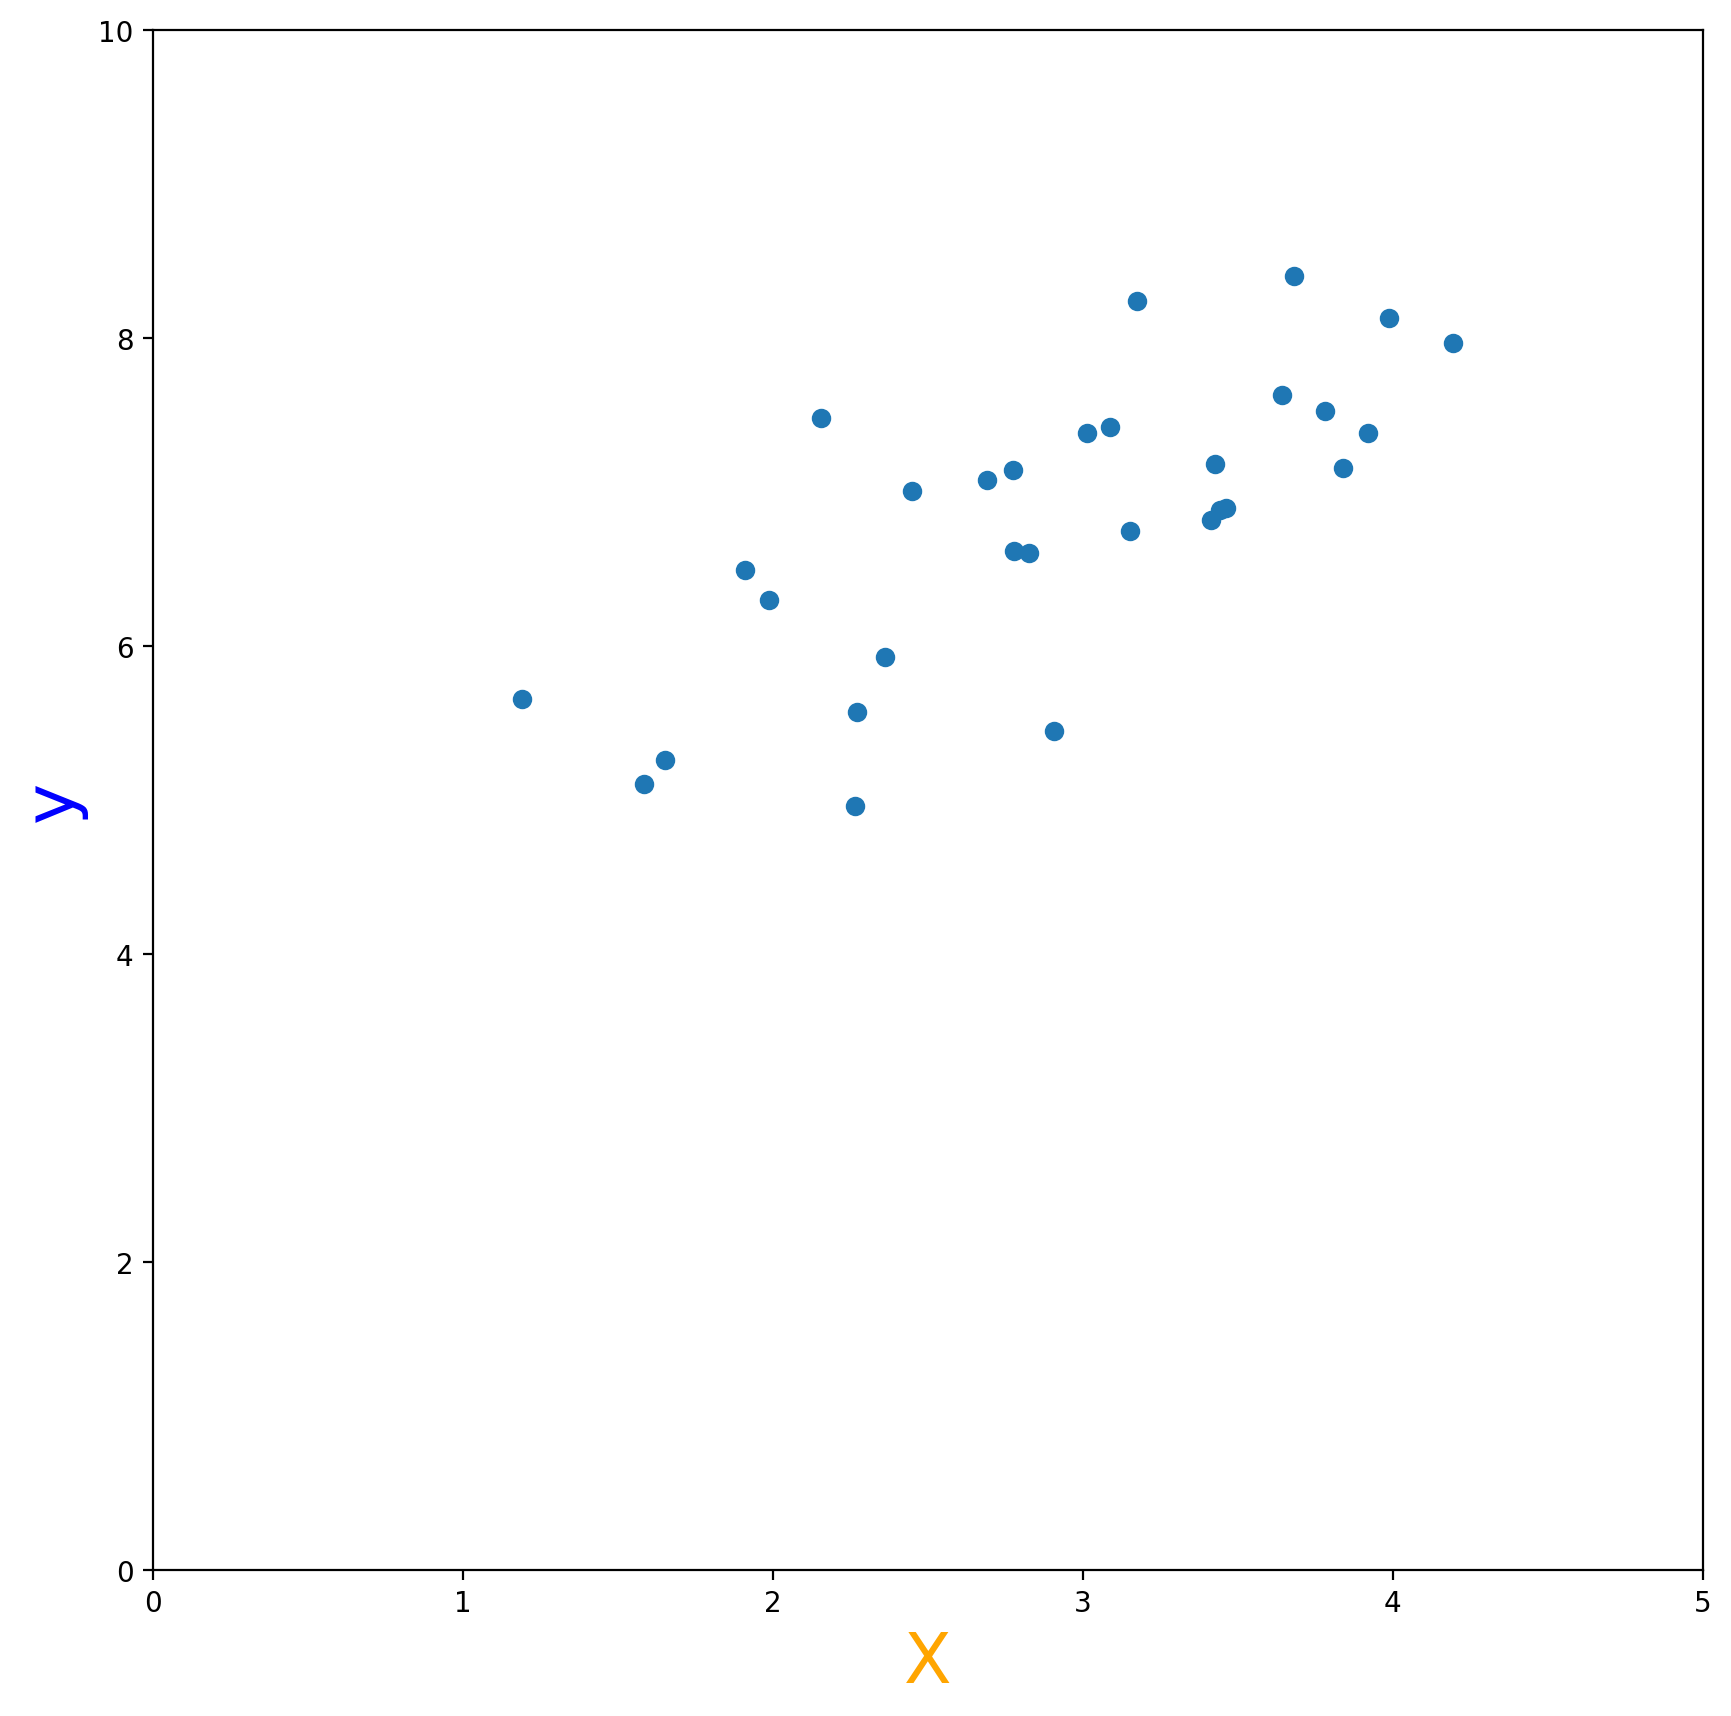

In [11]:
plt.figure(figsize=(10, 10))
plt.scatter(X_with_intercept[:, 1], y)
plt.xlabel('X', fontsize=25, color='orange')
plt.ylabel('y', fontsize=25, color='blue')
plt.xlim((0, 5))
plt.ylim((0, 10))
plt.show()

### Parameters in Linear Regression

From the scatter plot, we can see a clear **positive relationship** between  
$\textcolor{orange}{X}$ (the predictor, without intercept) and $\textcolor{blue}{y}$ (the dependent variable).  
In other words: when $\textcolor{orange}{X}$ increases, $\textcolor{blue}{y}$ also tends to increase.  

But *how much* does $\textcolor{blue}{y}$ change for a given increase in $\textcolor{orange}{X}$?  
That’s exactly what linear regression allows us to quantify.  

---

### The β parameters
The model calculates parameters (often called **β parameters**, sometimes denoted by other Greek letters such as θ).  
- Each $\textcolor{darkred}{\beta_j}$ tells us **how much $\textcolor{blue}{y}$ changes if $\textcolor{orange}{X_j}$ increases by 1**.  
- In short, $\textcolor{darkred}{\beta_j}$ quantifies the *influence* of predictor $\textcolor{orange}{X_j}$ on the outcome $\textcolor{blue}{y}$.

Formally:  
$$
\textcolor{darkred}{\beta_{j}} = \frac{\delta \textcolor{blue}{y}}{\delta \textcolor{orange}{X_{j}}}
$$

---

### Intercept
Each predictor in $\textcolor{orange}{X}$ (i.e. $\textcolor{orange}{X_j}$) has a corresponding parameter $\textcolor{darkred}{\beta_j}$.  
This includes the **intercept** (a column of ones), usually written as $\textcolor{darkred}{\beta_0}$.  

Because $\textcolor{orange}{X_0}$ is just ones, the product $\textcolor{orange}{X_0}\textcolor{darkred}{\beta_0}$ simplifies to $\textcolor{darkred}{\beta_0}$.  
This term represents the **baseline value of $\textcolor{blue}{y}$** when all other predictors are zero.

---

### Full model
Putting it all together, linear regression can be written as:

$$
\textcolor{blue}{y} = \textcolor{darkred}{\beta_{0}} 
+ \textcolor{orange}{X_{1}}\textcolor{darkred}{\beta_{1}} 
+ \textcolor{orange}{X_{2}}\textcolor{darkred}{\beta_{2}} 
+ \dots 
+ \textcolor{orange}{X_{P}}\textcolor{darkred}{\beta_{P}} 
+ \textcolor{gray}{\varepsilon}
$$

or equivalently:

$$
\textcolor{blue}{y} = \sum_{j=1}^{P}\textcolor{orange}{X_{j}}\textcolor{darkred}{\beta_{j}} + \textcolor{gray}{\varepsilon}
$$

Here, $\textcolor{gray}{\varepsilon}$ denotes the **error term**: the part of $\textcolor{blue}{y}$ not explained by the predictors.

### How are the β parameters estimated?

So far we’ve seen what the parameters mean — but **how does linear regression actually estimate them?**  

The most common method is **Ordinary Least Squares (OLS)**.  
OLS finds the set of parameters $\hat{\boldsymbol{\beta}}$ that make the model’s predictions as close as possible to the observed data.  

---

**Key Idea**:
- Multiply the predictors ($\textcolor{orange}{X}$) by their weights ($\hat{\textcolor{darkred}{\beta}}$).  
- This produces an estimate of $\textcolor{blue}{y}$, called $\hat{\textcolor{blue}{y}}$ (“y-hat”).  
- OLS chooses $\hat{\textcolor{darkred}{\beta}}$ so that the difference between predicted $\hat{\textcolor{blue}{y}}$ and the true $\textcolor{blue}{y}$ is **as small as possible**.  

Formally, for each observation *i*:  

$$
\hat{\textcolor{blue}{y}}_{i} = \sum_{j=1}^{P} \textcolor{orange}{X_{ij}} \, \hat{\textcolor{darkred}{\beta}_{j}}
$$

---

*(Later we’ll see that “as small as possible” means minimising the squared error, which is why the method is called **least squares**.)*

Before we dive into how the parameters are estimated, let’s first **practice calculating predictions** ($\hat{\textcolor{blue}{y}}$).

<div class='alert alert-warning'>

<b>ToDo</b> (1 point)  

We’ve defined a design matrix with two predictors (`this_X`) and a set of parameter estimates (`these_betas`).  
(For now, just assume these $\hat{\textcolor{darkred}{\beta}}$ values were already estimated.)  

👉 Using this data, calculate the **predicted values** $\hat{\textcolor{blue}{y}}$:  
$$
\hat{\textcolor{blue}{y}} = \textcolor{orange}{X} \, \hat{\textcolor{darkred}{\beta}}
$$

- Store the result in an array named `this_y_hat`.  
- Your array should have shape `(100,)`.

</div>

In [12]:
# Just generate some random normal data with mean 0, std 1, and shape 100x2 (NxP)
this_X = np.random.normal(0, 1, (100, 2))
these_betas = np.array([5, 3])

# YOUR CODE HERE
this_y_hat = this_X @ these_betas #marix multiplication operator
print(this_y_hat.shape)

(100,)


In [13]:
# Feedback cell
if "this_y_hat" not in locals():
    print('The variable "this_y_hat" is not defined. Check that you created and named the variable correctly.')
elif not this_y_hat.shape == (100,):
    print('"this_y_hat" should be an array with shape (100,).')
elif not np.isclose(np.sum(this_y_hat), 85.05, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


### Refresher: Matrix Multiplication

In the GLM (and in statistics more broadly), you’ll often encounter tools from **linear algebra**, such as matrix multiplication and matrix inversion.  

Back in Week 1, we saw how to perform matrix multiplication in Python/NumPy using either:  
- the `.dot()` method, or  
- the `@` operator (recommended).  

---

### Why it matters here
The operation from the previous ToDo — calculating predictions $\hat{\textcolor{blue}{y}}$ — can also be expressed as a **matrix multiplication**:

$$
\hat{\textcolor{blue}{y}} = \textcolor{orange}{X} \, \hat{\boldsymbol{\textcolor{darkred}{\beta}}}
$$

This is the compact way of writing what we did earlier element by element.

---

### Visual reminder
See the figure below for a simple illustration of matrix multiplication:

![dot_prod](https://xaktly.com/Images/Mathematics/MatrixAlgebra/MatrixDefinitions/MatrixDefFigure7.png)  

Note: the blue and green highlights here are just to show which row of X is multiplied with which element of β. 
They don’t correspond to the colour scheme we use elsewhere in this course.

---

### In GLM terms
If the **left matrix** represents our predictors $\textcolor{orange}{\mathbf{X}}$  
and the **right vector** represents our estimated parameters $\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$,  
then their product gives us the predictions $\hat{\textcolor{blue}{y}}$:  

$$
\hat{\textcolor{blue}{y}} =
\begin{bmatrix}
  \textcolor{orange}{X_{1,1}} & \textcolor{orange}{X_{1,2}} \\
  \textcolor{orange}{X_{2,1}} & \textcolor{orange}{X_{2,2}} \\
  \vdots & \vdots \\
  \textcolor{orange}{X_{N,1}} & \textcolor{orange}{X_{N,2}}
\end{bmatrix}
\begin{bmatrix}
  \hat{\textcolor{darkred}{\beta}_{1}} \\
  \hat{\textcolor{darkred}{\beta}_{2}}
\end{bmatrix}
$$

---

Now let’s check this directly in code.

In [14]:
this_y_hat_dot = this_X @ these_betas  # this_X.dot(these_betas) is also correct
print(this_y_hat_dot)

[ -0.01338524   1.6703706    2.21587559  10.21759739   6.73838803
  -8.73396662   3.42869211  -4.48842891   0.95290386   3.43650722
  -1.71391492   2.1629619    1.34852454  -2.22062007   3.99755808
   6.55005865  -3.79261597   2.34949198  -1.58847781  -1.00590812
   1.43788029   3.79819378  -4.96641193   0.84168045  -1.23324889
  -5.92010843   1.65225542  -2.18412034  -5.04079461   6.83379015
  -2.44856964  12.2700849   -5.58141723   9.15228886  -3.40630421
  -2.71636339  -4.49867819   2.09344214  -0.83014248   4.14900705
  -1.23808648   6.5956657    3.06043025   2.24424643   3.21012702
  -8.85509716  11.75506195   1.90635652  -1.03938628  -3.27900914
  -5.57655277   0.35407235   1.95194714   5.57227764   5.26441588
  -0.53012277  11.8957242   -0.46059776   5.79536197   2.4409444
  -5.42215061   6.39560171  -2.40432132   3.53601676   1.18398727
   6.910171    12.85646364  -1.58706604   4.27244301   7.18808465
   0.4676259    3.05310707 -11.94182401 -10.92527308   0.27265972
  -5.660524

### Notation: Summation vs. Matrix Algebra

The element-wise notation we wrote earlier  

$$
\hat{\textcolor{blue}{y}}_{i} = \sum_{j=1}^{P} \textcolor{orange}{X_{ij}} \, \hat{\textcolor{darkred}{\beta}_{j}}
$$  

is exactly the same as the more compact **matrix algebra notation**:  

$$
\hat{\textcolor{blue}{y}}_{i} = \mathbf{\textcolor{orange}{X}}_{i} \, \hat{\boldsymbol{\textcolor{darkred}{\beta}}}
$$  

Here, the **bold symbols** (e.g. $\mathbf{\textcolor{orange}{X}}$) denote matrices or vectors.  

---

#### Why this matters
You will calculate $\hat{\textcolor{blue}{y}}$ many times throughout this course.  
Using the **matrix multiplication form** is not only shorter but also **less error-prone**.  

So, use this approach:  

```python
y_hat = X @ betas
```

instead of writing everything out manually:

```python
y_hat = X[:, 0] * betas[0] + X[:, 1] * betas[1]
```

### Fitting OLS Models

So far, we’ve seen what the parameters mean, but not **how OLS actually estimates them**.  

The idea behind **Ordinary Least Squares (OLS)** is simple:  
find the set of parameters $\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$ that make the predictions  
$\hat{\textcolor{blue}{y}} = \textcolor{orange}{X} \hat{\boldsymbol{\textcolor{darkred}{\beta}}}$  
as close as possible to the true values of $\textcolor{blue}{y}$.  

Formally, OLS minimises the **sum of squared errors**:  

$$
\min_{\boldsymbol{\beta}} \; \sum_{i=1}^{N} \left( \textcolor{blue}{y_{i}} - \textcolor{orange}{X_{i}} \hat{\boldsymbol{\textcolor{darkred}{\beta}}} \right)^{2}
$$  

---

### Analytical solution
It turns out this minimisation problem has a closed-form **analytical solution**.  
Using some matrix algebra, we can compute the OLS estimates directly:  

$$
\hat{\boldsymbol{\textcolor{darkred}{\beta}}} = (\textcolor{orange}{\mathbf{X}}^{T} \textcolor{orange}{\mathbf{X}})^{-1} \textcolor{orange}{\mathbf{X}}^{T} \textcolor{blue}{y}
$$  

Here:  
- $\textcolor{orange}{\mathbf{X}^{T}}$ = transpose of the design matrix  
- $(\textcolor{orange}{\mathbf{X}^{T}X})^{-1}$ = matrix inverse  

(For the mathematically inclined: see [this blog post](https://economictheoryblog.com/2015/02/19/ols_estimator/) or [this one](https://socialstatisticsfun.wordpress.com/2012/12/18/deriving-the-ols-estimator-continued/) for a step-by-step derivation.)  

---

### What you need to understand
You don’t need to follow every detail of the algebra. What matters is:  
- OLS tries to make predictions $\hat{\textcolor{blue}{y}}$ as close as possible to true $\textcolor{blue}{y}$.  
- The parameters $\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$ are the **weights** that achieve this fit.  

---

### Implementation in Python
We can implement the analytical solution using:  
- the `@` operator for matrix multiplication,  
- and the `inv` function from `numpy.linalg` for the matrix inverse:  

```python
from numpy.linalg import inv

beta_hat = inv(X.T @ X) @ X.T @ y

In [15]:
from numpy.linalg import inv

# Compute OLS estimates using the closed-form solution
beta_hat = inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

# Print results
print(f"Shape of estimated betas: {beta_hat.shape}\n")
print("Estimated betas (β):")
print(beta_hat)

Shape of estimated betas: (2, 1)

Estimated betas (β):
[[4.25897963]
 [0.88186203]]


### Interpreting the β parameters

You may have noticed that our model produced **two β parameters**.  
Why? Because the design matrix includes:  
1. the **intercept** (a column of ones), and  
2. the **original predictor** (our actual variable of interest).  

Each column in $\textcolor{orange}{X}$ gets its own parameter $\textcolor{darkred}{\beta}$.  
- The **first β** corresponds to the intercept (since it multiplies the column of ones).  
- The **second β** corresponds to our predictor.  

---

### Model for our generated data
Based on our estimates, the model found by OLS is:  

$$
\hat{\textcolor{blue}{y}} = \textcolor{orange}{X_{1}} \cdot 4.259 \;+\; \textcolor{orange}{X_{2}} \cdot 0.882
$$  

Because $\textcolor{orange}{X_{1}}$ is just a vector of ones, the formula simplifies to:  

$$
\hat{\textcolor{blue}{y}} = 4.259 \;+\; \textcolor{orange}{X_{2}} \cdot 0.882
$$  

---

### What this means
- **Intercept (β₀ ≈ 4.259):** the baseline value of $\textcolor{blue}{y}$ when the predictor is zero.  
- **Slope (β₁ ≈ 0.882):** the expected increase in $\textcolor{blue}{y}$ for every one-unit increase in $\textcolor{orange}{X_{2}}$.  

---

Now let’s calculate the predicted values $\hat{\textcolor{blue}{y}}$ in code by multiplying each predictor with

In [16]:
y_hat = X_with_intercept[:, 0] * beta_hat[0] + X_with_intercept[:, 1] * beta_hat[1]
print('The predicted y-values are: \n\n%r' % y_hat)

The predicted y-values are: 

array([5.7162258 , 7.64565627, 6.82238735, 5.65711982, 6.70719685,
       6.25586475, 7.2814034 , 6.26277124, 7.29362822, 6.70672011,
       7.50612402, 6.01015768, 6.3415733 , 7.26833396, 6.98078313,
       7.59385684, 7.71516161, 7.46966721, 7.77394491, 5.30902899,
       7.31258926, 7.05767059, 7.03969805, 6.15914774, 6.63192082,
       6.75167254, 7.95782627, 6.91573708, 5.94300991, 6.41880247])


Now let’s visualise how well our model fits the data by plotting the **predicted values** ($\hat{\textcolor{blue}{y}}$) against the **true values** ($\textcolor{blue}{y}$).

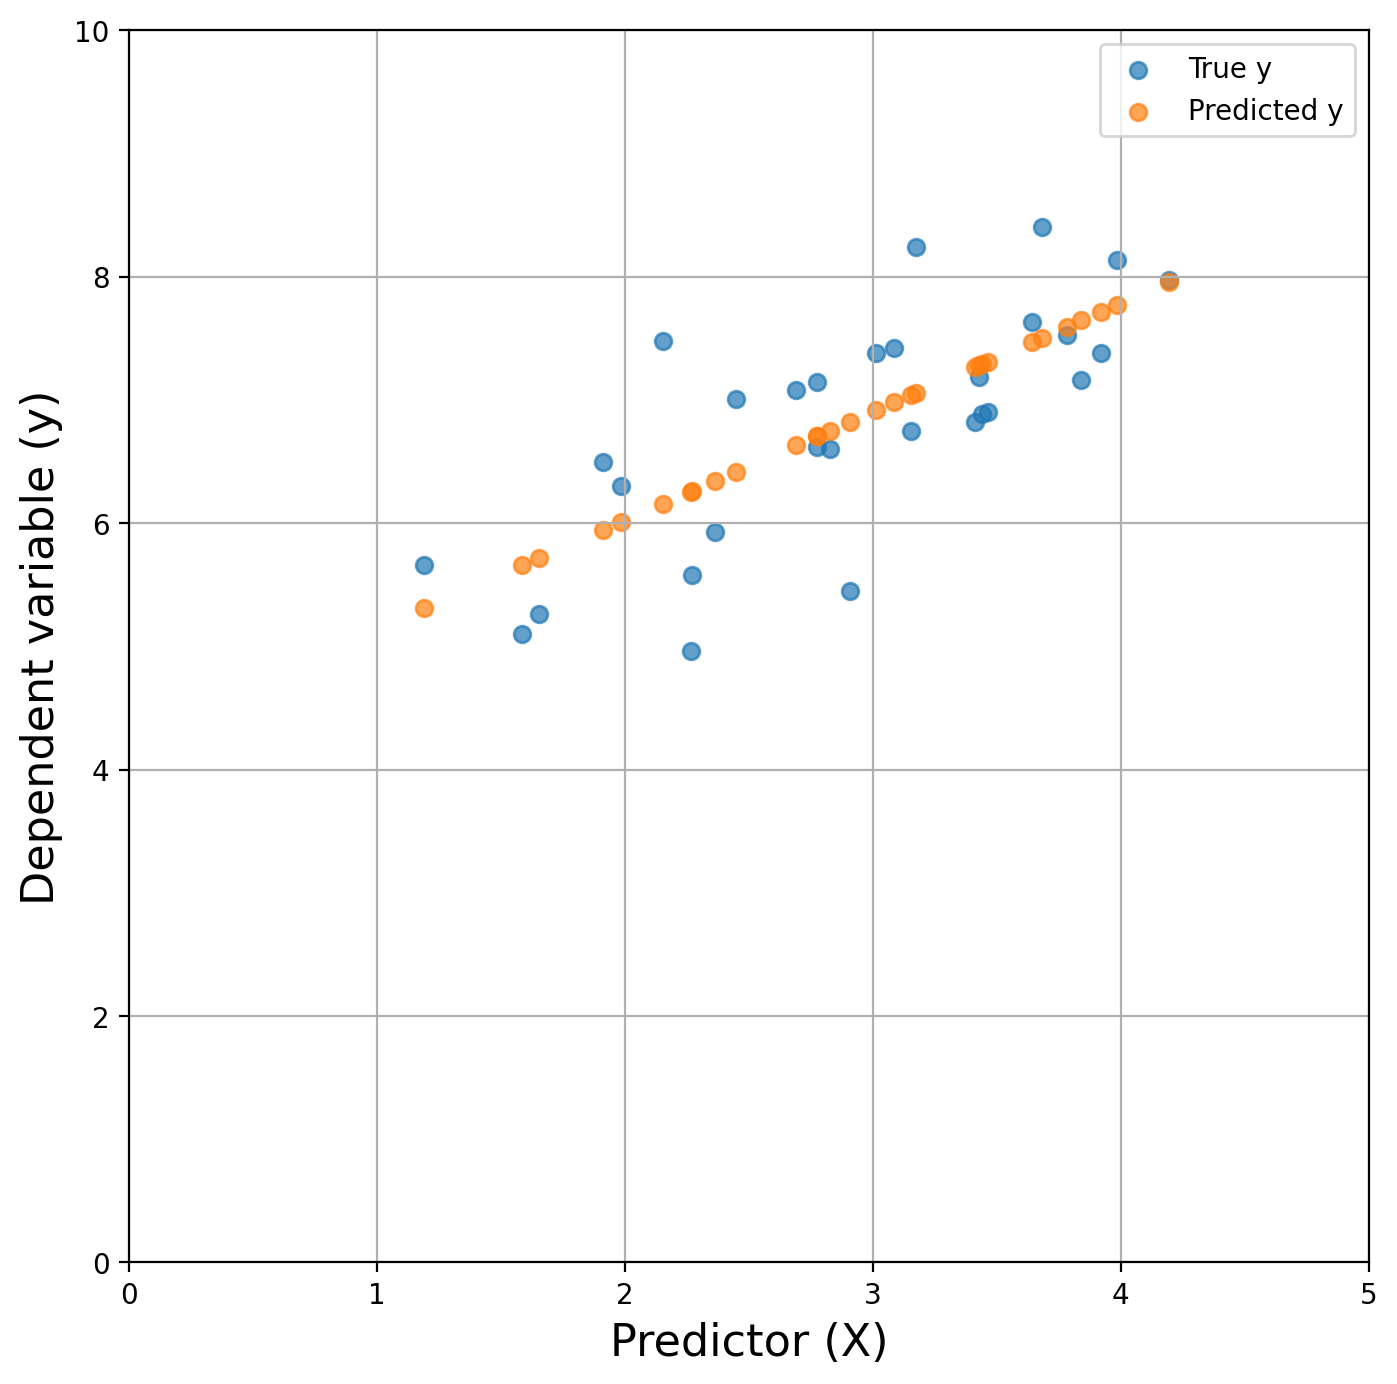

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Scatter plot of the observed data
plt.scatter(X, y, label="True y", alpha=0.7)

# Calculate predictions using matrix multiplication
y_hat = X_with_intercept @ beta_hat

# Scatter plot of the predicted values
plt.scatter(X, y_hat, c="tab:orange", label="Predicted y", alpha=0.7)

# Axis labels and limits
plt.xlabel("Predictor (X)", fontsize=16)
plt.ylabel("Dependent variable (y)", fontsize=16)
plt.xlim(0, 5)
plt.ylim(0, 10)

# Add legend and grid
plt.legend()
plt.grid(True)
plt.show()

Instead of plotting the predicted $\hat{\textcolor{blue}{y}}$ values as points, we can draw them as a **line**. This connects the predictions across the range of $\textcolor{orange}{X}$, giving us the familiar straight regression line you’ve probably seen in statistics classes.

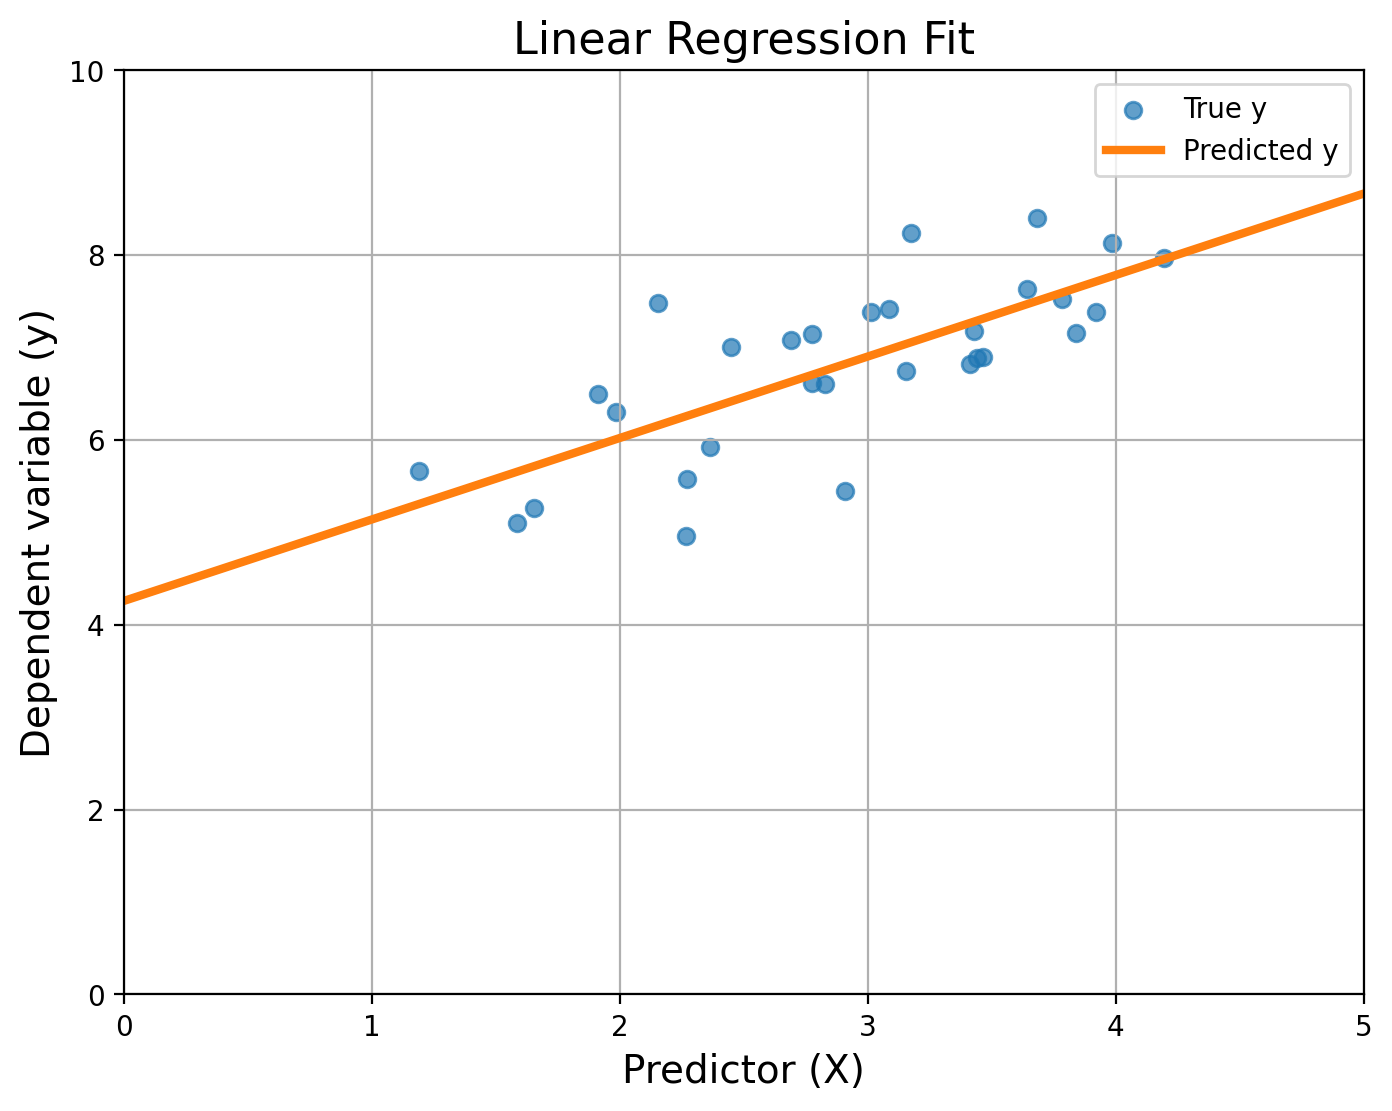

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Scatter plot of the observed data
plt.scatter(X, y, label="True y", alpha=0.7)

# Compute predicted y-values at the edges of the x-range
x_lim = (0, 5)
x_min, x_max = x_lim
y_min_pred = beta_hat[0] + beta_hat[1] * x_min
y_max_pred = beta_hat[0] + beta_hat[1] * x_max

# Plot regression line
plt.plot([x_min, x_max], [y_min_pred, y_max_pred],
         color="tab:orange", linewidth=3, label="Predicted y")

# Labels, title, and legend
plt.xlabel("Predictor (X)", fontsize=14)
plt.ylabel("Dependent variable (y)", fontsize=14)
plt.title("Linear Regression Fit", fontsize=16)
plt.xlim(x_lim)
plt.ylim(0, 10)
plt.legend()
plt.grid(True)

plt.show()

### Residuals and Model Fit

Now that we’ve estimated the parameters $\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$,  
we can use them to make the best possible predictions of $\textcolor{blue}{y}$.  

But how do we **quantify how well the model fits**?  
One simple way is to look at the **residuals**: the differences between the predicted values  
($\hat{\textcolor{blue}{y}}$) and the true values ($\textcolor{blue}{y}$).  

These residuals are exactly what we denoted earlier as $\textcolor{gray}{\varepsilon}$,  
the **error term** in the linear regression model.  

Formally:  

$$
\textcolor{gray}{\varepsilon} = \textcolor{blue}{y} - \textcolor{orange}{\mathbf{X}} \hat{\boldsymbol{\textcolor{darkred}{\beta}}}
$$  

---

#### Visualising residuals
We can plot the residuals as dashed red lines, showing the vertical distance  
between each observed data point and its predicted value on the regression line.

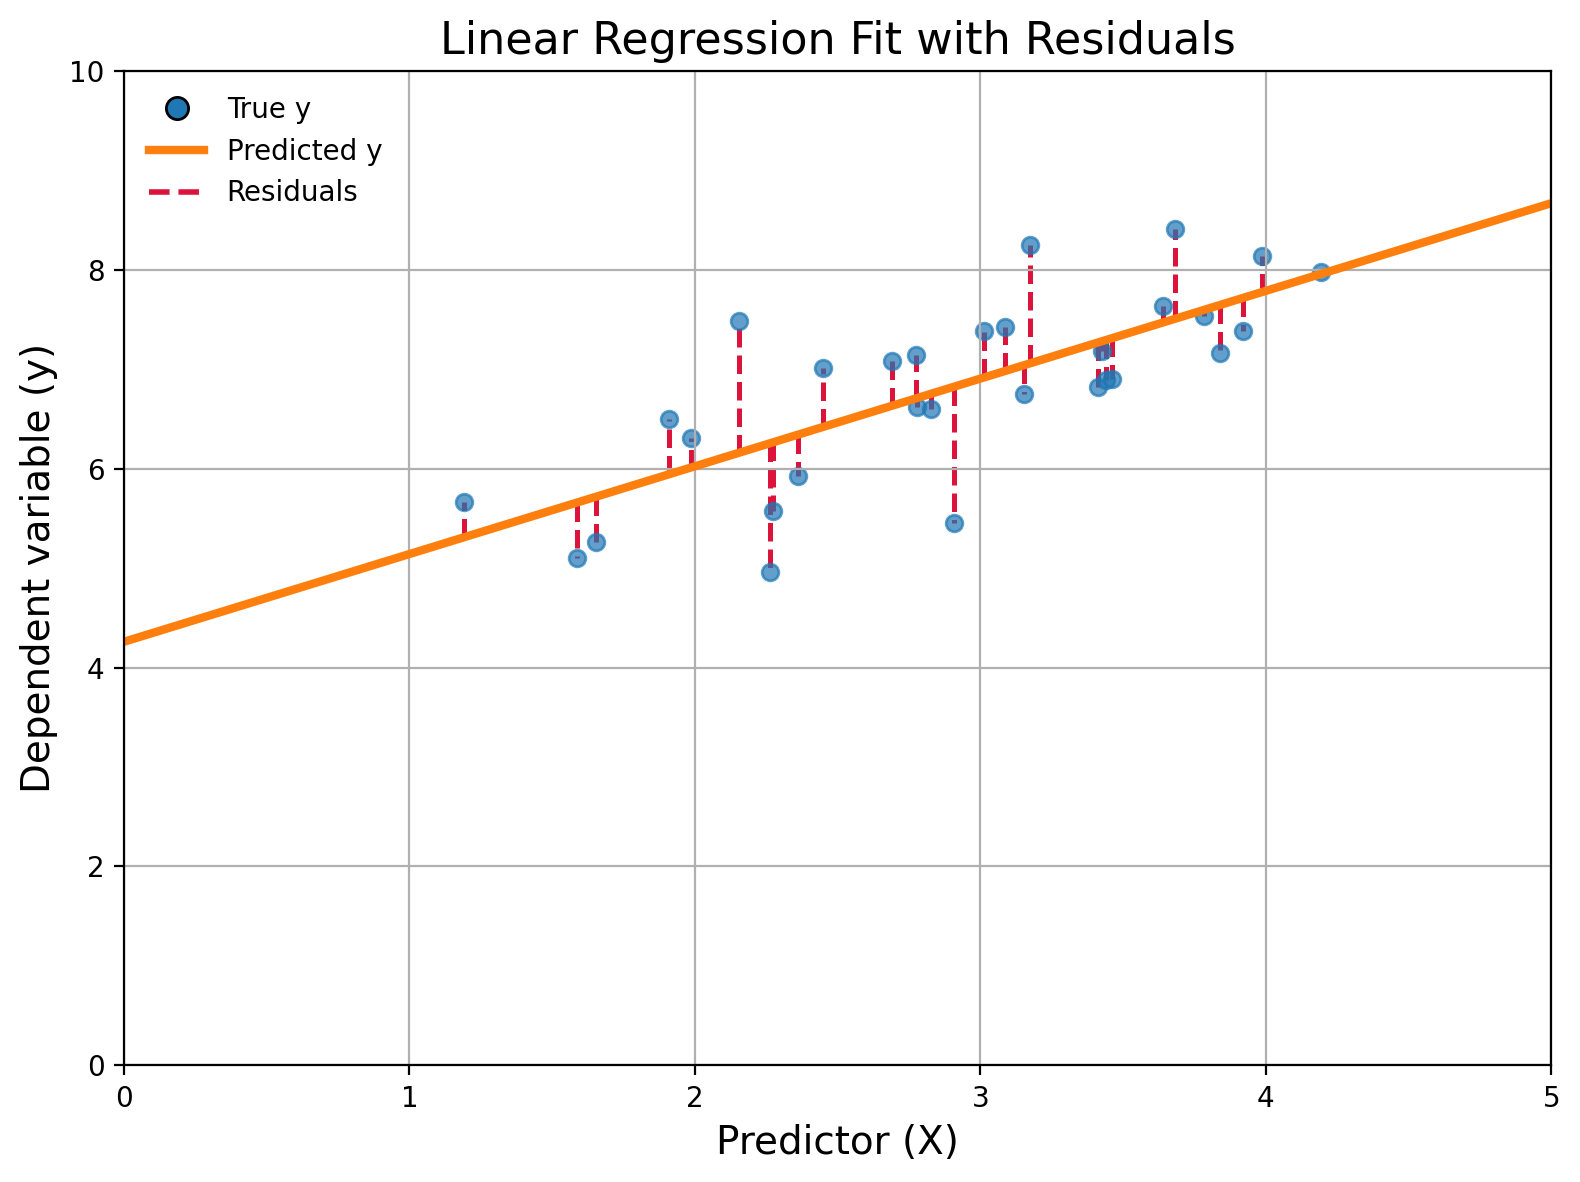

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(8, 6))

# Scatter: observed data
plt.scatter(X, y, label="True y", alpha=0.7)

# Regression line from beta_hat
x_min, x_max = x_lim
y_min_pred = beta_hat[0] + beta_hat[1] * x_min
y_max_pred = beta_hat[0] + beta_hat[1] * x_max
plt.plot([x_min, x_max], [y_min_pred, y_max_pred],
         color="tab:orange", linewidth=3, label="Predicted y")

# Predicted values at observed X (ensure column vectors become 1D)
y_hat = (X_with_intercept @ beta_hat).ravel()

# Residuals as dashed vertical lines
plt.vlines(X.ravel(), y_hat, y.ravel(),
           colors="crimson", linestyles="--", linewidth=1.8, zorder=0)

# Labels, limits, title
plt.xlabel("Predictor (X)", fontsize=14)
plt.ylabel("Dependent variable (y)", fontsize=14)
plt.title("Linear Regression Fit with Residuals", fontsize=16)
plt.xlim(x_lim)
plt.ylim(0, 10)
plt.grid(True)

# Custom legend (points, line, residuals)
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='tab:blue', markersize=8, label='True y'),
    Line2D([0], [0], color='tab:orange', linewidth=3, label='Predicted y'),
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=2, label='Residuals')
]
plt.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.show()

### Quantifying Model Fit: Mean Squared Error (MSE)

One common way to summarise model fit is by calculating the **mean of the squared residuals**,  
known as the **Mean Squared Error (MSE)**.  

Intuitively, this means:  
- Take the length of each residual (the red dashed lines),  
- Square it (so positive and negative errors don’t cancel out),  
- Average across all $N$ observations.  

In other words, the MSE is the **average squared difference** between the predicted values  
($\hat{\textcolor{blue}{y}}$) and the true values ($\textcolor{blue}{y}$):  

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N} \left(\textcolor{blue}{y_{i}} - \hat{\textcolor{blue}{y}}_{i}\right)^2
$$  

---

💡 Note: the term $\tfrac{1}{N}\sum_{i=1}^{N}$ is just another way of writing “take the average across all samples from 1 to $N$.”

<div class='alert alert-warning'>

<b>ToDo</b> (1 point)  

Compute the **Mean Squared Error (MSE)** for our model predictions (`y_hat`)  
based on the linear regression of `y` on `X_with_intercept`.  

👉 Requirements:  
- Use **vectorised NumPy operations** (no Python *for*-loops).  
- Store the result in a variable named `mse`.  

</div>

In [20]:
# Implement your ToDo here
# YOUR CODE HERE
import numpy as np 
mse = np.mean((y - y_hat) ** 2) # squared errors

In [21]:
# Feedback cell
if "mse" not in locals():
    print('The variable "mse" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(mse):
    print('"mse" should be a single numeric value (a float).')
elif not np.isclose(mse, 1.32, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


### Another Metric for Model Fit: R-squared ($R^2$)

Another commonly used measure of model fit in linear regression is **R-squared** ($R^2$).  

It is defined as:  

$$
R^2 = 1 - \frac{\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \hat{\textcolor{blue}{y}}_i\right)^2}
               {\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \bar{\textcolor{blue}{y}}\right)^2}
$$  

where $\bar{\textcolor{blue}{y}}$ is the mean of $\textcolor{blue}{y}$.  

---

#### Intuition
The formula has two parts:  
- **Denominator:** $\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \bar{\textcolor{blue}{y}}\right)^2$  
  - the *total variation* in $\textcolor{blue}{y}$ relative to its mean.  
- **Numerator:** $\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \hat{\textcolor{blue}{y}}_i\right)^2$  
  - the *remaining error* after fitting the model with predictors $\textcolor{orange}{X}\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$.  

So, $R^2$ tells us **how much of the total variance in $\textcolor{blue}{y}$ is explained by the predictors $\textcolor{orange}{X}$**.  

---

#### Interpretation
Two common ways to interpret $R^2$:  
- *Improvement over the mean model:* How much better our regression model is compared to a model that just predicts the mean $\bar{\textcolor{blue}{y}}$.  
- *Explained variance:* The proportion of variance in $\textcolor{blue}{y}$ that is explained by the predictors $\textcolor{orange}{X}$.  

---

Now let’s implement this calculation in code.

In [22]:
# Calculate R² manually
ss_res = np.sum((y - y_hat) ** 2)          # residual sum of squares (errors)
ss_tot = np.sum((y - np.mean(y)) ** 2)     # total sum of squares (variation around the mean)

r_squared = 1 - ss_res / ss_tot

print(f"R²: {r_squared:.3f}")

R²: -45.463


<div class='alert alert-warning'>

<b>ToDo</b> (1 point)  

We’ve provided a design matrix (`X_test`, including an intercept)  
and a dependent variable (`y_test`).  

👉 Your task:  
- Fit a linear regression model of `y_test` on `X_test`.  
- Calculate the **R² value** for this model.  
- Store the result in a variable named `r_squared_test`.  

</div>

In [23]:
data_tmp = np.load('data_todo_rsquared.npz')
X_test, y_test = data_tmp['X'], data_tmp['y']

# Implement your solution here
# YOUR CODE HERE
import numpy as np
# beta coefficients based on the equation
betas = np.linalg.inv(X_test.T @ X_test) @ X_test.T @ y_test # inverse of square matrix
# predicted values
y_hat = X_test @ betas
# compute R²
ss_res = np.sum((y_test - y_hat) ** 2) # residual sum of squares
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2) # total sum of sqaures
r_squared_test = 1 - (ss_res / ss_tot)
print(r_squared_test)

0.3632447637875489


In [24]:
# Feedback cell
if "r_squared_test" not in locals():
    print('The variable "r_squared_test" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(r_squared_test):
    print('"r_squared_test" should be a single numeric value (a float).')
elif not np.isclose(r_squared_test, 0.36, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


<div class='alert alert-info'>

<b>ToThink</b> (1 point)  

As we discussed earlier, including an **intercept** in regression models is usually very important — it often leads to a much better model fit.

👉 Your task:  
- Look at the plot below, which shows the data (`X_no_intercept`, `y`) and the regression line *without* an intercept.
- In the text cell under the plot, explain **why including an intercept usually improves model fit**.

💡 Keep your explanation concise — this will be graded manually (no feedback cell).

</div>

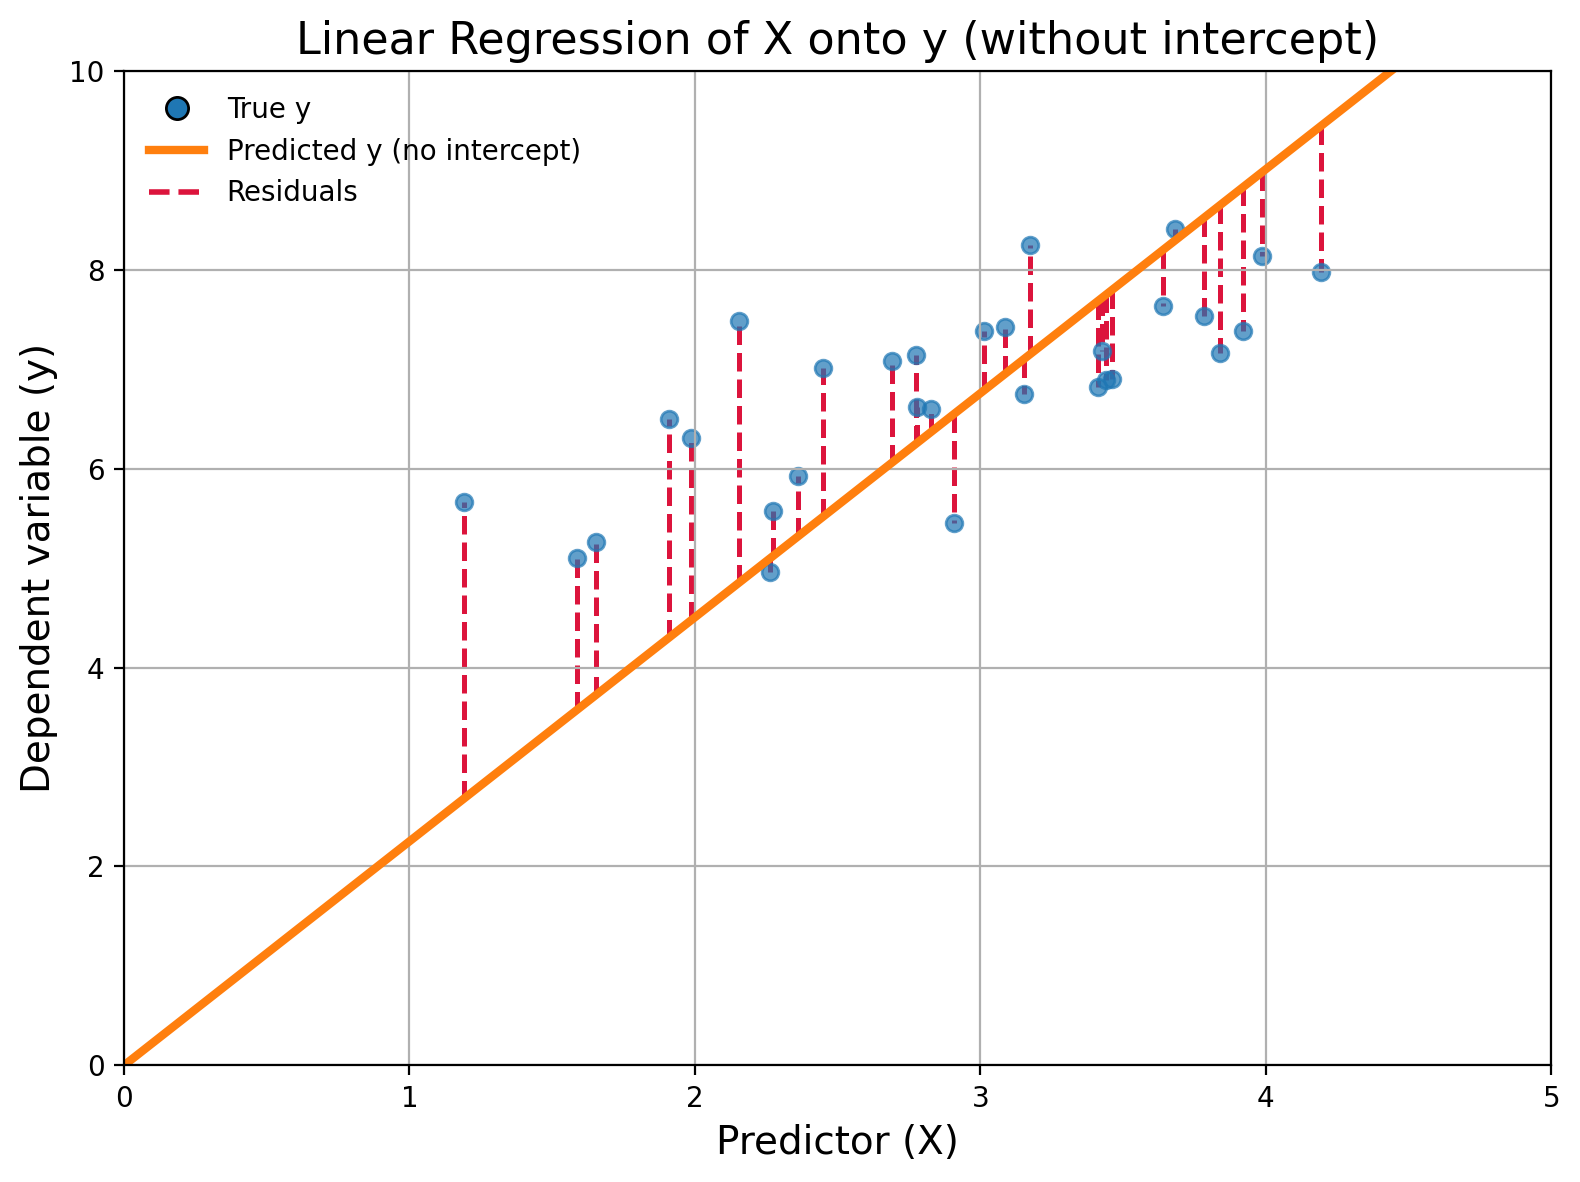

In [25]:
from numpy.linalg import inv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Drop the intercept column: keep only the original predictor
X_no_intercept = X_with_intercept[:, 1:2]  # shape (N, 1)

# OLS without intercept
beta_no_intercept = inv(X_no_intercept.T @ X_no_intercept) @ (X_no_intercept.T @ y)

# Predictions without intercept
y_hat_no_intercept = (X_no_intercept @ beta_no_intercept).ravel()

# Prepare regression line over the x-range
x_min, x_max = 0, 5
y_min_pred = float(beta_no_intercept[0, 0] * x_min)
y_max_pred = float(beta_no_intercept[0, 0] * x_max)

# Plot
plt.figure(figsize=(8, 6))

# Observed data
plt.scatter(X, y, label="True y", alpha=0.7)

# Regression line (no intercept)
plt.plot([x_min, x_max], [y_min_pred, y_max_pred],
         color="tab:orange", linewidth=3, label="Predicted y (no intercept)")

# Residuals as dashed vertical lines
plt.vlines(X.ravel(), y_hat_no_intercept, y.ravel(),
           colors="crimson", linestyles="--", linewidth=1.8, zorder=0)

# Labels, limits, title
plt.xlabel("Predictor (X)", fontsize=14)
plt.ylabel("Dependent variable (y)", fontsize=14)
plt.title("Linear Regression of X onto y (without intercept)", fontsize=16)
plt.xlim(x_min, x_max)
plt.ylim(0, 10)
plt.grid(True)

# Legend
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='tab:blue', markersize=8, label='True y'),
    Line2D([0], [0], color='tab:orange', linewidth=3, label='Predicted y (no intercept)'),
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=2, label='Residuals'),
]
plt.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.show()

YOUR ANSWER HERE

An intercept corresponds to the average value of our dependent variable y when all predictors in X are 0. This ensures that the model accounts for the baseline level of y, beyond the effects of the other predictors. Moreover, as evident from the above plot, the residual distance or error component \(i.e., distance between the true values and the predicted regression line\) is high. With an intercept in the model, the regression function can be optimised to take any value at X = 0, which increases the flexibility of the model to find the best fit to the data. 


### Summary: Linear Regression

We’ve now refreshed the key ideas of linear regression:  

- **Predictors / design matrix ($\textcolor{orange}{X}$)**  
- **Target variable ($\textcolor{blue}{y}$)**  
- **Ordinary Least Squares (OLS)** to estimate parameters  
- **β parameters ($\textcolor{darkred}{\beta}$)**, including the intercept  
- **Predictions ($\hat{\textcolor{blue}{y}}$)**  
- **Residuals ($\textcolor{gray}{\varepsilon}$)**  
- **Model fit metrics:** MSE and $R^2$  

---

### In short
- Use predictors ($\textcolor{orange}{X}$) to model a target ($\textcolor{blue}{y}$).  
- OLS finds the $\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$ values that minimise the **sum of squared residuals**.  
- Model fit can be assessed with:  
  - **MSE:** average squared prediction error  
  - **$R^2$:** proportion of variance in $\textcolor{blue}{y}$ explained by $\textcolor{orange}{X}$  

---

Next, we’ll test your understanding before applying these concepts to the real challenge:  
**modelling fMRI data with the GLM.**

<div class='alert alert-warning'>

<b>ToDo</b> (2 points)  

Now it’s your turn to implement a full linear regression model — this time with **5 predictors**.  
(Don’t worry, the code is almost the same as with a single predictor + intercept.)  

Your goal:  
- Fit the model,  
- Calculate the **MSE** and **$R^2$**,  
- Store them in variables named `mse_todo` and `r2_todo`.  

---

⚠️ Note: Since $\textcolor{orange}{X}$ is now 5-dimensional (6-dimensional including the intercept),  
it’s not possible to directly plot $\textcolor{orange}{X}$, $\textcolor{blue}{y}$, or $\hat{\textcolor{blue}{y}}$.

---

### Steps to guide you
1. **Check the shapes**  
   - Is `X` of shape `(N, P)`?  
   - Is `y` of shape `(N, 1)`?  
2. **Add an intercept** using `np.hstack`.  
3. **Estimate β parameters** with the OLS formula:  
   $$
   \hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y}
   $$  
4. **Evaluate model fit**  
   - Compute the **MSE** (mean squared error).  
   - Compute **$R^2$** (explained variance).  

</div>

In [26]:
# First, we load the data
data = np.load('ToDo.npz')
X, y = data['X'], data['y']

In [27]:
# ASSIGNMENT CELL
"""
ToDo (2 points):
Implement linear regression with 5 predictors (+ intercept).
Steps:
1. Check the dimensions of X: N (rows), P (columns)
2. Add an intercept to X
3. Compute beta_hat using OLS closed-form
4. Compute predictions y_hat
5. Calculate mse_todo (MSE) and r2_todo (R²)

Expected outputs:
- N        : rows of X
- P        : columns of X
- beta_hat : shape (P+1, 1)
- y_hat    : shape (N, 1)
- mse_todo : float
- r2_todo  : float
"""

import numpy as np
from numpy.linalg import inv

# YOUR CODE HERE
# 1. check dimensions X: N (rows), P (columns)
N, P = X.shape
print(f"Number of observations (N): {N}, Number of predictors (P): {P}")

# 2. Add an intercept to X
X_with_intercept = np.hstack([np.ones((N, 1)), X])

# 3. Compute beta_hat using OLS formula 
beta_hat = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

# 4. Compute predictions y_hat
y_hat = X_with_intercept @ beta_hat

# 5. Caculate MSE
mse_todo = np.mean((y - y_hat) ** 2)
#   calculate R²
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2_todo = 1 - (ss_res / ss_tot)

# print results 
print("Beta estimates:", beta_hat)
print("Mean Squared Error (MSE):", mse_todo)
print("R-squared (R²):", r2_todo)

Number of observations (N): 1000, Number of predictors (P): 5
Beta estimates: [[ 6.66694315]
 [-0.01159282]
 [-0.25573929]
 [ 0.47342146]
 [ 0.21746357]
 [ 0.12759367]]
Mean Squared Error (MSE): 0.65633474948831
R-squared (R²): 0.3409337999613482


In [28]:
# Feedback cell
errors = 0

# Check if variables are defined
for variable in ['N', 'P', 'beta_hat', 'y_hat', 'mse_todo', 'r2_todo']:
    if variable not in locals():
        print(f'The variable "{variable}" is not defined. Check that you created and named the variable correctly.')
        errors += 1

# Check if the variable types match
for name, variable, shape in zip(['N', 'P', 'beta_hat', 'y_hat', 'mse_todo', 'r2_todo'], 
                                 [N, P, beta_hat, y_hat, mse_todo, r2_todo], 
                                 [(), (), (6, 1), (1000, 1), (), ()]):
    if shape == ():
        if  not np.isscalar(variable):
            print(f'"{name}" should be a single numeric value (a float).')
            errors += 1
    else:
        if not np.shape(variable) == shape:
            print(f'"{name}" should be an array with shape {shape}')
            errors += 1
            
# Check values
for name, variable, value in zip(['N', 'P', 'beta_hat', 'y_hat', 'mse_todo', 'r2_todo'], 
                                 [N, P, beta_hat, y_hat, mse_todo, r2_todo], 
                                 [1000, 5, 7.29, 6963.37, 0.66, 0.34]):
    if not np.isclose(np.sum(variable), value, rtol=1e-2):
        print(f'Hmm, something seems off with {name}. Please check your answer.') 
        errors += 1
        
if errors == 0:
    print('Well done! Your answer passed the automated checks.')
else:
    print(f'The automated checks found {errors} potential errors in your code')

Well done! Your answer passed the automated checks.


<div class='alert alert-info'>

<b>ToThink</b> (1 point)  

Let’s check whether you understand how to interpret individual β parameters.  

- Some of the estimated parameters are **negative** ($\hat{\beta} < 0$).  
  👉 What does this tell you about the effect of that predictor/condition?  
  *(0.5 point – write your answer in the first text cell)*  

- The **intercept parameter** ($\beta_{0}$) is about **6.6**.  
  👉 What does this value represent in terms of the signal?  
  *(0.5 point – write your answer in the second text cell)* 
                                                                        
💡 Keep your explanation concise — this will be graded manually (no feedback cell).  

</div>

If some of the estimated parameters are negative, they indicate that holding other predictors constant, an increase in those particular predictors is related to a decrease in the outcome.  


An intercept parameter of about 6.6 represents the average \(baseline\) signal intensity in the voxel being measured when all other predictors are zero.  


## GLM in fMRI Analyses  

Univariate fMRI analyses apply the **same linear regression framework** we’ve just explored.  
The idea is to model the activation in each voxel using a design matrix of predictors — with a few important twists specific to fMRI.  

---

### The target variable  

In “regular” regression problems, the dependent variable ($\textcolor{blue}{y}$) might be something like height, test scores, or reaction times.  

In fMRI, however, the dependent variable is a **time series**:  

- Each voxel produces a signal that fluctuates across time.  
- So here, the *observations* are successive time points of voxel activity, rather than independent samples.  

---

### Example  

To get a sense of what this looks like, let’s examine a (simulated) time series from a single voxel.



In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
%matplotlib inline

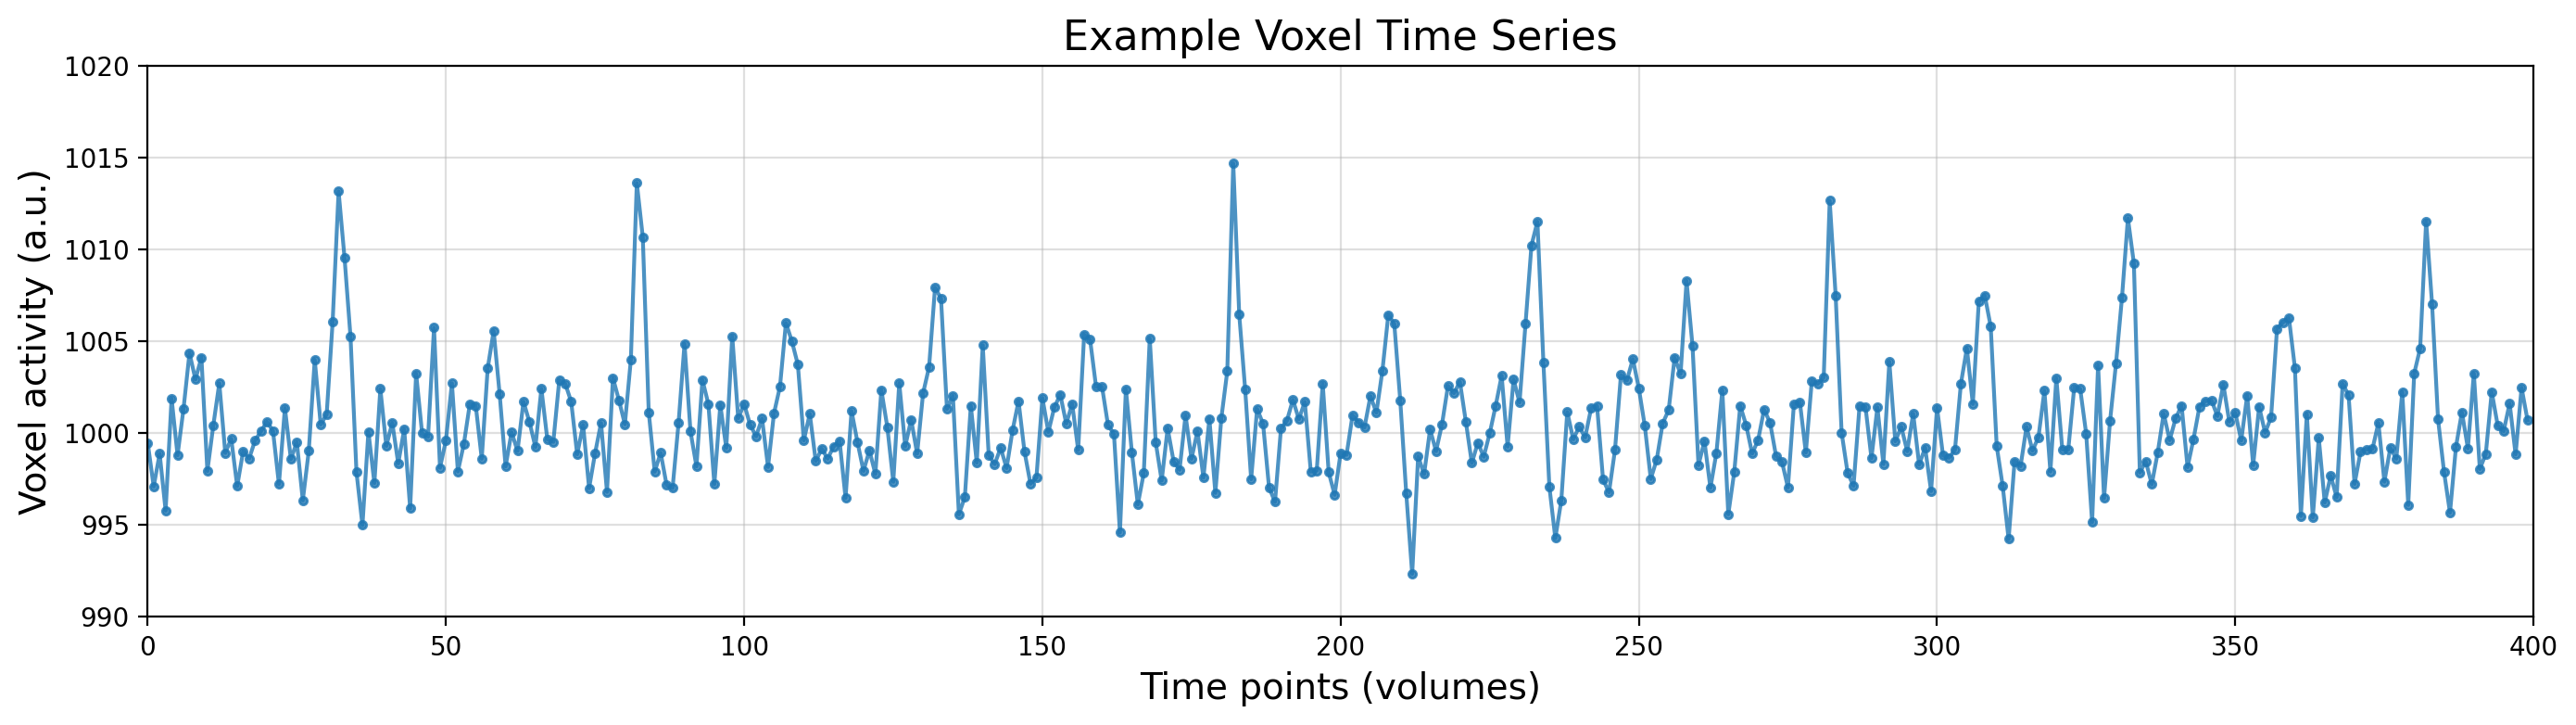

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Load example signal
voxel_signal = np.load("example_voxel_signal.npy")

# Plot the voxel time series
plt.figure(figsize=(14, 4))
plt.plot(voxel_signal, marker="o", linestyle="-", markersize=3, alpha=0.8)

# Labels and title
plt.xlabel("Time points (volumes)", fontsize=14)
plt.ylabel("Voxel activity (a.u.)", fontsize=14)
plt.title("Example Voxel Time Series", fontsize=16)

# Axis limits
plt.xlim(0, 400)
plt.ylim(990, 1020)

# Style
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

So in fMRI, the **voxel time series** — the activation measured across time (often called the *signal*) —  is our **dependent variable** ($\textcolor{blue}{y}$).  

Each **time point** (with its corresponding activity value) is treated as one observation or sample in the regression model.

👉 **Check your understanding: TR and experiment duration**

Suppose the TR (“time of repetition”) of our acquisition was **2 seconds**.  
From the voxel time series plot (with 400 time points), what was the **total duration** of the experiment in seconds?  

---

<details>
<summary>✅ Click to reveal solution</summary>

- Number of time points (volumes): **400**  
- TR per volume: **2 seconds**  
- Total duration = $400 \times 2 = 800$ seconds  

So the experiment lasted **800 seconds** (≈ **13 minutes 20 seconds**).  

</details>

In the plot above, each point represents the **activity of a single voxel** (in arbitrary units) measured at successive **time points** (volumes).  

This dot-plot makes the discrete nature of the data explicit,  but it’s not the most intuitive way to view a time series. More often, we visualise voxel activity as a **continuous line over time**. 

⚠️ *Important reminder:* fMRI is still a **discretely sampled signal** — the line is just a visual aid, not a true continuous measurement.  

Let’s re-plot the data as a line:

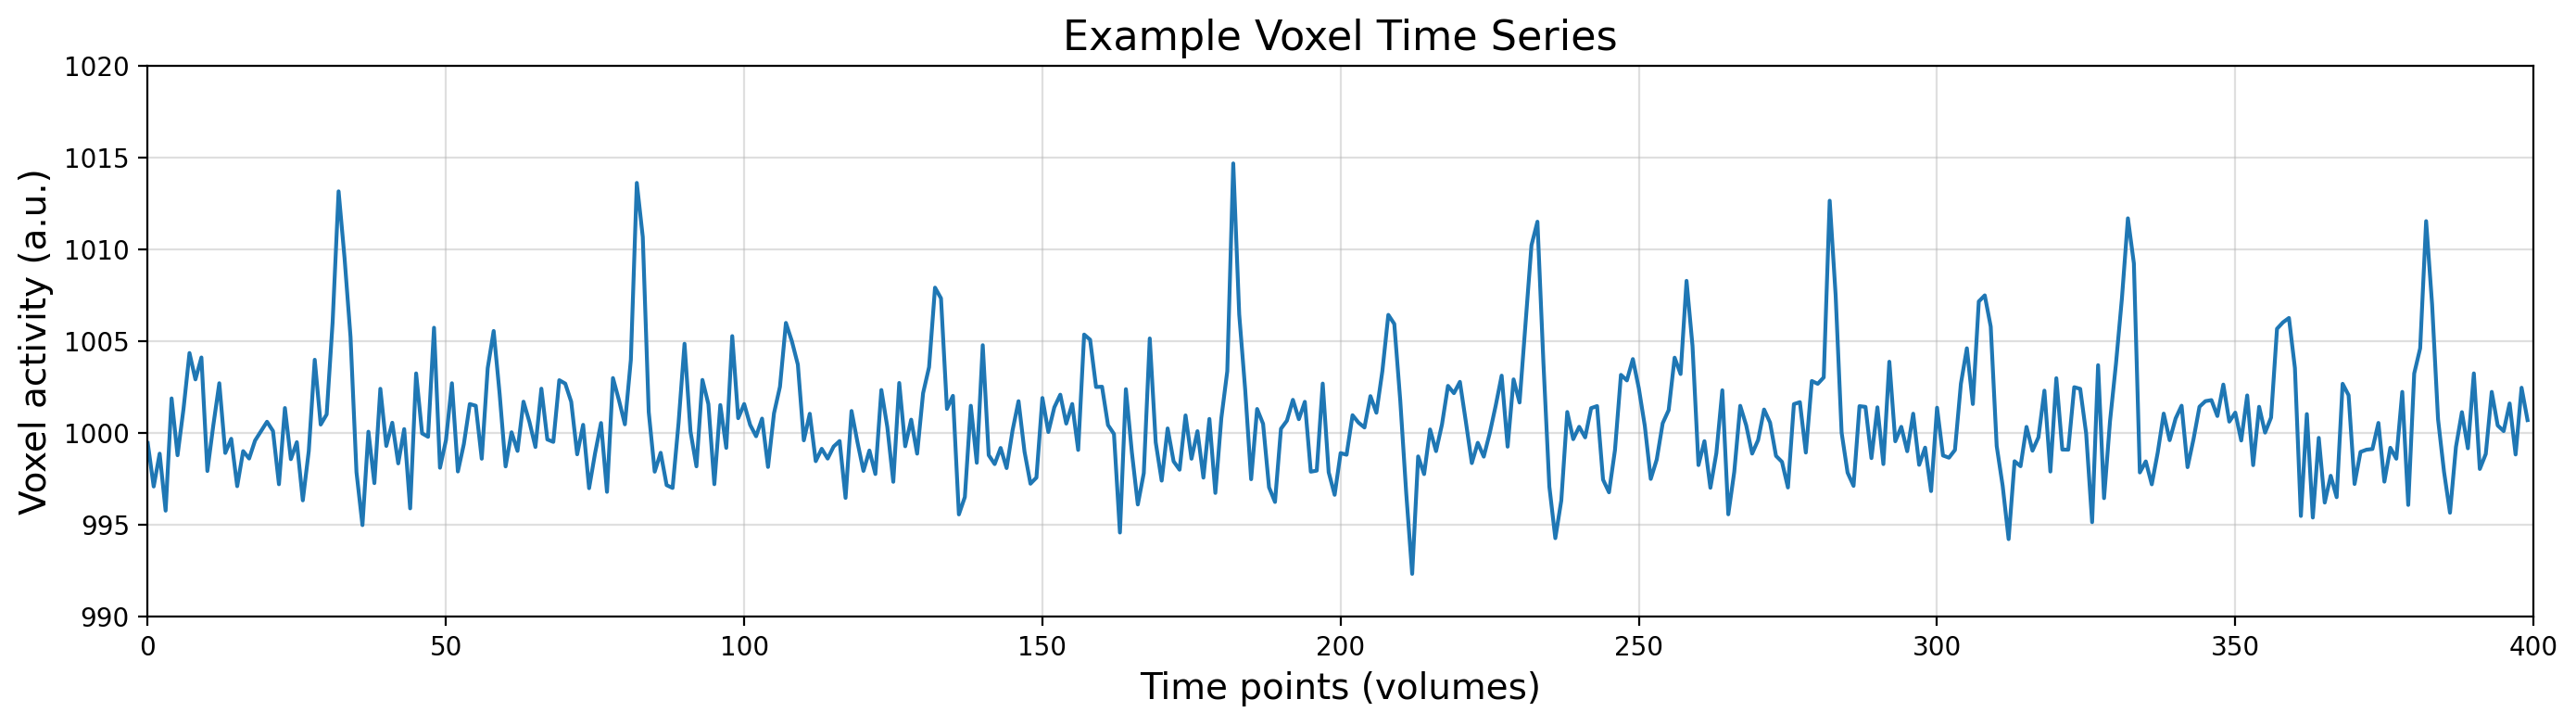

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))

# Plot voxel signal as a continuous line
plt.plot(voxel_signal, color="tab:blue", linewidth=1.5)

# Labels and title
plt.xlabel("Time points (volumes)", fontsize=14)
plt.ylabel("Voxel activity (a.u.)", fontsize=14)
plt.title("Example Voxel Time Series", fontsize=16)

# Axis limits
plt.xlim(0, 400)
plt.ylim(990, 1020)

# Style
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Much clearer!

Now let’s turn to the next piece of the GLM: our **predictors** ($\textcolor{orange}{X}$).

### The predictors: what should we use to model our target?

#### Defining independent variables  

We now know what our **target** is: the voxel time series ($\textcolor{blue}{y}$).  
But what about the **predictors** ($\textcolor{orange}{X}$) that we use to explain it?  

In most neuroimaging research, predictors are derived directly from the **experimental design**.  
That is: your predictors should represent the aspects of the experiment you believe influence the signal.  

---

#### Example experiment  

Imagine a simple (hypothetical) fMRI experiment:  
- Participants are shown images of either **circles** or **squares**.  
- The scan lasts **800 seconds**.  
- Stimuli are presented every **50 seconds**.  

![img](https://docs.google.com/drawings/d/e/2PACX-1vQwC4chpnzsDEzKhrKH_WHhMX7vJswY4H0pkyIxdlxI_I2GG5e8i6lsiWUO0SUk7NBgdV-vXD5PIleJ/pub?w=950&h=397)

*(Note: an interstimulus interval of 50 seconds is highly unrealistic — in real fMRI studies, it’s usually around 2–3 seconds. But here we use a longer interval to keep the example simple and the figures easier to read.)*  

---

#### From paradigm to predictors  

So, what predictors could we use in this design?  
A straightforward choice is to model the **stimuli themselves**.  
In other words:  
- When a stimulus (circle or square) is presented → predictor = 1  
- When no stimulus is shown → predictor = 0  

This way, our predictors directly reflect the timing of experimental events.  

Fortunately, in this example we have recorded the **onsets of all stimuli (in seconds)** during the experiment:

In [32]:
onsets_squares = np.array([10, 110, 210, 310, 410, 510, 610, 710], dtype=int)
onsets_circles = np.array([60, 160, 260, 360, 460, 560, 660, 760], dtype=int)

In this experiment, the **first circle stimulus** appeared **60 seconds** after the scan began,  
and the **last square stimulus** appeared at **710 seconds**.  

For now, we’ll **ignore the difference** between circles and squares.  
Instead, we’ll create a single predictor that combines the onsets of both stimulus types into one array.  

This predictor reflects the hypothesis that the signal is influenced simply by the **presence of a stimulus** —  
regardless of whether it was a circle or a square.  

*(Later in the tutorial, we’ll learn how to model and compare different conditions separately.)*  

We’ll call this predictor: `onsets_all`.

In [33]:
onsets_all = np.concatenate((onsets_squares, onsets_circles))
print(onsets_all)

[ 10 110 210 310 410 510 610 710  60 160 260 360 460 560 660 760]


Now we need to take one final step: turn the `onsets_all` vector into a **usable predictor**.  

At the moment, `onsets_all` only stores the *timing* of the stimuli (in seconds).  
But a predictor in the GLM must be an **array with the same length as the target** ($\textcolor{blue}{y}$).  

Since our hypothesis is that the signal increases **when a stimulus is present** (and stays at baseline otherwise),  
we can represent the predictor as:  

- a vector of all **zeros**,  
- with **ones** at the time points corresponding to stimulus onsets.  

This gives us a binary predictor: “stimulus present” = 1, “stimulus absent” = 0.  

Here’s how to construct it:

In [34]:
# Create a predictor vector (length = experiment duration in seconds)
predictor_all = np.zeros(800, dtype=int)   # 800 time points (seconds)
predictor_all[onsets_all] = 1              # set stimulus onsets to 1

# Inspect shape and first part of the array
print(f"Shape of predictor: {predictor_all.shape}")
print("First 100 values of predictor (truncated view):")
print(predictor_all[:100])

Shape of predictor: (800,)
First 100 values of predictor (truncated view):
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


We can also **visualise the predictor** in the same way we plotted the voxel signal.  
This helps us see exactly **when the model expects a response** (stimulus present = 1, absent = 0).

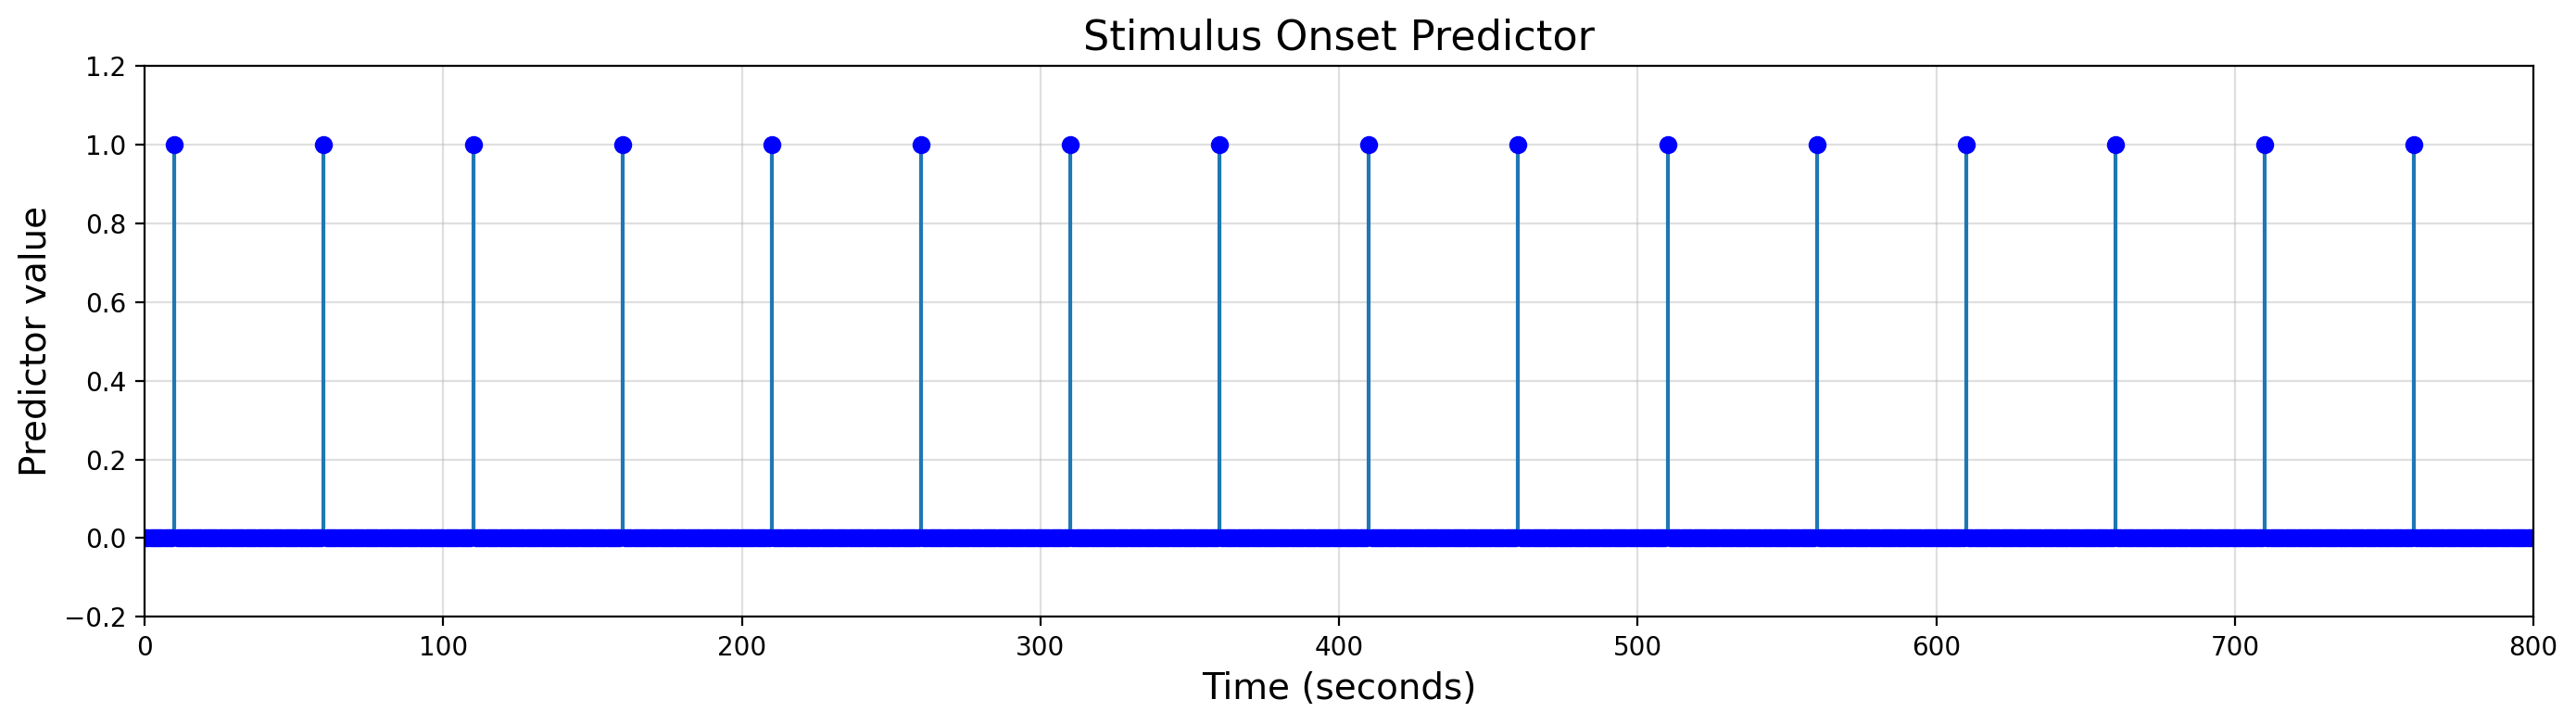

In [35]:
plt.figure(figsize=(14, 4))

# Plot predictor as a stem-like signal
plt.stem(range(len(predictor_all)), predictor_all,
         basefmt=" ", linefmt="tab:blue", markerfmt="bo")

# Labels and title
plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Predictor value", fontsize=14)
plt.title("Stimulus Onset Predictor", fontsize=16)

# Axis limits
plt.xlim(0, 800)
plt.ylim(-0.2, 1.2)

# Style
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### Resampling  

If you look back at the voxel signal plot, you may have noticed a mismatch:  
our **stimulus predictor** and the **voxel signal** are on *different time scales*.  

- The voxel signal is measured in **volumes**: 400 time points, with a TR of **2 seconds**.  
- The stimulus onsets are recorded in **seconds**: ranging from 10 to 760.  

---

To align the two, we need to **resample the predictor** to match the temporal resolution of the fMRI signal.  
That means: one predictor value per volume → i.e., **one data point every 2 seconds**.  

In the plot below, we illustrate this process:  
the **dashed red lines** mark which predictor values are kept after downsampling  
(here shown only for the first 100 seconds for clarity).

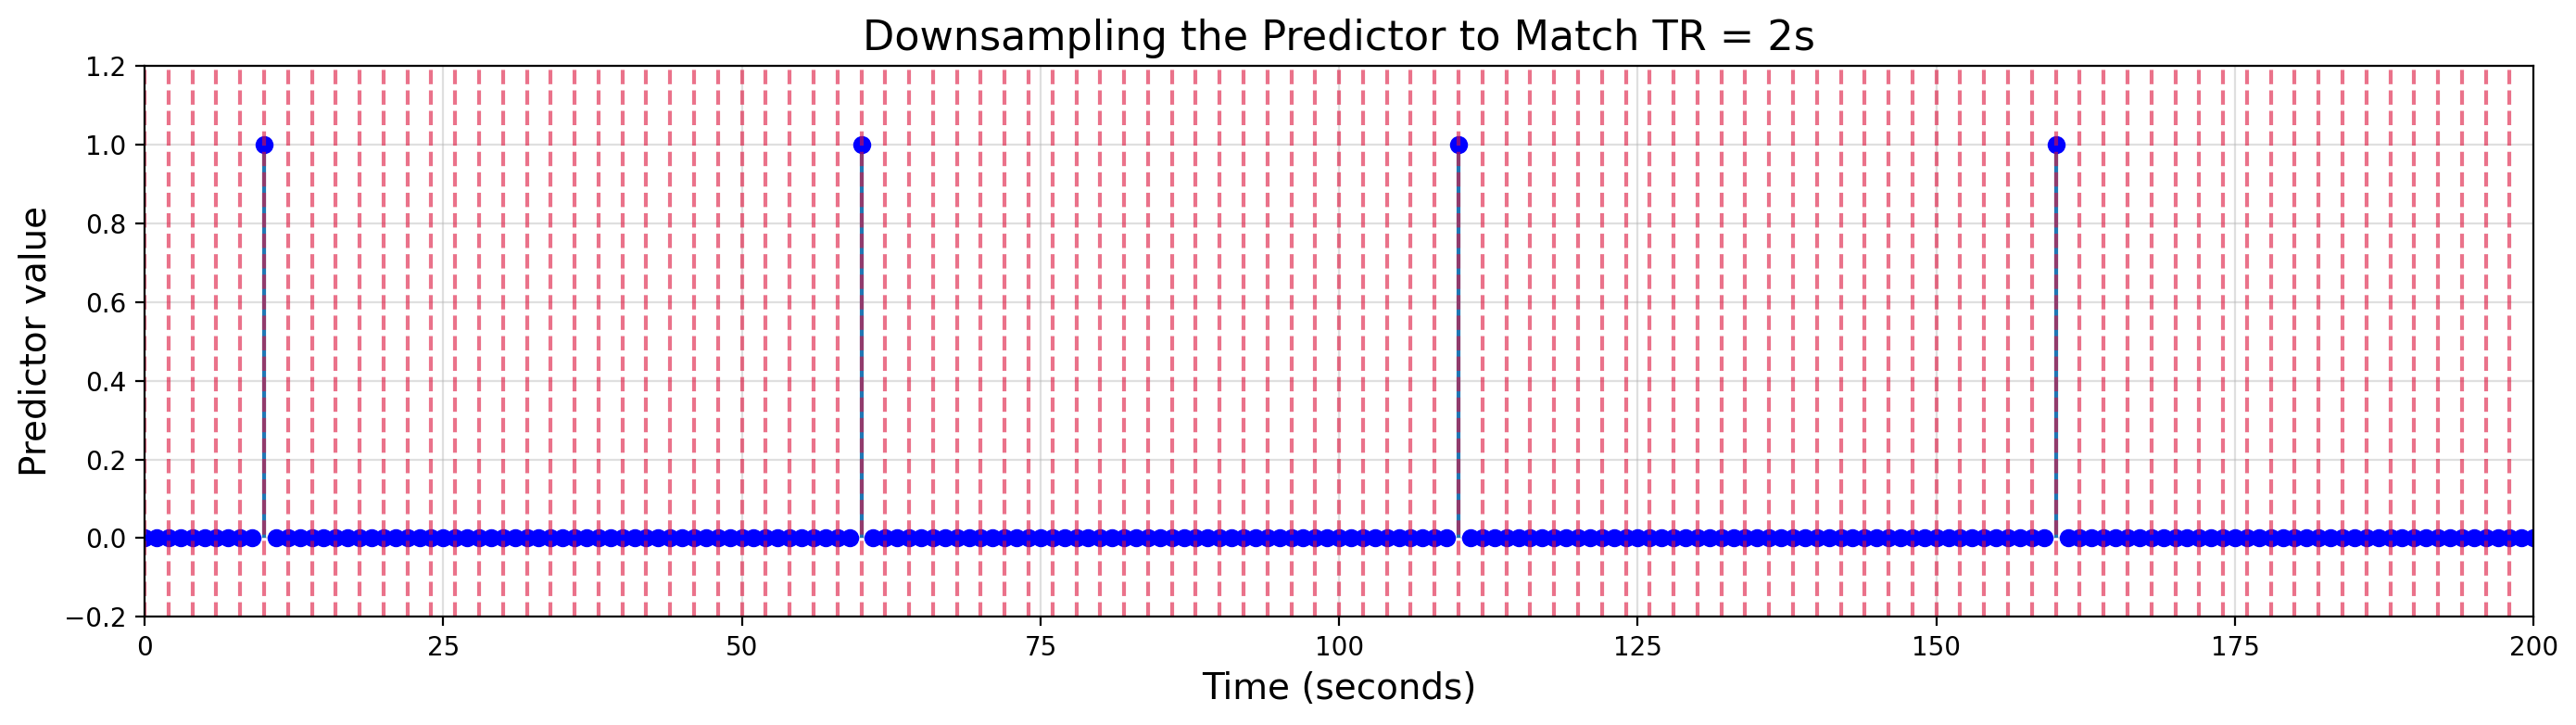

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 4))

# Plot the original predictor (binary events)
plt.stem(
    range(len(predictor_all)), predictor_all,
    basefmt=" ", linefmt="tab:blue", markerfmt="bo"
)

# Add vertical dashed lines at TR intervals (every 2 seconds)
for t in np.arange(0, 200, 2):
    plt.axvline(t, linestyle="--", color="crimson", alpha=0.6)

# Labels and title
plt.xlabel("Time (seconds)", fontsize=14)
plt.ylabel("Predictor value", fontsize=14)
plt.title("Downsampling the Predictor to Match TR = 2s", fontsize=16)

# Axis limits
plt.xlim(0, 200)
plt.ylim(-0.2, 1.2)

# Style
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Resampling in Python  

We can perform resampling in Python using the `interp1d` function from the `scipy.interpolate` module.  

The idea is simple:  
1. **Map** the values of the original array to its original scale (here, seconds).  
2. **Re-express** those values on a new scale (here, the fMRI sampling grid).  

Here’s the general workflow:  

```python
from scipy.interpolate import interp1d

# Create a resampler (this returns a new function)
resampler = interp1d(original_scale, original_array, kind="linear")

# Apply the resampler on the desired scale
downsampled_array = resampler(desired_scale)
```
---

### Important notes
- interp1d returns a **new function** (resampler). You then call this function with your desired scale to get the resampled array.
- Here we use `kind="linear"`, i.e. linear interpolation.
    - In practice, neuroimaging software often uses more sophisticated interpolation methods.
    - But for our purposes, linear interpolation is enough to illustrate the principle.
- This works both for **downsampling** and **upsampling**.

---

Our example

Let’s resample our predictor:
- Original scale: seconds from 0 to 800.
- New scale: the fMRI acquisition grid, i.e. 0, 2, 4, …, 800 (because TR = 2s).

We’ll use `np.arange(start, stop, step)` to generate this evenly spaced grid:

In [37]:
from scipy.interpolate import interp1d

# Define the original scale (1-second resolution)
original_scale = np.arange(0, 800, 1)   # 0–799 seconds
print(f"Original scale: {original_scale.size} points (1 per second)")

# Create resampler function (linear interpolation by default)
resampler = interp1d(original_scale, predictor_all, kind="linear")

# Define the desired scale (TR = 2s → one sample every 2 seconds)
desired_scale = np.arange(0, 800, 2)    # 0, 2, 4, ... 798
print(f"Desired scale: {desired_scale.size} points (1 per volume, TR=2s)")

# Apply resampling
predictor_all_ds = resampler(desired_scale)

print(f"Downsampled predictor: {predictor_all_ds.size} points (aligned with volumes)")

Original scale: 800 points (1 per second)
Desired scale: 400 points (1 per volume, TR=2s)
Downsampled predictor: 400 points (aligned with volumes)


Great! 

We now have a **predictor** ($\textcolor{orange}{X}$) and a **target** ($\textcolor{blue}{y}$) with the **same shape**.  
That means we’re ready to apply **linear regression**.  

But before fitting the model, let’s **visualise predictor and signal together** in the same plot:

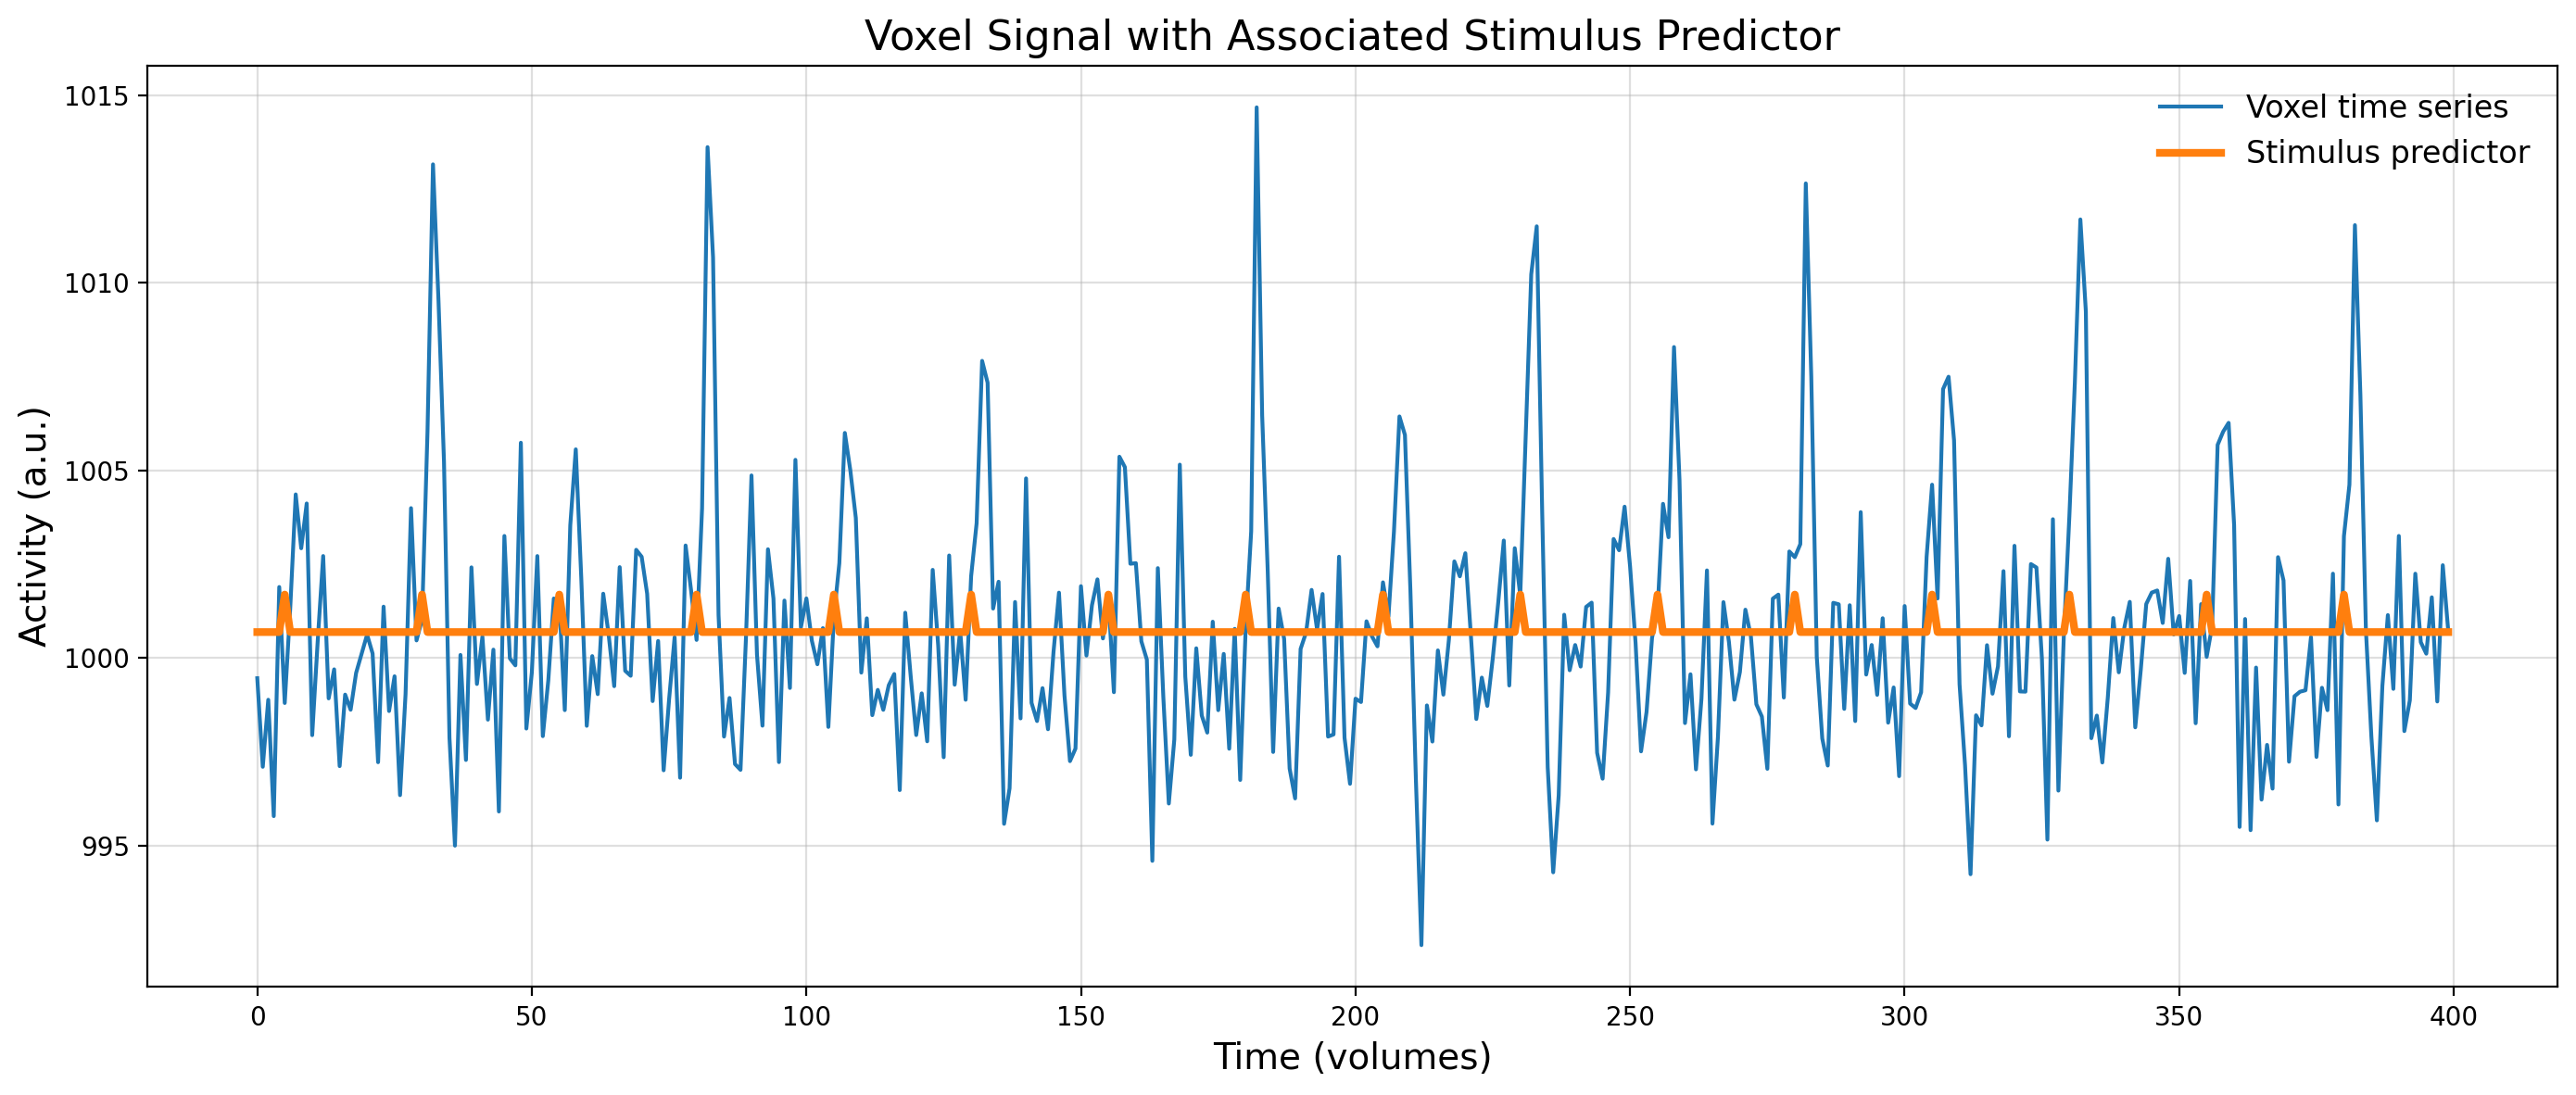

In [38]:
plt.figure(figsize=(14, 6))

# Plot voxel signal
plt.plot(voxel_signal, color="tab:blue", label="Voxel time series")

# Plot predictor (shifted to mean of signal for visibility)
plt.plot(
    predictor_all_ds + voxel_signal.mean(),
    color="tab:orange", linewidth=3, label="Stimulus predictor"
)

# Labels and title
plt.xlabel("Time (volumes)", fontsize=14)
plt.ylabel("Activity (a.u.)", fontsize=14)
plt.title("Voxel Signal with Associated Stimulus Predictor", fontsize=16)

# Legend & grid
plt.legend(fontsize=12, loc="upper right", frameon=False)
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

In practice, the **design matrix** is usually defined with a much **finer temporal resolution** than in our simple example.  
Instead of seconds, predictors are often specified in **milliseconds**.  

Why? Because stimulus onsets are not always locked to whole seconds (e.g. $t = 10.296$).  
Using a higher-resolution scale ensures that these timings are captured accurately.  

We’ll return to this issue later in the tutorial.  

---

👉 But before that, let’s practice!

<div class='alert alert-warning'>

<b>ToDo</b> (2 points)  

We’ve defined an array of onsets (`onsets2`) for a hypothetical experiment:  
- Total duration = **60 seconds**  
- TR = **3 seconds**  

👉 Your tasks:  
1. Create a **predictor** at the timescale of **seconds** (length = 60).  
   - Name this array `pred2`.  
2. **Downsample** the predictor to the fMRI acquisition scale  
   (time points: 0, 3, 6, 9, …, 57).  
   - Store the downsampled version in `pred2_ds`.  

</div>

In [39]:
# Implement your ToDo Here
import numpy as np
onsets2 = np.array([12, 24, 33, 42], dtype=int)

# First create pred2
# parameters
total_duration = 60
pred2 = np.zeros(total_duration, dtype=int)
pred2[onsets2] = 1
print(pred2)

# Then downsample it to create pred2_ds
TR = 3 # TR parameter
num_TRs = total_duration // TR  # number of time points
# summing within 3 second blocks to get a single value per TR
pred2_ds = np.array([pred2[i*TR:(i+1)*TR].sum() for i in range(num_TRs)]) 
print(pred2_ds)

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0]


In [40]:
# Feedback cell
errors = 0
for name, variable, shape in zip(['pred2', 'pred2_ds'], [pred2, pred2_ds], [60, 20]): 
    if name not in locals():
        print(f'The variable "{name}" is not defined. Check that you created and named the variable correctly.')
        errors += 1
    elif not np.shape(variable) == (shape,):
        print(f'"{name}" is not the right shape.')
        errors += 1
    elif not np.isclose(np.sum(variable), 4.00, rtol=1e-2):
        print('Hmm, something seems off. Please check your answer.')
        errors += 1
        
if errors == 0:
    print('Well done! Your answer passed the automated checks.')
else: 
    print(f'The automated checks found {errors} potential errors in your code.')

Well done! Your answer passed the automated checks.


We now have everything we need to run a **linear regression**:  
a predictor (independent variable, $\textcolor{orange}{X}$) and a signal (dependent variable, $\textcolor{blue}{y}$)  
that are aligned on the same scale with the same number of data points. 

This regression will let us test whether the voxel signal differs systematically  
**when a stimulus is present** ($X = 1$) versus **when no stimulus is present** ($X = 0$).  

---

Put differently (but mathematically equivalent):  

👉 What is the effect of a **unit increase** in the predictor ($X: 0 \rightarrow 1$) on the signal ($\textcolor{blue}{y}$)?  

We’ll answer this question in the next section!

### Regression on fMRI Data & Interpreting Parameters  

As we’ve discussed, applying **linear regression to fMRI data** works just like regression on other data —  
the main difference is simply that our dependent variable is a **time series**.  

In the next ToDo, you’ll put this into practice by running a regression on voxel data and interpreting the resulting parameters.

<div class='alert alert-warning'>

<b>ToDo</b> (2 points)  

We’ve already added an **intercept** to `predictor_all_ds`, stored in a new variable called `X_simple`.  

👉 Your tasks:  
1. Run a **linear regression** with `X_simple` as predictor(s) and `voxel_signal` as the target.  
   - Store the estimated parameters in `betas_simple`.  
2. Evaluate the model fit by calculating:  
   - **MSE** → store in `mse_simple`  
   - **$R^2$** → store in `r2_simple`  

</div>

In [41]:
from numpy.linalg import inv
import numpy as np

# Ensure predictor has correct shape (N, 1)
# (Do not remove this — required for np.hstack to work properly)
if predictor_all_ds.ndim == 1:
    predictor_all_ds = predictor_all_ds[:, np.newaxis]

# Add intercept (vector of ones)
intercept = np.ones((predictor_all_ds.shape[0], 1))
X_simple = np.hstack((intercept, predictor_all_ds))

# --- Implement your code here ---
# 1. Estimate regression coefficients/betas 
betas_simple = np.linalg.pinv(X_simple) @ voxel_signal

# 2. Predict signal
y_pred = X_simple @ betas_simple

# 3. Calculate MSE
mse_simple = np.mean((voxel_signal - y_pred)**2)

# 4. Calculate R^2
ss_total = np.sum((voxel_signal - np.mean(voxel_signal))**2)
ss_residual = np.sum((voxel_signal - y_pred)**2)
r2_simple = 1 - (ss_residual / ss_total)

print("Betas:", betas_simple)
print("MSE:", mse_simple)
print("R^2:", r2_simple)

Betas: [1000.64701684    1.02307437]
MSE: 10.3273872961959
R^2: 0.0038767539784901883


In [42]:
# Feedback cell
errors = 0
for name, variable, value in zip(['betas_simple', 'r2_simple', 'mse_simple'], [betas_simple, r2_simple, mse_simple], [5008.3505, 0.0388, 103.2739]): 
    if name not in locals():
        print(f'The variable "{name}" is not defined. Check that you created and named the variable correctly.')
        errors += 1
    elif not np.isclose(10*np.mean(variable), value, rtol=1e-2):
        print('Hmm, something seems off. Please check your answer.')
        errors += 1
        
if errors == 0:
    print('Well done! Your answer passed the automated checks.')
else: 
    print(f'The automated checks found {errors} potential errors in your code.')

Well done! Your answer passed the automated checks.


If you completed the ToDo correctly, you should have obtained the following parameter estimates:  

- **Intercept** ($\beta_{0}$): ≈ **1000.657**  
- **Stimulus predictor** ($\beta_{stim}$): ≈ **1.023**  

This gives us the regression model for the voxel signal:  

\begin{align}
y_{\text{voxel}} = \beta_{0} + \beta_{\text{stim}}X_{\text{stim}} + \epsilon  
= 1000.657 + 1.023 \cdot X_{\text{stim}} + \epsilon
\end{align}

---

### Interpretation  
- The **intercept** represents the average signal level when no stimulus is present.  
- The **stimulus predictor** means that for a unit increase in $X$  
  (i.e. when $X$ goes from 0 → 1, stimulus absent → present),  
  the signal increases on average by **1.023 units**.  

In other words, the voxel signal is about **1.023 higher when a stimulus is present** compared to when it is absent.  

---

To make this concrete, let’s plot the **measured signal** ($\textcolor{blue}{y}$)  
together with the **predicted signal** ($\hat{y} = \beta X$):

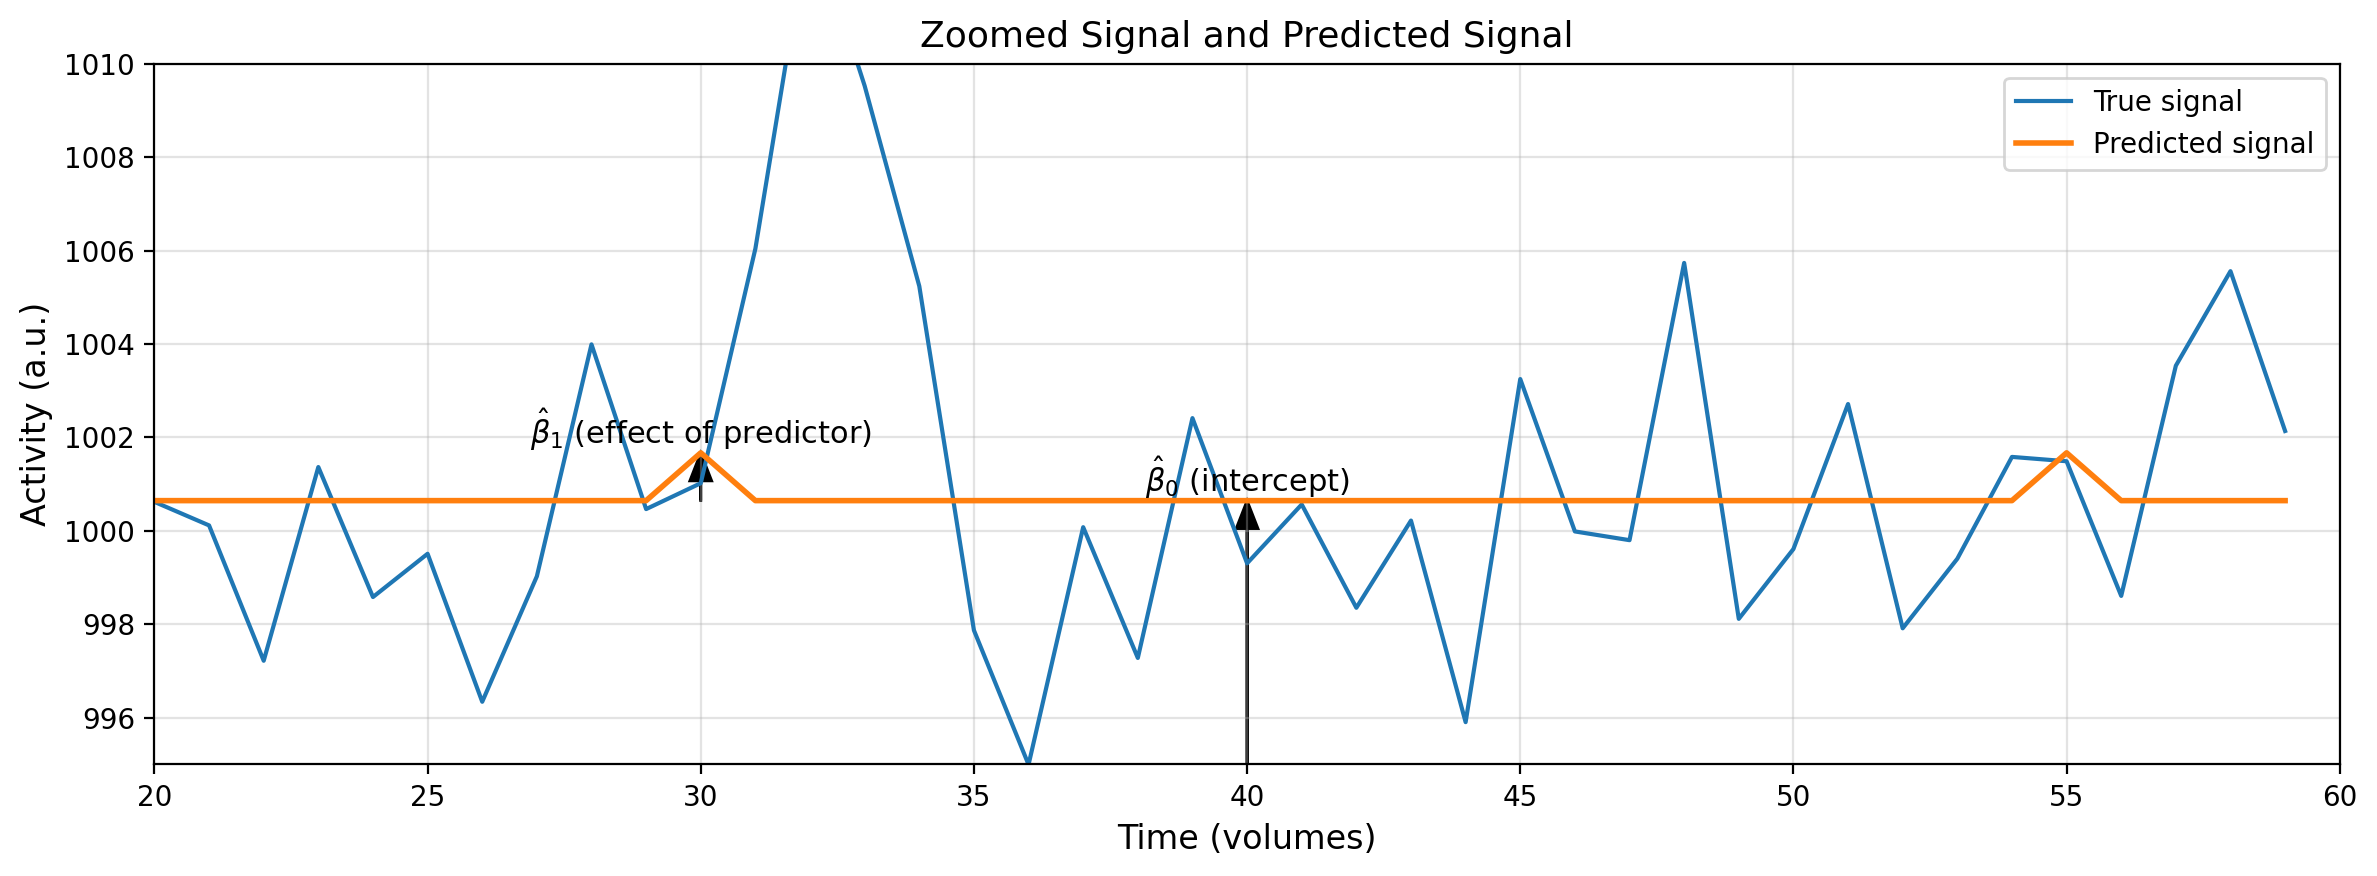

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def plot_signal_and_predicted_signal_zoom(y, X, x_lim, y_lim, plot_params=True):
    """
    Plot a zoomed window of the voxel signal and its predicted signal from a simple GLM.

    Parameters
    ----------
    y : array-like, shape (N,) or (N, 1)
        Voxel time series (dependent variable).
    X : array-like, shape (N,) or (N, 1)
        Predictor at the same sampling rate as y (without intercept).
        For binary event predictors, peaks in ŷ align with X == 1.
    x_lim : tuple(int, int)
        X-axis (time/volumes) limits for the zoomed window, inclusive start, exclusive end.
    y_lim : tuple(float, float)
        Y-axis limits for plotting.
    plot_params : bool, default=True
        If True, draw arrows/labels indicating β₀ (intercept) and β₁ (slope).

    Notes
    -----
    - Uses np.linalg.lstsq for numerical stability instead of explicit (XᵀX)⁻¹ Xᵀy.
    - Handles 1D inputs by reshaping to column vectors.
    """

    # Ensure column-vector shapes
    y = np.asarray(y).reshape(-1, 1)
    X = np.asarray(X).reshape(-1, 1)

    # Design matrix with intercept
    des = np.hstack((np.ones((y.shape[0], 1)), X))

    # OLS via least-squares (more stable than explicit inverse)
    betas_simple, *_ = np.linalg.lstsq(des, y, rcond=None)   # shape (2, 1)
    yhat = des @ betas_simple                                # shape (N, 1)

    # Prepare plotting window (coerce indices to int and clip to valid range)
    N = y.shape[0]
    x0 = int(max(0, min(x_lim[0], N - 1)))
    x1 = int(max(0, min(x_lim[1], N)))  # allow x1 == N
    idx = np.arange(x0, x1)

    plt.figure(figsize=(12, 4.5))
    plt.plot(idx, y[idx], label="True signal")
    plt.plot(idx, yhat[idx], linewidth=2, label="Predicted signal")

    plt.xlim(x0, x1)
    plt.ylim(y_lim)
    plt.xlabel("Time (volumes)", fontsize=12)
    plt.ylabel("Activity (a.u.)", fontsize=12)
    plt.title("Zoomed Signal and Predicted Signal", fontsize=13)

    if plot_params:
        β0 = float(betas_simple[0, 0])
        β1 = float(betas_simple[1, 0])

        # Place an arrow for the intercept at the middle of the window
        x_mid = int((x0 + x1) / 2)
        # Draw baseline (β0) as an arrow from bottom y-limit up to β0
        plt.arrow(
            x_mid, y_lim[0], 0, β0 - y_lim[0],
            head_width=max(0.3, (x1 - x0) * 0.01),
            length_includes_head=True, color="k"
        )
        plt.text(
            x_mid, β0, r"$\hat{\beta}_0$ (intercept)",
            fontsize=11, ha="center", va="bottom"
        )

        # If the predictor is (mostly) binary, pick a time in the window where X == 1
        # Otherwise, use the time with the largest predicted value in-window.
        X_win = X[idx].ravel()
        yhat_win = yhat[idx].ravel()

        if np.any(X_win > 0.5):  # heuristic for binary (1s) events
            t_event = idx[np.where(X_win > 0.5)[0][0]]  # first event in window
        else:
            t_event = idx[np.argmax(yhat_win)]

        # Arrow showing β1 (effect size) from baseline up to baseline + β1 at t_event
        plt.arrow(
            t_event, β0, 0, β1,
            head_width=max(0.3, (x1 - x0) * 0.01),
            length_includes_head=True, color="k"
        )
        plt.text(
            t_event, β0 + β1,
            r"$\hat{\beta}_1$ (effect of predictor)",
            fontsize=11, ha="center", va="bottom"
        )

    plt.legend(loc="upper right")
    plt.grid(alpha=0.35)
    plt.tight_layout()
    plt.show()
    
plot_signal_and_predicted_signal_zoom(voxel_signal, predictor_all_ds, x_lim=(20, 60), y_lim=(995, 1010), plot_params=True)

The **orange line** shows the **predicted signal**.  
It is generated by taking the original predictor ($\textcolor{orange}{X}$) and multiplying it by the estimated parameters ($\beta$).  

- The **stimulus parameter** ($\beta_{\text{stim}}$) can be interpreted as the **height of the peaks** in the predicted signal.  
- The **intercept parameter** ($\beta_{0}$) represents the **baseline offset** of the signal — the value around which the predictor’s effect is added.  

---

\* This interpretation holds when the maximum value of the predictor is **1** (as in our case).  

👉 **Check your understanding: From β to percent signal change**

You estimated:
- Intercept (baseline) $\hat{\beta}_0 \approx 1000.657$ (a.u.)
- Stimulus effect $\hat{\beta}_{\text{stim}} \approx 1.023$ (a.u.), with $X \in \{0,1\}$

What is the **percent signal change** in the voxel when the stimulus is present (i.e., for a unit increase in $X$: $0 \rightarrow 1$)?

---

<details>
<summary>✅ Click to reveal solution</summary>

**Step 1 — Interpret β:**  
With $X \in \{0,1\}$, $\hat{\beta}_{\text{stim}} = 1.023$ means the signal increases by **1.023 units** when the stimulus is present.

**Step 2 — Identify baseline:**  
The intercept is the baseline signal when $X=0$: $\hat{\beta}_0 \approx 1000.657$ (arbitrary units).

**Step 3 — Compute percent signal change (PSC):**  
$\text{PSC} = \frac{\text{effect size}}{\text{baseline}} \times 100\%
= \frac{1.023}{1000.657} \times 100\%
\approx 0.102\% \approx 0.10\%$


**Note:** PSC depends on how $X$ is coded (here 0/1) and on the baseline scaling (arbitrary units), which is why PSC is often reported instead of raw β.
</details>

So, it looks like there **is** an effect of the stimulus on voxel activity:  
on average, the signal increases by **1.023 units** (≈ **0.1% signal change**).  

But… the **model fit is very poor**:  
$R^2 = 0.004$ → only about **0.4% of the variance** in the signal is explained.  

---

🤔 What’s going on here?  
- Is the voxel just **very noisy**?  
- Or could there be something **wrong with our model**?  

We’ll dig into this question in the next section!

### Incorporating the BOLD Response into GLM Models  

Let’s revisit the assumption we made when creating our predictor.  
We treated each stimulus onset as if it caused an **instantaneous change** in voxel activity.  

But given what we know about the **BOLD response**, this assumption is unrealistic:  

- The BOLD signal is **sluggish** compared to neuronal activity.  
- It typically peaks around **5–7 seconds after** the underlying neural event.  
- This means we cannot capture rapid, moment-to-moment neural changes directly with fMRI.  

---

In our earlier model, we ignored both the **lag** (~6 seconds) and the **shape** of the BOLD response.  
We essentially told the model: “signal jumps up immediately at stimulus onset” — which does not reflect physiology.  

If we instead incorporate what we know about the BOLD response into our predictors,  
our model should provide a **much better fit** to the measured signal.  

In this section, we’ll explore how to do exactly that.  



#### The Canonical HRF  

The simplest and most widely used way to incorporate the BOLD response in fMRI analysis is to assume that each voxel responds to a stimulus in a **fixed, stereotypical way**.  
This fixed response pattern is called the **canonical haemodynamic response function (HRF)**.  

In other words:  
- We assume that all voxels respond to a stimulus with the **same shape of BOLD response**.  
- The same HRF is applied across **voxels, participants, and conditions**.  

---

An HRF is essentially a mathematical **model of how we think a voxel responds to a stimulus**.  
- A *canonical HRF* uses the same predefined shape everywhere.  
- Other approaches allow more flexibility by adjusting the HRF shape to the data, e.g.:  
  - **Temporal basis sets**  
  - **Finite impulse response (FIR) models**  
(We’ll return to these later in the course.)  

---

There are different types of canonical HRFs, each giving a slightly different assumed shape.  
In this course, we’ll use the most common choice: the **double-gamma HRF**, which combines two gamma functions:  
- One models the **initial overshoot** of the BOLD signal.  
- The other models the **post-stimulus undershoot**.  

We’ll use the implementation provided by the [nilearn](https://nilearn.github.io) Python package.  
Specifically, the **“Glover HRF”** (`glover_hrf`), a double-gamma function variant widely used in fMRI analysis.

In [44]:
from nilearn.glm.first_level.hemodynamic_models import glover_hrf

/usr/local/lib/python3.10/dist-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


The HRF function takes several arguments, the most important being:  
- **TR** (time to repetition, in seconds)  
- **Oversampling factor** (to generate the HRF at a finer temporal resolution)  
- **Length of the HRF** (in seconds)  

The function returns a **double-gamma HRF**.  

---

⚠️ It’s crucial to ensure that your HRF is defined on the **same timescale** as your design (predictors).  
In the previous section, we first defined predictors at the **second-by-second scale** and only then downsampled them to the acquisition timescale (TR = 2s).  

Given a TR of 2, we can set the **oversampling factor** to 2.  
This way, the HRF is initially defined on a **1-second grid**, making it compatible with our predictors before any downsampling.

In [45]:
# Define HRF parameters
TR = 2                 # Repetition time (seconds)
oversampling = 2       # Oversampling factor (HRF sampled at TR/oversampling resolution)
hrf_length = 32        # Duration of HRF (seconds)

# Generate canonical HRF (double-gamma, Glover version)
canonical_hrf = glover_hrf(tr=TR, oversampling=oversampling, time_length=hrf_length, onset=0)

# Normalise HRF (scale to a maximum of 1 for interpretability)
canonical_hrf /= canonical_hrf.max()

# Display array size
print(f"Canonical HRF generated with {canonical_hrf.size} time points")

Canonical HRF generated with 32 time points


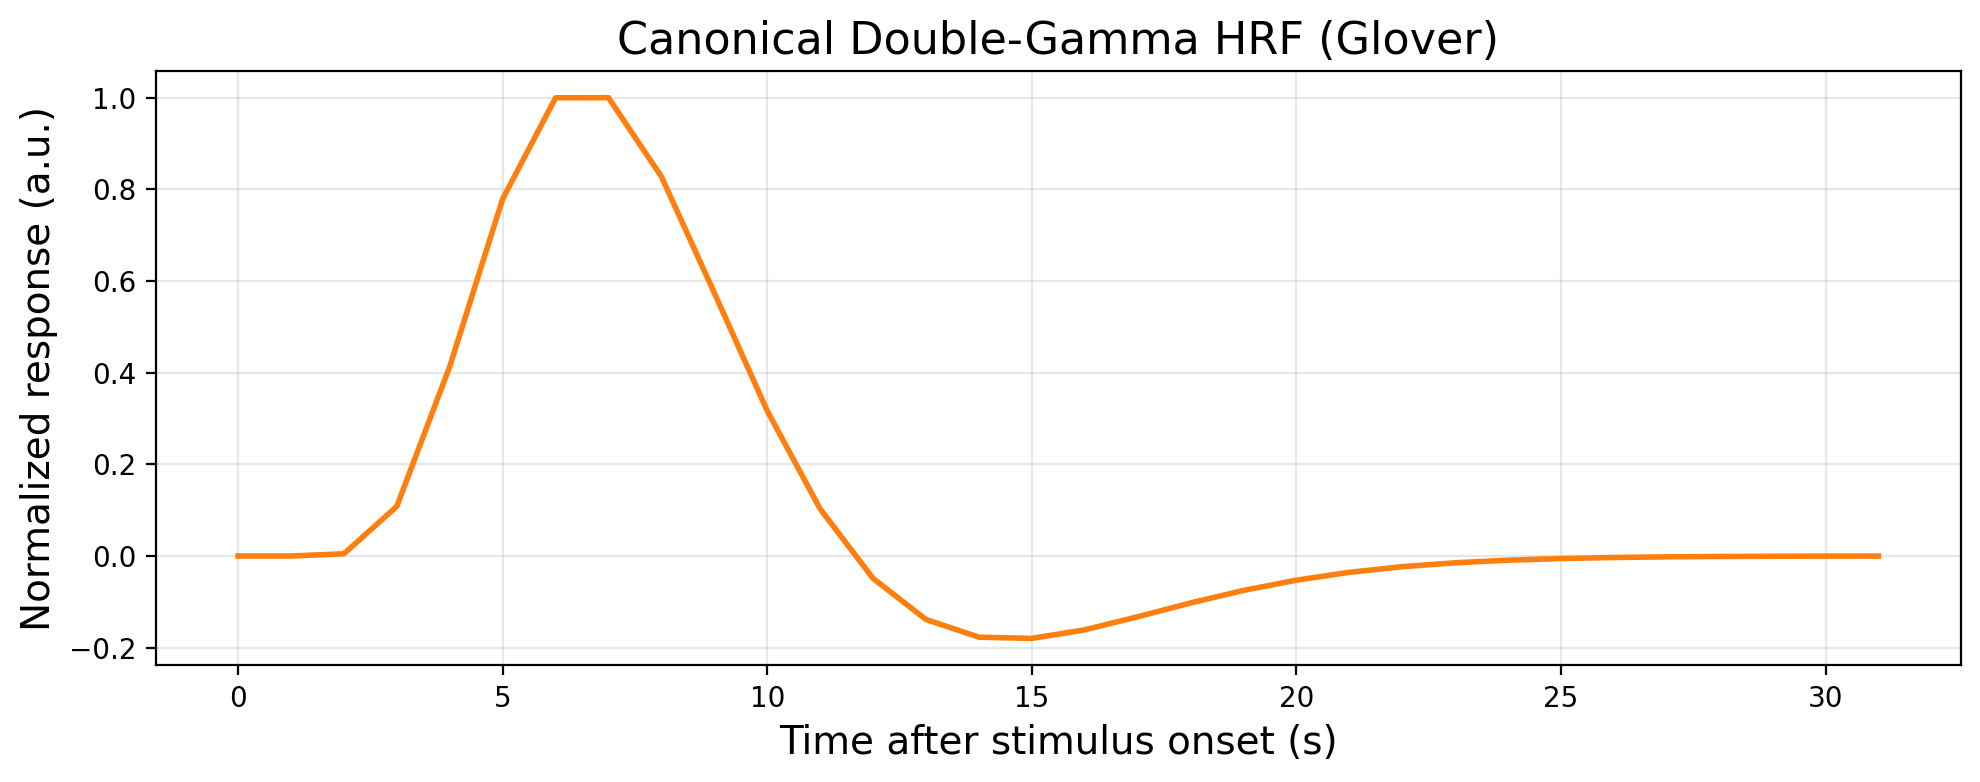

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis in seconds (accounting for oversampling)
t = np.arange(canonical_hrf.size) * (TR / oversampling)

plt.figure(figsize=(10, 4))
plt.plot(t, canonical_hrf, color="tab:orange", linewidth=2)

# Labels and title
plt.xlabel("Time after stimulus onset (s)", fontsize=14)
plt.ylabel("Normalized response (a.u.)", fontsize=14)
plt.title("Canonical Double-Gamma HRF (Glover)", fontsize=16)

# Style
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Convolution  

The HRF we just plotted shows the **idealised BOLD response to a single event**.  
But how do we use this in our model when we have *many* events?  

The standard approach is to apply a mathematical operation called **convolution**.  
Intuitively, convolution means:  
- We **“slide” the HRF across the time axis** of the experiment.  
- At each point where a stimulus occurs (1 in the stimulus vector), we “drop” a copy of the HRF.  
- These responses are then **summed together** to form the final predictor.  

Formally, convolution is written as:  

$X_{\mathrm{conv}} = \mathrm{HRF} * X_{\mathrm{original}}$

where:  
- $*$ denotes the convolution operator  
- $X_{\mathrm{original}}$ is the binary stimulus vector (0 = no stimulus, 1 = stimulus)  
- $X_{\mathrm{conv}}$ is the convolved predictor that models the expected BOLD response  

---

👉 Let’s look at an example.  
Suppose we have an onset vector of length 100 (i.e., an experiment lasting 100 seconds)  
with three stimulus presentations at $t = 10$, $t = 40$, and $t = 70$.  

- **Top plot:** stimulus vector (onset times coded as 1)  
- **Right plot:** canonical double-gamma HRF  
- **Bottom plot:** result of convolving the stimulus vector with the HRF  

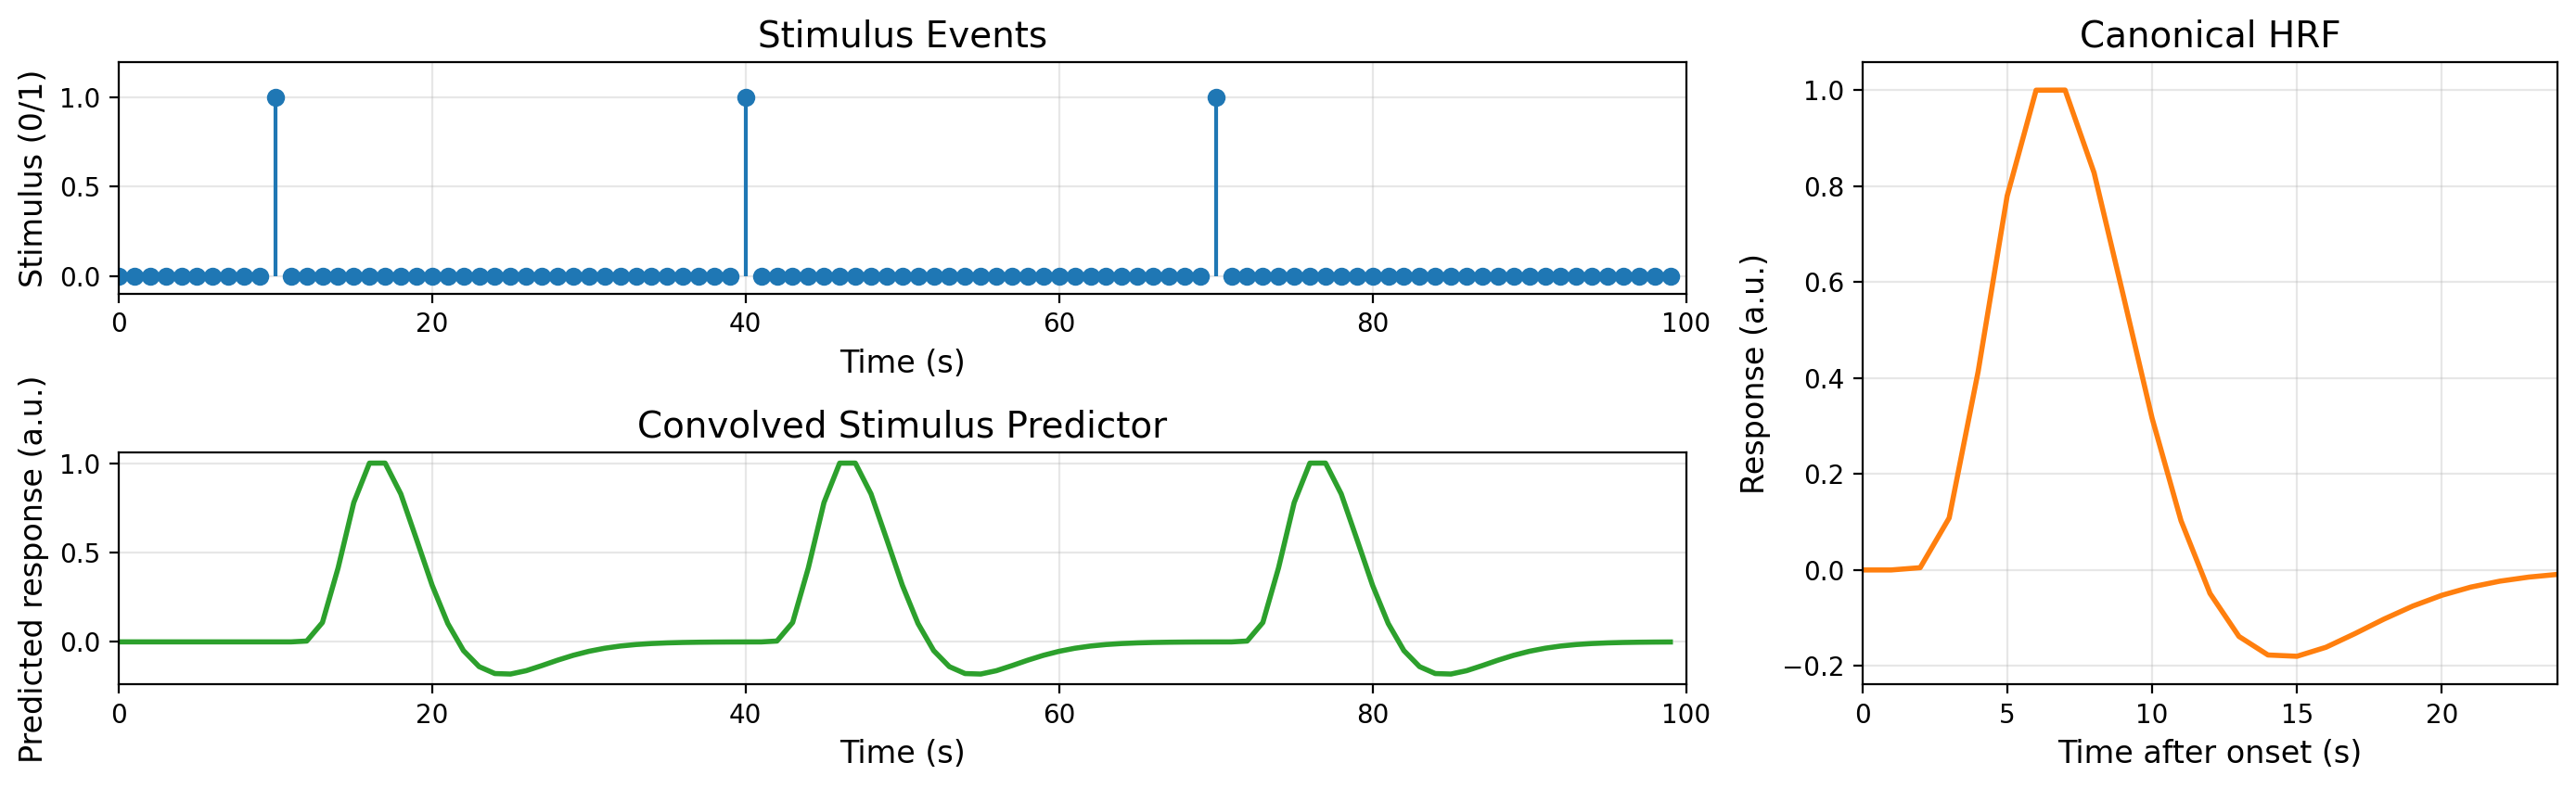

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Define stimulus onsets and vector
random_stimulus_onsets = [10, 40, 70]
random_stim_vector = np.zeros(100)
random_stim_vector[random_stimulus_onsets] = 1

# Convolve stimulus vector with canonical HRF
convolved_stim_vector = np.convolve(random_stim_vector, canonical_hrf, mode="full")

# Create figure with subplots
fig = plt.figure(figsize=(14, 6))

# --- Stimulus events ---
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
ax1.stem(range(100), random_stim_vector, basefmt=" ")
ax1.set_xlim(0, 100)
ax1.set_ylim(-0.1, 1.2)
ax1.set_ylabel("Stimulus (0/1)", fontsize=12)
ax1.set_xlabel("Time (s)", fontsize=12)
ax1.set_title("Stimulus Events", fontsize=14)
ax1.grid(alpha=0.3)

# --- HRF ---
ax2 = plt.subplot2grid((3, 3), (0, 2), rowspan=2)
time_hrf = np.arange(canonical_hrf.size) * (TR / oversampling)
ax2.plot(time_hrf, canonical_hrf, color="tab:orange", lw=2)
ax2.set_xlim(0, 24)
ax2.set_xlabel("Time after onset (s)", fontsize=12)
ax2.set_ylabel("Response (a.u.)", fontsize=12)
ax2.set_title("Canonical HRF", fontsize=14)
ax2.grid(alpha=0.3)

# --- Convolved predictor ---
ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
ax3.plot(convolved_stim_vector[:100], color="tab:green", lw=2)
ax3.set_xlim(0, 100)
ax3.set_xlabel("Time (s)", fontsize=12)
ax3.set_ylabel("Predicted response (a.u.)", fontsize=12)
ax3.set_title("Convolved Stimulus Predictor", fontsize=14)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The result — the **convolved stimulus vector** — is what you get when you
“slide” the HRF across the stimulus events and sum the overlapping responses.
As you can see, the convolved predictor now **captures the expected BOLD lag
and shape**. Because it encodes what physiology predicts should happen,
it will typically model voxel activity **much better** than the raw 0/1 onset
vector.

---

⚠️ **Note on resolution:**  
The temporal resolution of your convolved regressor is ultimately limited by
your data (the TR). That’s why, once we resample it to the TR grid, it won’t
look as smooth as the finely sampled HRF.

So why do we convolve the **onset-level predictor** (`predictor_all`, in seconds) 
instead of the **downsampled predictor** (`predictor_all_ds`, in TR units)?  

- Convolution assumes a **continuous-time representation** of the events.  
- If we downsample first, we lose sub-TR precision about when events occurred.  
- By convolving in seconds and only then downsampling, we preserve that precision
and get a more accurate predictor.  

This rationale is explained clearly in Jeanette Mumford’s [video on the HRF](https://www.youtube.com/watch?v=5JNX34gYG7Q).

---

NumPy provides a convenient function for convolution:

```python
np.convolve(array_1, array_2)
```

We’ll now use it to convolve our canonical HRF with `predictor_all`
(onset resolution in seconds).

In [48]:
# Convolution expects 1D arrays of shape (N,), not (N, 1).
# We therefore "squeeze" the predictor to remove the singleton axis.
predictor_conv = np.convolve(predictor_all.squeeze(), canonical_hrf)

print(f"Shape after convolution: {predictor_conv.shape}")

# After convolution, the output is longer than the original predictor
# (this is a property of convolution). We trim it back to the original length.
predictor_conv = predictor_conv[:predictor_all.size]
print(f"Shape after trimming: {predictor_conv.shape}")

# Finally, we add back a singleton axis so that the predictor has shape (N, 1).
# This is important later when stacking predictors with the intercept.
predictor_conv = predictor_conv[:, np.newaxis]
print(f"Shape after adding axis back: {predictor_conv.shape}")

Shape after convolution: (831,)
Shape after trimming: (800,)
Shape after adding axis back: (800, 1)


It takes a few extra steps — squeezing out the singleton axis, trimming the
excess values, and adding the axis back — but now we’ve created a predictor
that **incorporates the expected shape of the HRF**.  

Let’s compare the predictor **before convolution** (raw onsets) and **after
convolution** (with the HRF) in the same plot:

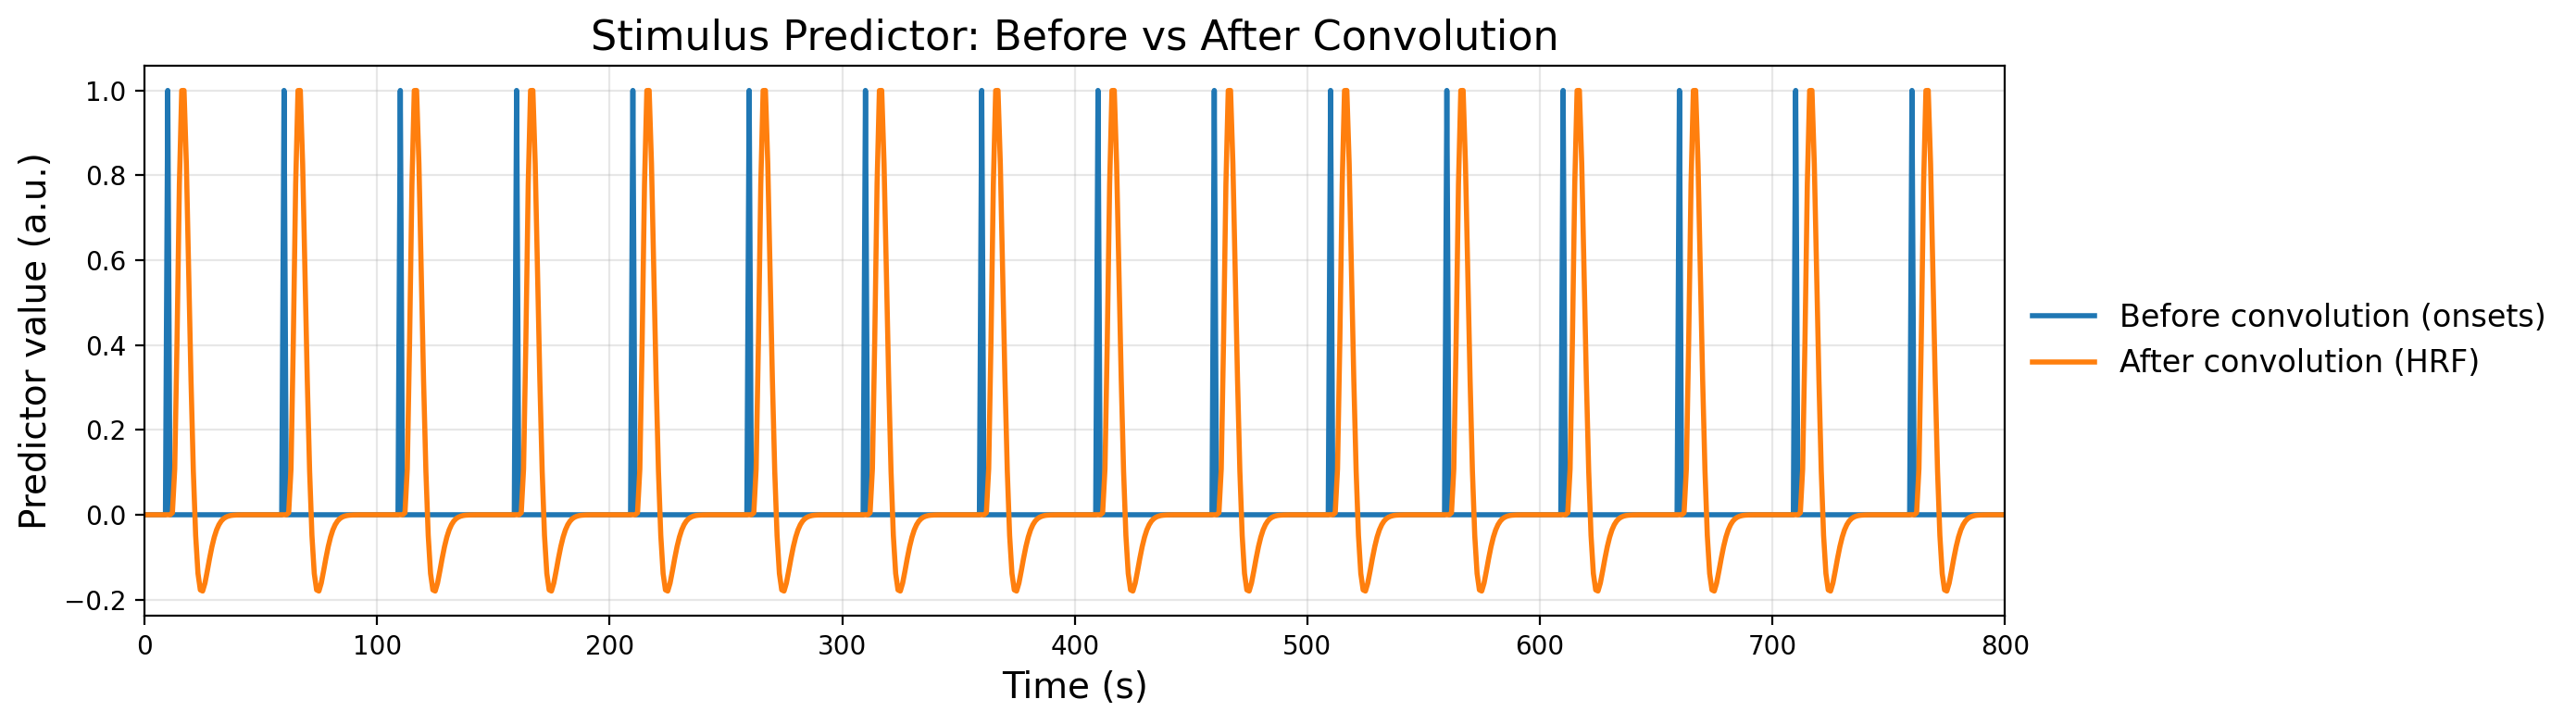

In [49]:
plt.figure(figsize=(14, 4))

# Plot predictors before and after convolution
plt.plot(predictor_all, label="Before convolution (onsets)", color="tab:blue", lw=2)
plt.plot(predictor_conv, label="After convolution (HRF)", color="tab:orange", lw=2)

# Axis settings
plt.xlim(0, 800)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Predictor value (a.u.)", fontsize=14)
plt.title("Stimulus Predictor: Before vs After Convolution", fontsize=16)

# Legend outside plot
plt.legend(fontsize=12, frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Linear Scaling  

Great! Our predictor now incorporates both the **lag** and **shape** of the HRF, so we’re ready to analyse the signal with this improved regressor.  

But before we do, let’s revisit one more key property of the BOLD response: **linear scaling**.  
This principle states that the amplitude of the BOLD response **scales linearly with the strength or duration of the input**.  

Let’s demonstrate this in action:

Text(0.5, 0, 'Time (TR)')

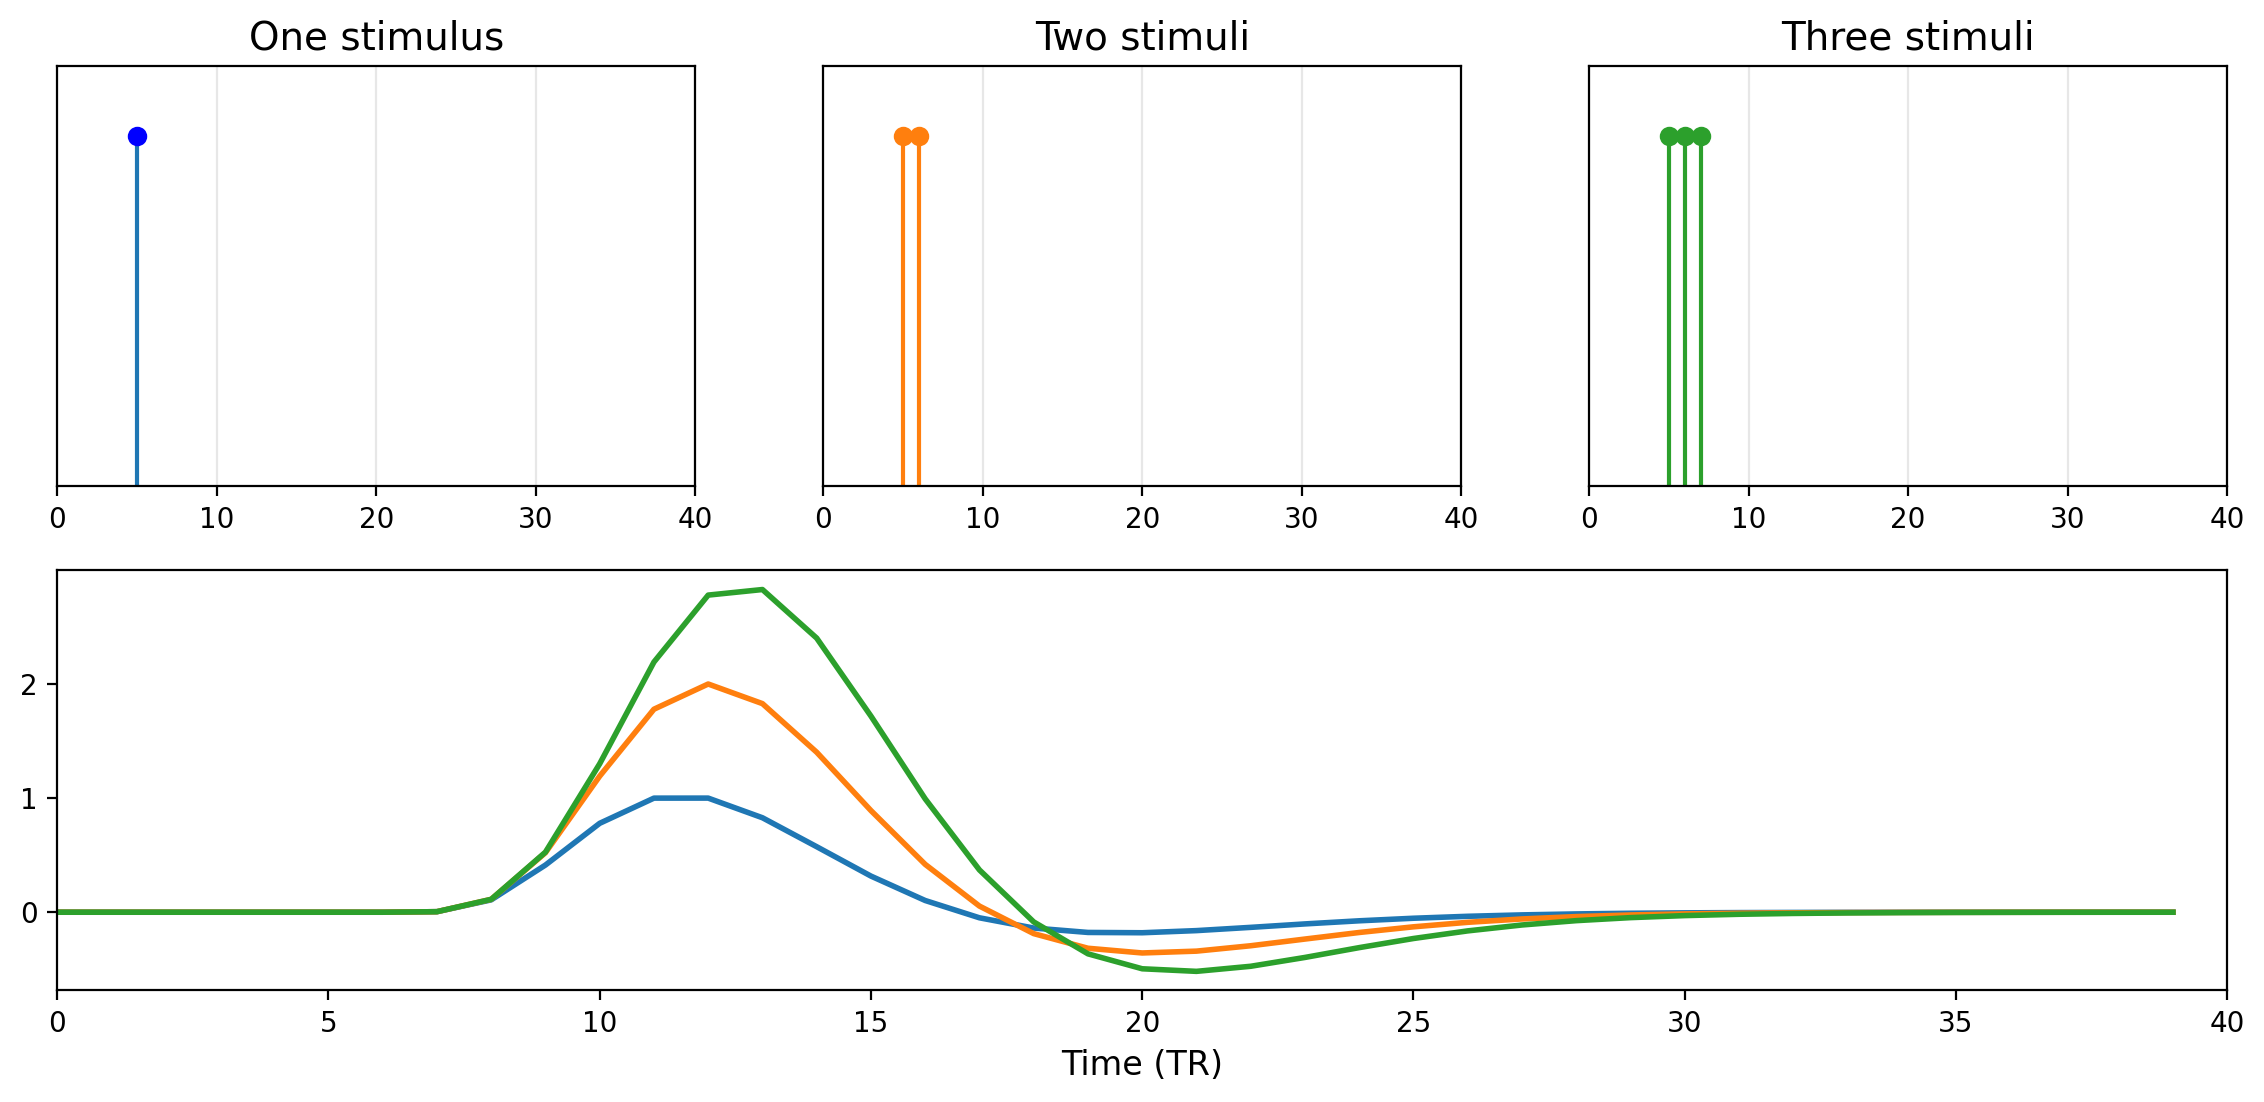

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Number of time points
N = 40  

# Define stimulus vectors
one_stim = np.zeros(N);   one_stim[5] = 1
two_stim = np.zeros(N);   two_stim[[5, 6]] = 1
three_stim = np.zeros(N); three_stim[[5, 6, 7]] = 1

# Convolve with canonical HRF and trim to length N
one_stim_conv   = np.convolve(one_stim, canonical_hrf)[:N]
two_stim_conv   = np.convolve(two_stim, canonical_hrf)[:N]
three_stim_conv = np.convolve(three_stim, canonical_hrf)[:N]

# --- Plot stimulus events ---
fig = plt.figure(figsize=(14, 6))

# One stimulus
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax1.stem(
    np.where(one_stim)[0],
    np.ones(int(np.sum(one_stim))),    # ensure integer count
    linefmt="tab:blue",
    markerfmt="bo",
    basefmt=" "
)
ax1.set_xlim(0, N)
ax1.set_ylim(0, 1.2)
ax1.set_title("One stimulus", fontsize=14)
ax1.set_yticks([])
ax1.grid(alpha=0.3)

# Two stimuli
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax2.stem(np.where(two_stim)[0], np.ones(int(np.sum(two_stim))), 
         linefmt="tab:orange", markerfmt="o", basefmt=" ")
ax2.set_xlim(0, N)
ax2.set_ylim(0, 1.2)
ax2.set_title("Two stimuli", fontsize=14)
ax2.set_yticks([])
ax2.grid(alpha=0.3)

# Three stimuli
ax3 = plt.subplot2grid((2, 3), (0, 2))
ax3.stem(np.where(three_stim)[0], np.ones(int(np.sum(three_stim))), 
         linefmt="tab:green", markerfmt="o", basefmt=" ")
ax3.set_xlim(0, N)
ax3.set_ylim(0, 1.2)
ax3.set_title("Three stimuli", fontsize=14)
ax3.set_yticks([])
ax3.grid(alpha=0.3)

# --- Plot convolved responses ---
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=3)
ax4.plot(one_stim_conv,   color="tab:blue",   lw=2, label="One stimulus")
ax4.plot(two_stim_conv,   color="tab:orange", lw=2, label="Two stimuli")
ax4.plot(three_stim_conv, color="tab:green",  lw=2, label="Three stimuli")

ax4.set_xlim(0, N)
ax4.set_xlabel("Time (TR)", fontsize=12)

So far, in both our random stimulus vector and the earlier examples, we assumed
that each image was presented only **briefly** — in other words, we only
modelled the **onset** of each event.  

But what if a stimulus (or task) lasts longer, say **15 seconds** instead of a
single impulse?  
Let’s explore how that changes the predictor and its convolution with the HRF.

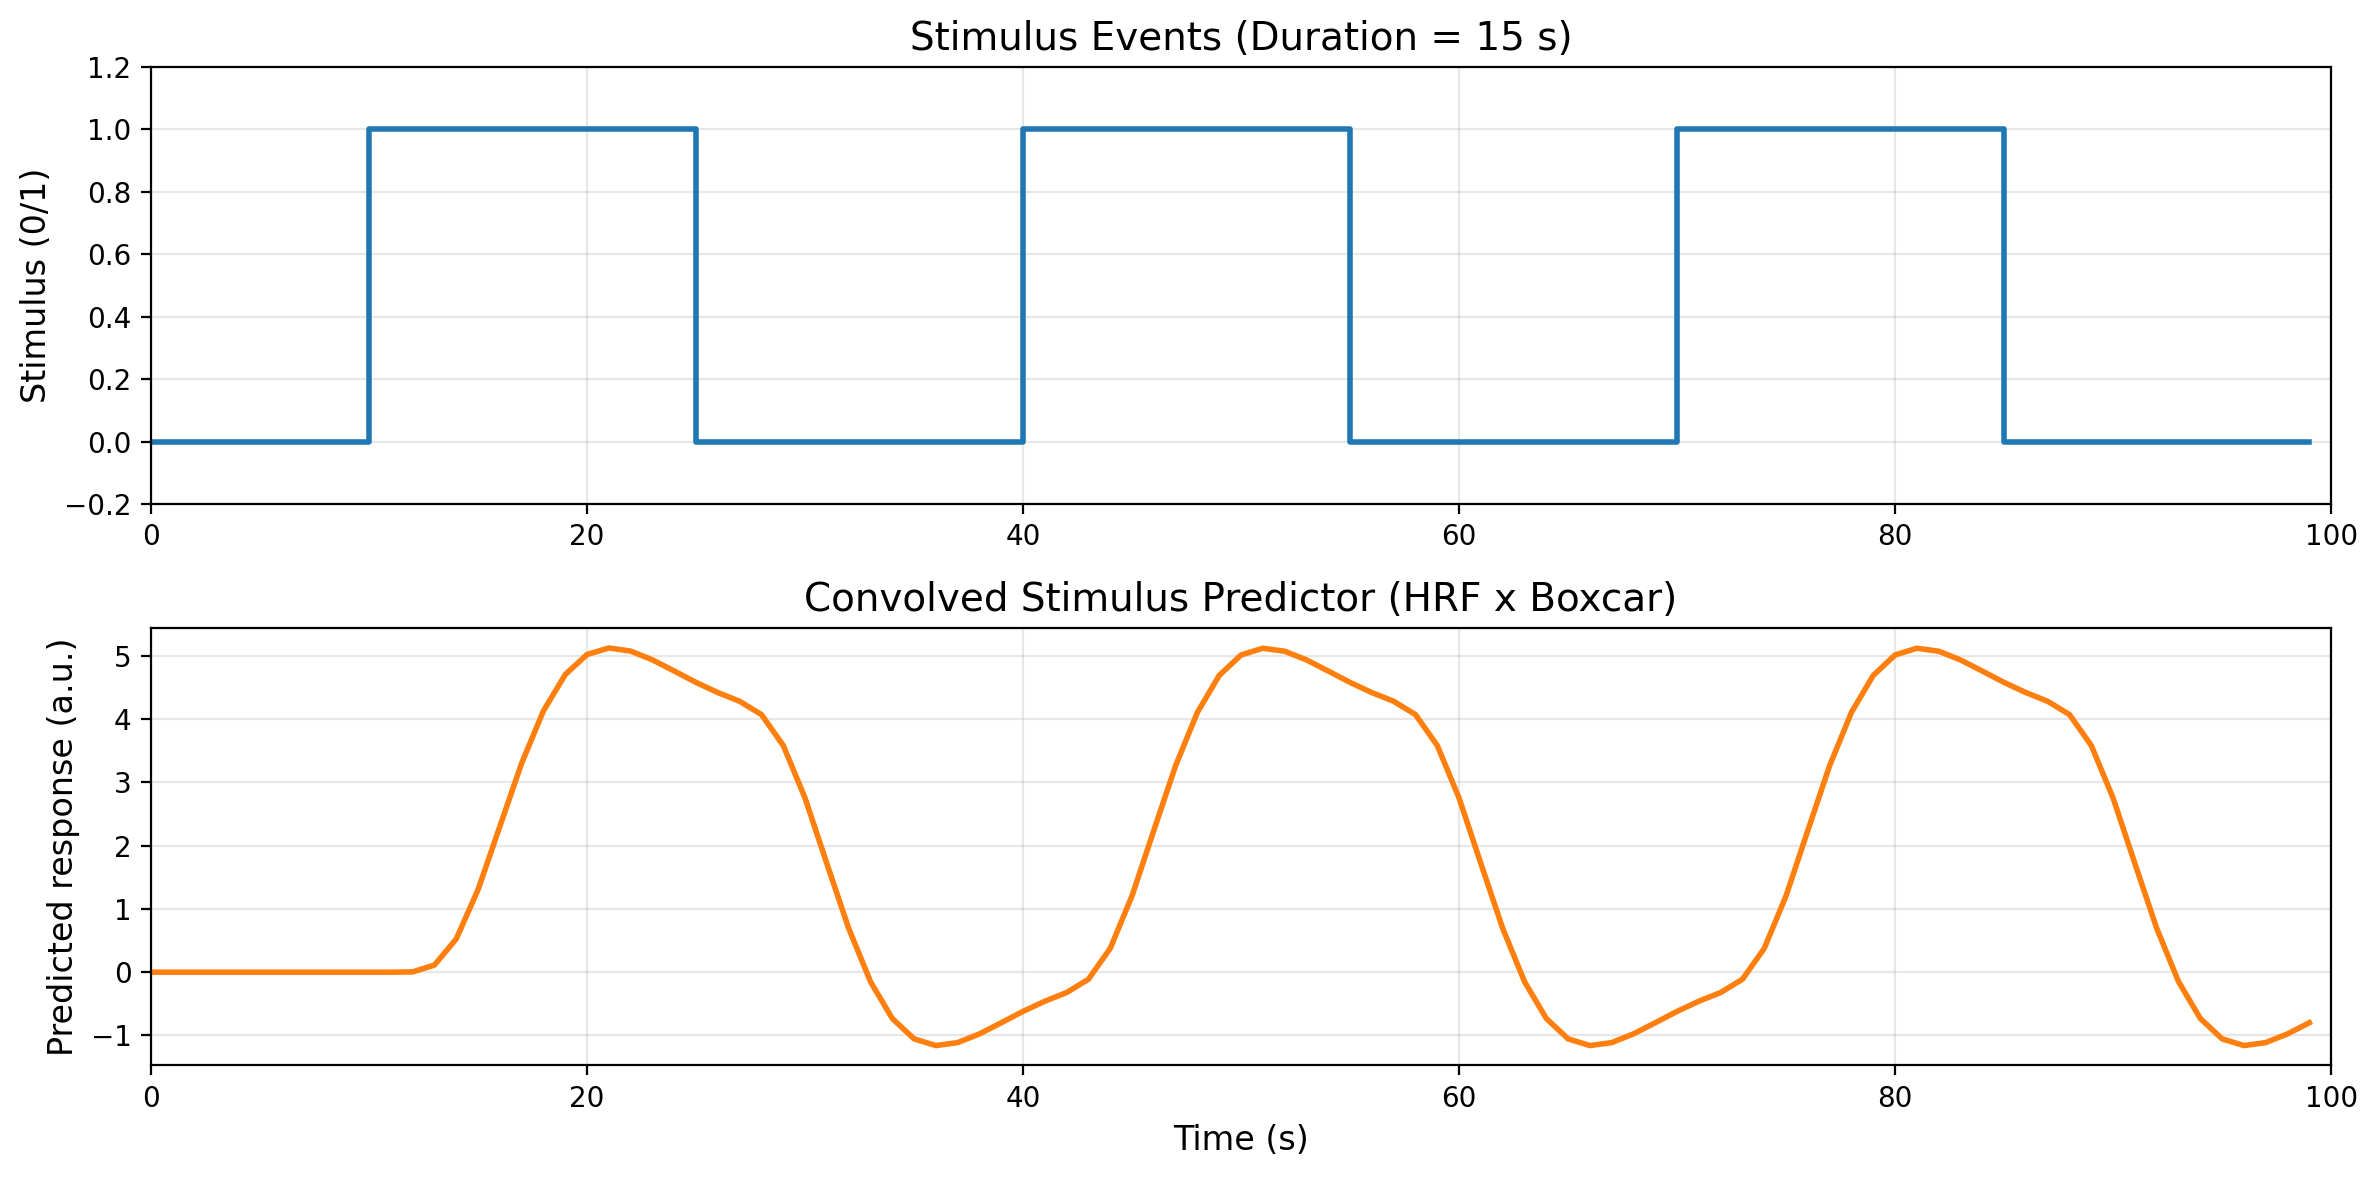

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Define 15 s blocks: 10–24, 40–54, 70–84 (inclusive start, exclusive end via range)
random_stimulus_onsets2 = list(range(10, 25)) + list(range(40, 55)) + list(range(70, 85))
random_stim_vector2 = np.zeros(100, dtype=int)
random_stim_vector2[random_stimulus_onsets2] = 1

# Time axis in seconds
t = np.arange(random_stim_vector2.size)

# Convolution with canonical HRF, then trim to original length
convolved_stim_vector2 = np.convolve(random_stim_vector2, canonical_hrf)[:random_stim_vector2.size]

# --- Plot ---
plt.figure(figsize=(12, 6))

# (Top) stimulus boxcar
ax1 = plt.subplot(2, 1, 1)
ax1.plot(t, random_stim_vector2, drawstyle="steps-post", color="tab:blue", linewidth=2)
ax1.set_xlim(0, 100)
ax1.set_ylim(-0.2, 1.2)
ax1.set_ylabel("Stimulus (0/1)", fontsize=12)
ax1.set_title("Stimulus Events (Duration = 15 s)", fontsize=14)
ax1.grid(alpha=0.3)

# (Bottom) convolved predictor
ax2 = plt.subplot(2, 1, 2)
ax2.plot(t, convolved_stim_vector2, color="tab:orange", linewidth=2)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Time (s)", fontsize=12)
ax2.set_ylabel("Predicted response (a.u.)", fontsize=12)
ax2.set_title("Convolved Stimulus Predictor (HRF x Boxcar)", fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

As you can see, convolution naturally adjusts the predicted BOLD response to
reflect the **duration of the stimulus**: longer events produce broader,
sustained responses, while brief events produce shorter peaks.

<div class='alert alert-info'>
<b>ToThink</b> (1 point):  

Suppose we have two scenarios:  

1. Three consecutive stimuli (same condition), each lasting **0.5 seconds**, presented back-to-back with **no gap**.  
2. A single stimulus lasting **1.5 seconds**.  

Given the properties of the BOLD response — and assuming the principle of **linear time invariance (LTI)** holds — would you expect the resulting BOLD responses to be the **same** or **different**?  

👉 Explain your reasoning in the text cell below.
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).

</div>

I think they would be the same. Three consecutive 0.5s stimuli of the same type with an interstimulus interval = 0, and one stimulus of 1.5s have the same time course, so I would expect the BOLD response to be the same. 


In fact, convolution can model **any sequence of stimulus events** — even when
the onsets are random. The example below shows this in action.  

💡 Tip: re-run the cell a few times to generate different random onset patterns
and see how the shape of the convolved predictor changes!

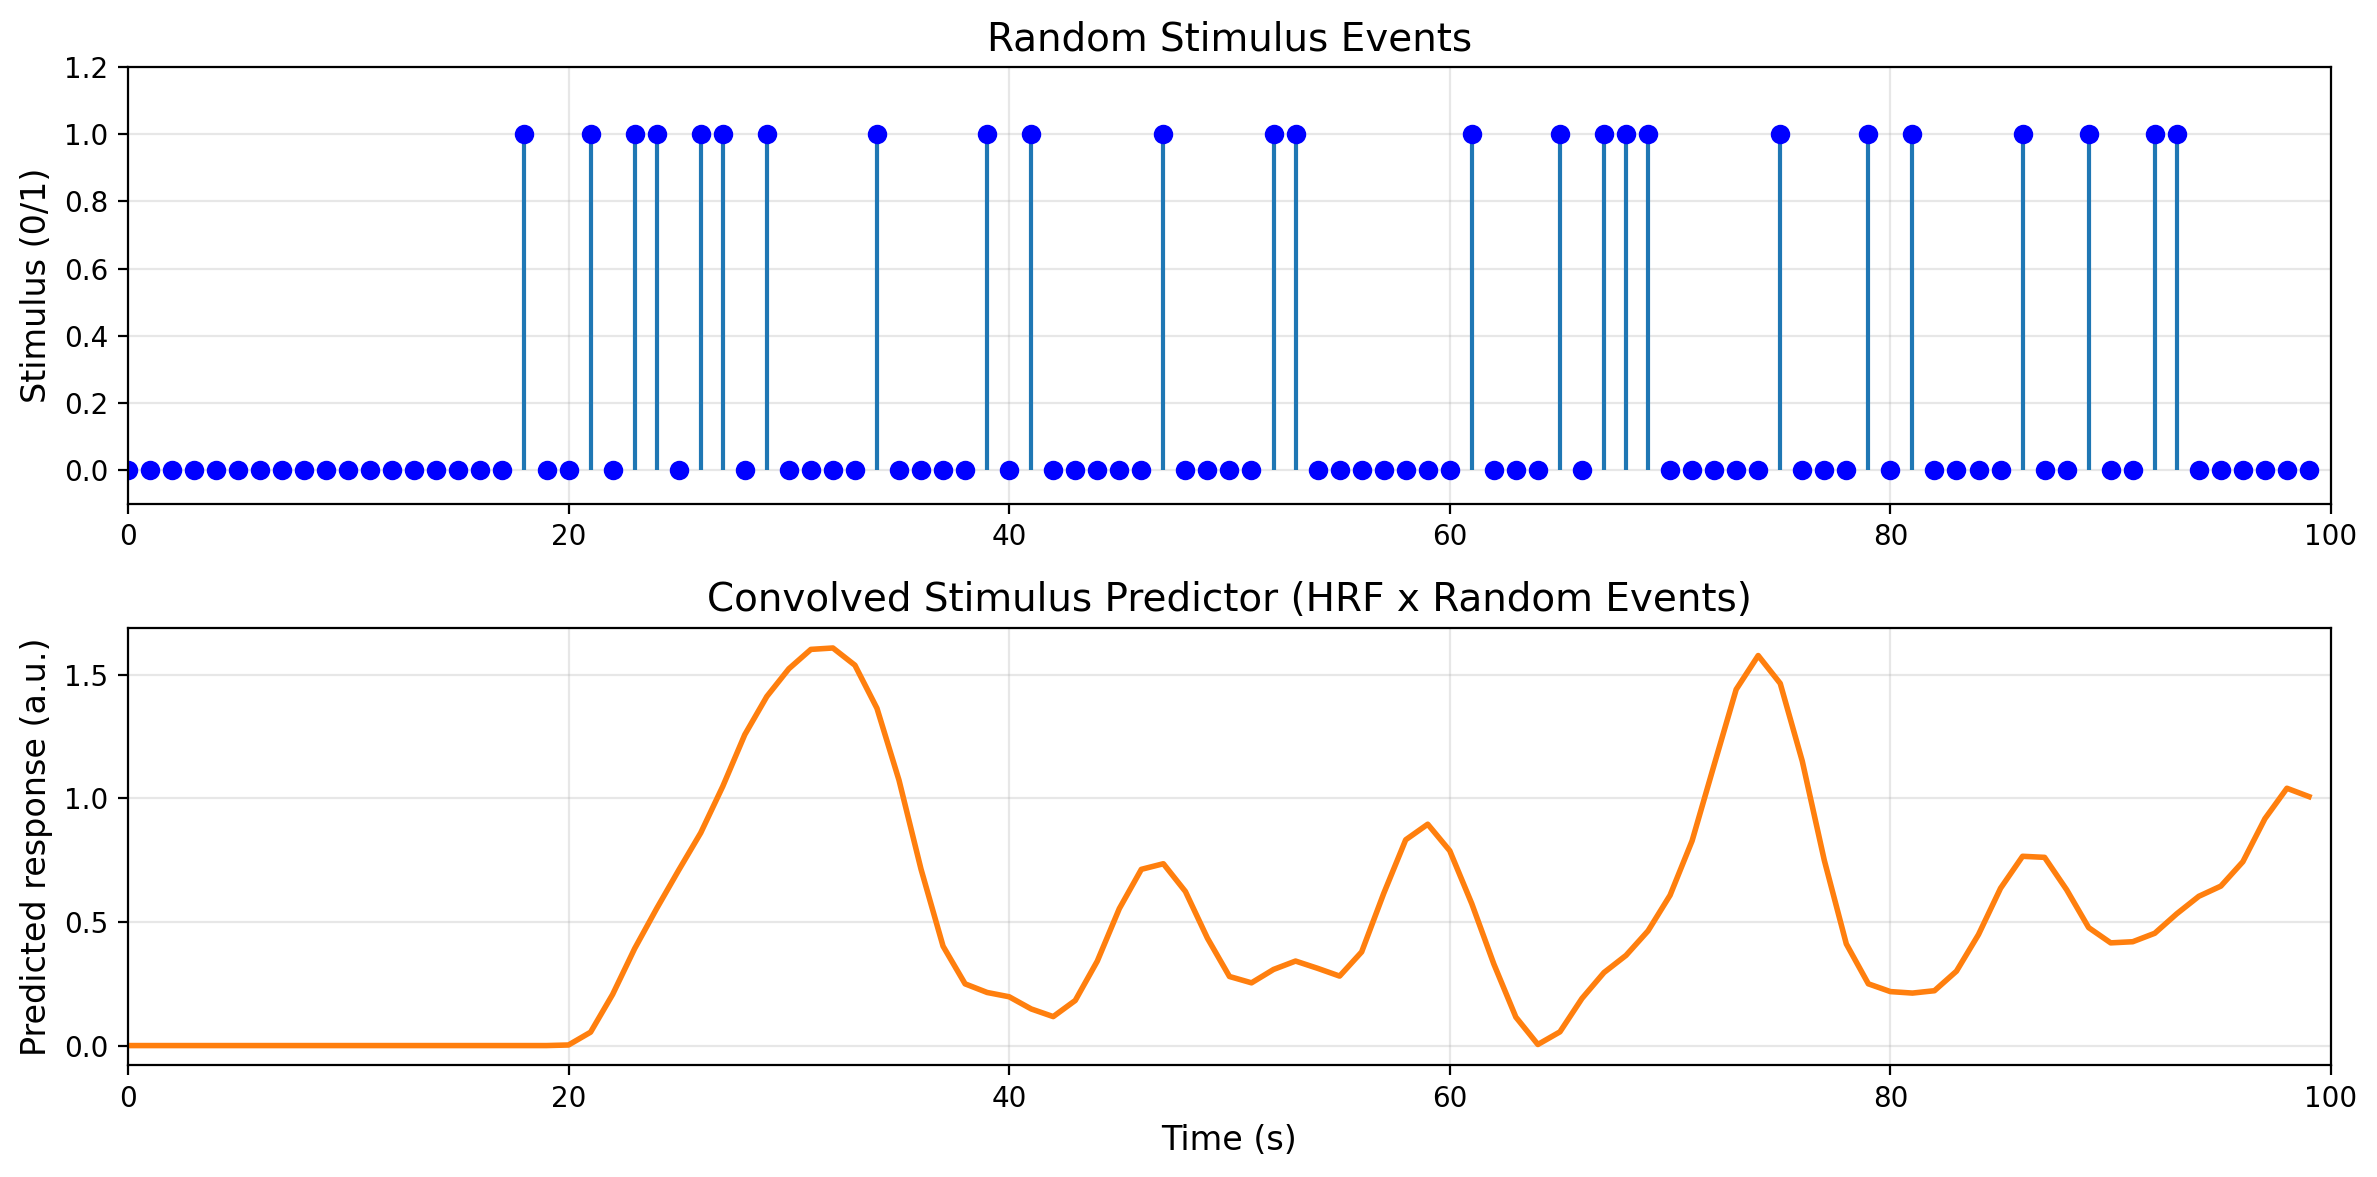

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Random stimulus onsets (unique, without replacement) over 0–99 s
onset_count = 25
rng = np.random.default_rng()  # reproducible if you pass a seed, e.g. default_rng(42)
random_stimulus_onsets3 = np.sort(rng.choice(np.arange(100), size=onset_count, replace=False))

# Build 0/1 stimulus vector
random_stim_vector3 = np.zeros(100, dtype=float)
random_stim_vector3[random_stimulus_onsets3] = 1.0

# Optional: scale event amplitude (e.g., half-strength events)
event_scale = 0.5

# Convolve with HRF and trim to original duration
convolved_stim_vector3 = np.convolve(random_stim_vector3 * event_scale, canonical_hrf)[:random_stim_vector3.size]

# Time axis (seconds)
t = np.arange(random_stim_vector3.size)

# --- Plot ---
plt.figure(figsize=(12, 6))

# (Top) random stimulus events (impulses)
ax1 = plt.subplot(2, 1, 1)
ax1.stem(t, random_stim_vector3, basefmt=" ", linefmt="tab:blue", markerfmt="bo")
ax1.set_xlim(0, 100)
ax1.set_ylim(-0.1, 1.2)
ax1.set_ylabel("Stimulus (0/1)", fontsize=12)
ax1.set_title("Random Stimulus Events", fontsize=14)
ax1.grid(alpha=0.3)

# (Bottom) convolved predictor
ax2 = plt.subplot(2, 1, 2)
ax2.plot(t, convolved_stim_vector3, color="tab:orange", linewidth=2)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Time (s)", fontsize=12)
ax2.set_ylabel("Predicted response (a.u.)", fontsize=12)
ax2.set_title("Convolved Stimulus Predictor (HRF x Random Events)", fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

<b>ToDo</b> (1 point)

You ran an experiment lasting **3 minutes** (180 s).  
A visual stimulus was presented **six times**, each lasting **20 s**, starting at  
$t = 0, 30, 60, 90, 120, 150$ seconds.

👉 Your tasks  
1. Create a **seconds-scale** stimulus predictor (`todo_pred`) of length **180**.  
   - Code the stimulus as 1 during each 20 s block and 0 otherwise.  
2. **Convolve** `todo_pred` with `canonical_hrf`.  
3. **Trim** the convolution output back to length **180** and store as `todo_pred_conv`.

</div>

In [53]:
# --- Implement your solution here ---

# YOUR CODE HERE
import numpy as np
from nilearn.glm.first_level import spm_hrf

stim_onset = list(range(0, 20)) + list(range(30, 50)) + list(range(60, 80)) + list(range(90, 110)) + list(range(120, 40)) + list(range(150, 170))
todo_pred = np.zeros(180)
todo_pred[stim_onset] = 1

todo_pred_conv = np.convolve(todo_pred, canonical_hrf)
todo_pred_conv = todo_pred_conv[:todo_pred.size]
todo_pred_conv = todo_pred_conv[:, np.newaxis]

In [54]:
# Feedback cell
errors = 0
for name, variable, value in zip(['todo_pred', 'todo_pred_conv', 'mse_simple'], [todo_pred, todo_pred_conv], [120.00, 422.95, 103.2739]): 
    if name not in locals():
        print(f'The variable "{name}" is not defined. Check that you created and named the variable correctly.')
        errors += 1
    elif not np.isclose(np.sum(variable), value, rtol=1e-2):
        print('Hmm, something seems off. Please check your answer.')
        errors += 1
        
if errors == 0:
    print('Well done! Your answer passed the automated checks.')
else: 
    print(f'The automated checks found {errors} potential errors in your code.')

Hmm, something seems off. Please check your answer.
Hmm, something seems off. Please check your answer.
The automated checks found 2 potential errors in your code.


So, to summarise: by **convolving the stimulus onsets (and their durations) with
the HRF**, we create a predictor that is much closer to the expected voxel
signal. This works better than the raw onset vector because it:

1. Models the **lag** of the BOLD response.  
2. Captures the **shape** of the BOLD response, consistent with the principle of
   linear scaling.  

---

#### Resampling (revisited)

We’re now *almost* ready to analyse the voxel signal using this convolved
predictor.  
However, there’s still a mismatch: the convolved predictor is defined on the
**seconds scale**, while the voxel signal is sampled on the **TR scale**
(volumes). We need to bring them onto the same grid before we can run the GLM.

In [55]:
print("Size convolved predictor: %i" % predictor_conv.size)
print("Size voxel signal: %i" % voxel_signal.size)

Size convolved predictor: 800
Size voxel signal: 400


To match the predictor with our voxel signal, we need to **resample** the
convolved HRF predictor so that it aligns with the volume onsets (i.e., the TR
grid).  

⚠️ One detail: before resampling, we need to **squeeze out the singleton
dimension** of the predictor. Many functions (including the one we’ll use for
resampling) expect a 1-D array of shape `(N,)`, not `(N, 1)`.  

Once resampled, both the voxel signal and the convolved predictor will be
defined on the **same timescale**, which means we can finally plot and compare
them directly in the same figure.

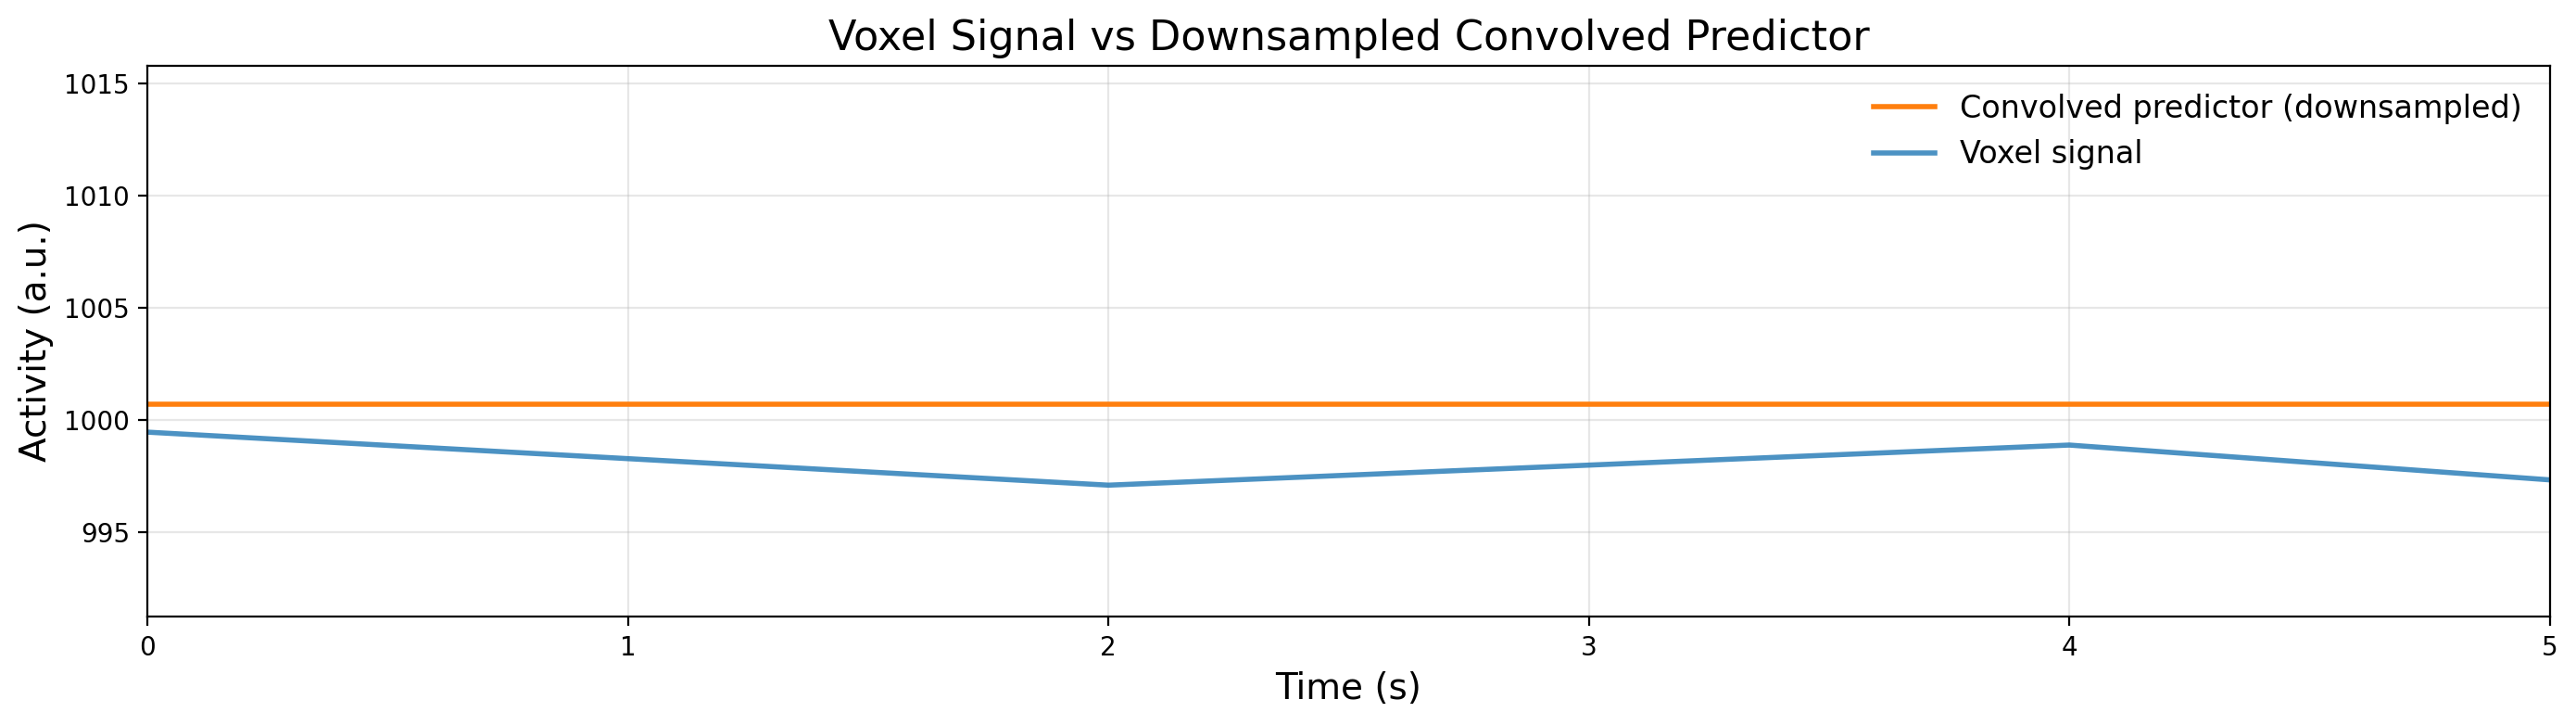

In [56]:
# Define original scale (in seconds) and create resampler
original_scale = np.arange(0, 800)  # seconds
resampler = interp1d(original_scale, predictor_conv.squeeze(), kind="linear")

# Resample to TR grid (every 2 s)
desired_scale = np.arange(0, 800, 2)  # seconds, step = TR
predictor_conv_ds = resampler(desired_scale)

# --- Plot predictor vs. signal ---
plt.figure(figsize=(14, 4))

plt.plot(desired_scale, predictor_conv_ds + voxel_signal.mean(),
         color="tab:orange", lw=2, label="Convolved predictor (downsampled)")
plt.plot(desired_scale, voxel_signal,
         color="tab:blue", lw=2, alpha=0.8, label="Voxel signal")

plt.title("Voxel Signal vs Downsampled Convolved Predictor", fontsize=16)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Activity (a.u.)", fontsize=14)
plt.xlim(x_lim)
plt.legend(frameon=False, fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Initial upsampling of predictors  

In our earlier examples, resampling was straightforward: we simply selected
every other data point (at $t=0, 2, 4, \dots, 798$), because all stimulus
onsets were neatly **locked to whole seconds** (e.g., $t=10$, $t=60$).  

But in many experiments, stimuli are **not locked** to round seconds. For
example, you might have an onset at $t = 10.29$ seconds. How do we handle such
cases when building predictors?  

The common solution is to **define the predictor on a finer timescale first**.  
For example, we can oversample the timeline at **0.01 s resolution** (i.e.,
hundredths of a second). Then, each onset can be placed precisely by converting
its time in seconds to an index in this oversampled array.  
- Example: an onset at $t = 5.12$ seconds would correspond to index $512$.  

After building the predictor at this high resolution, we can later **downsample
it to the TR grid**, just as we did before.  

Let’s try this with some hypothetical onsets logged with **millisecond
precision** in a 50-second experiment:

In [57]:
# Hypothetical stimulus onsets (in seconds, with millisecond precision)
onsets2 = np.array([3.62, 16.26, 34.12, 42.98])  
duration = 50       # total experiment duration in seconds
osf = 100           # oversampling factor (100 → resolution of 0.01 s)

# Create oversampled predictor (length = duration × oversampling factor)
pred2 = np.zeros(duration * osf)
print(f"Size of oversampled predictor (factor {osf}): {pred2.size}")

# Convert onsets (in seconds) into oversampled indices
# Multiplying by `osf` gives centisecond resolution; convert to int for indexing
onset_indices = (onsets2 * osf).astype(int)

# Mark events in predictor
pred2[onset_indices] = 1

Size of oversampled predictor (factor 100): 5000


To convolve this oversampled predictor, we also need to define the HRF on the
**same fine timescale** (hundredths of a second in this case).  

Notice how, when defined on such a fine grid, the HRF itself looks much
**smoother** compared to when it was sampled directly at the TR scale.  
This higher temporal precision allows us to model stimulus onsets more
accurately before eventually downsampling to the TR grid.

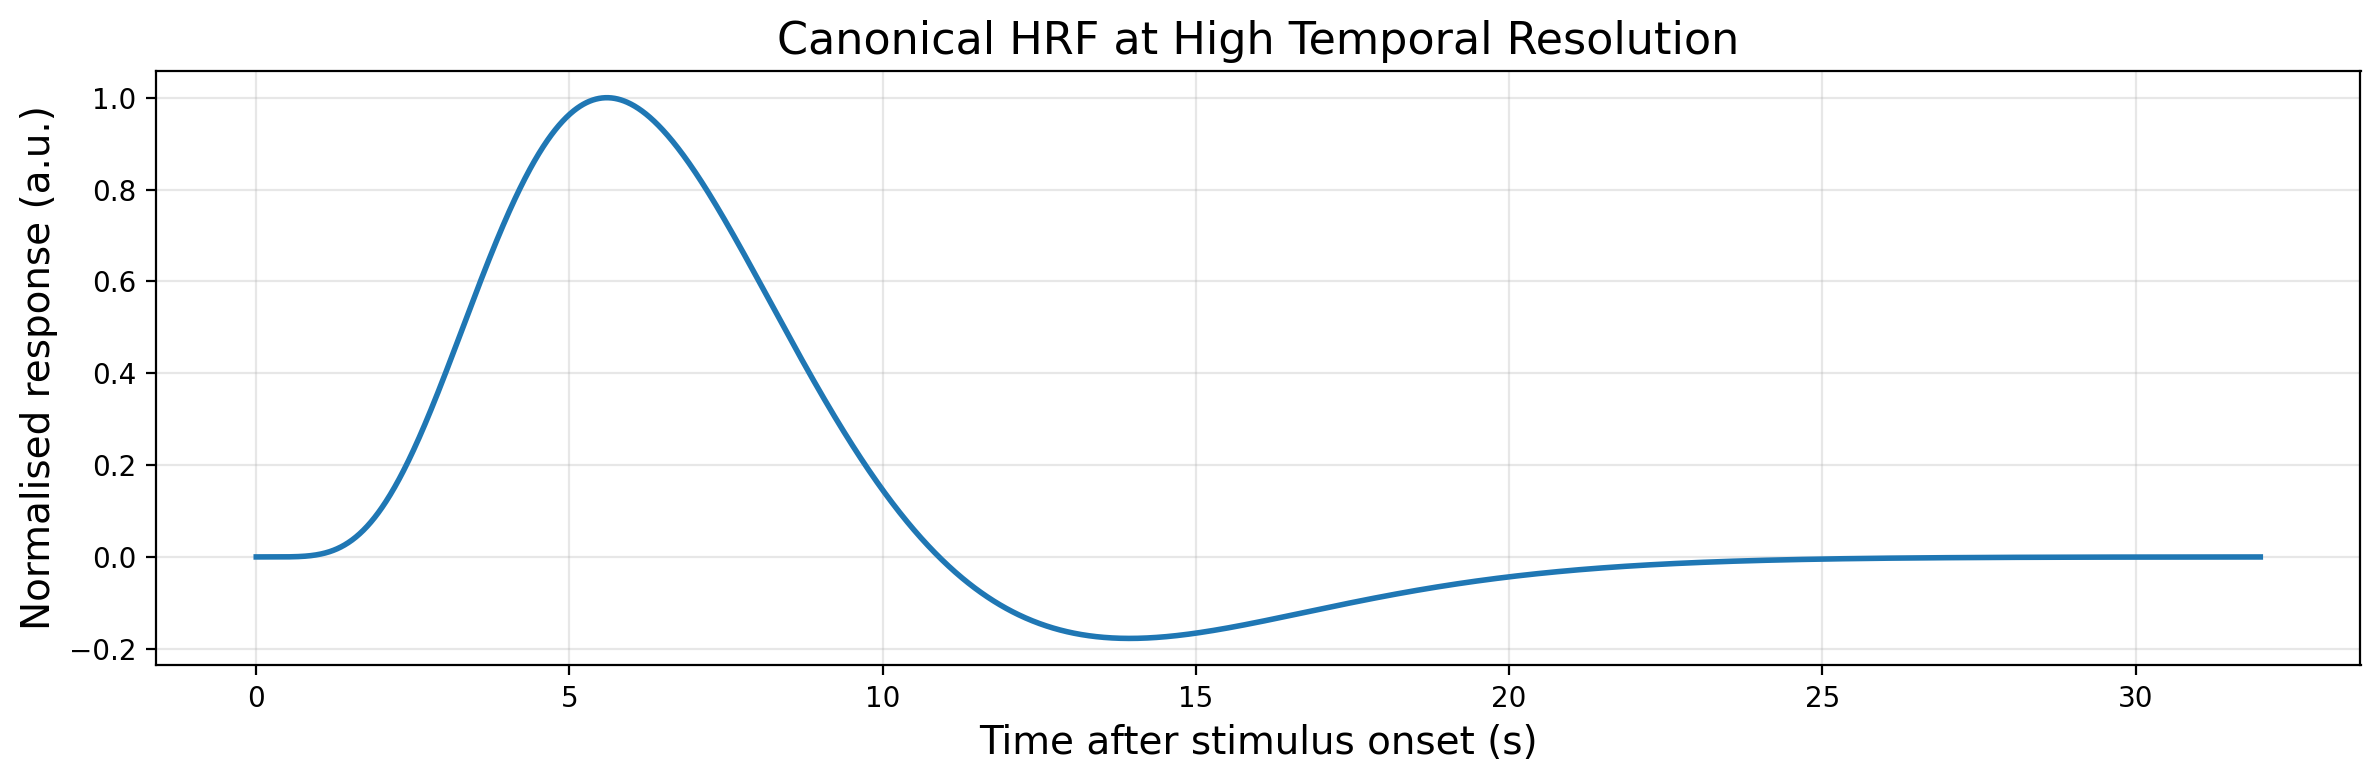

In [58]:
# Define oversampling factor for HRF (relative to TR)
osf = 100 * TR   # 100 samples per second when TR=1 → here TR=2, so 200 samples/s

# Generate canonical HRF at high temporal resolution
hrf_ms = glover_hrf(tr=TR, oversampling=osf, time_length=32)
hrf_ms /= hrf_ms.max()  # normalise so peak = 1

# Time axis in seconds (accounting for oversampling)
t = np.arange(hrf_ms.size) / (osf / TR)

# --- Plot HRF ---
plt.figure(figsize=(12, 4))
plt.plot(t, hrf_ms, color="tab:blue", lw=2)

plt.xlabel("Time after stimulus onset (s)", fontsize=14)
plt.ylabel("Normalised response (a.u.)", fontsize=14)
plt.title("Canonical HRF at High Temporal Resolution", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now that we have both the **high-resolution predictor** and the **high-resolution HRF**,  
let’s convolve them to create a predictor that captures both the **precise stimulus timing**  
and the **expected BOLD response**:

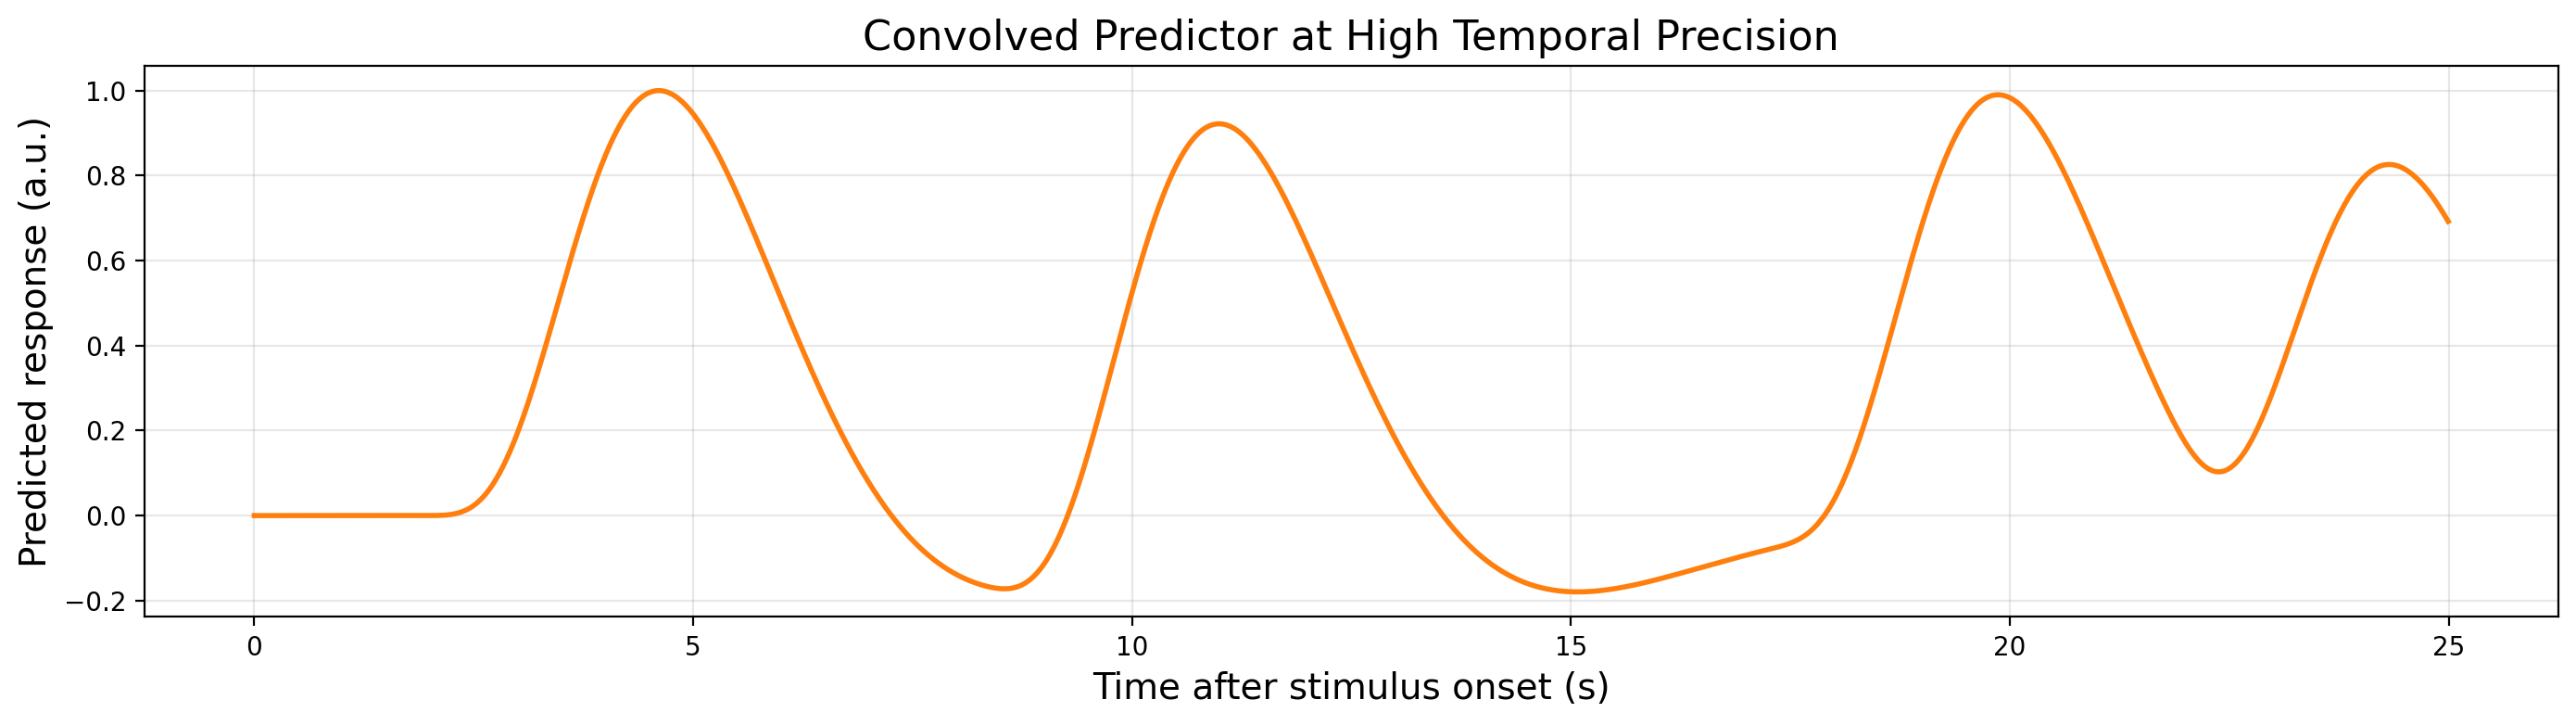

In [59]:
# Convolve oversampled predictor with high-resolution HRF
pred2_conv = np.convolve(pred2, hrf_ms)[:pred2.size]

# Time axis in seconds (since we oversampled at 0.01 s resolution)
t = np.arange(pred2_conv.size) / osf  

# --- Plot ---
plt.figure(figsize=(14, 4))
plt.plot(t, pred2_conv, color="tab:orange", lw=2)

plt.xlabel("Time after stimulus onset (s)", fontsize=14)
plt.ylabel("Predicted response (a.u.)", fontsize=14)
plt.title("Convolved Predictor at High Temporal Precision", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The final step is to **downsample the convolved predictor** so that it matches  
the temporal resolution of our voxel signal (i.e., the TR grid).

<div class='alert alert-warning'>
<b>ToDo</b> (1 point):  

The experiment was acquired with a **TR of 1.25 s** and produced **40 volumes**.  
Your task is to **downsample the convolved predictor** (<tt>pred2_conv</tt>) so that it aligns with the timescale of the voxel signal.  

In other words, resample the predictor to the timepoints:  
$t = 0,\; 1.25,\; 2.5,\; \dots,\; 48.75$ seconds.  

- Store your downsampled predictor in a variable named <tt>pred2_conv_ds</tt>.  
- 💡 *Hint*: carefully define the **original scale** (in hundredths of seconds) and the **desired scale** (steps of 1.25 s) before resampling.
</div>

In [74]:
# --- Implement your ToDo here ---

# Define original time axis (0.01 s resolution → oversampling factor of 100)
original_scale = np.arange(0, duration, 0.01)  # in seconds

# YOUR CODE HERE
import numpy as np

resampler = interp1d(original_scale, pred2_conv)
desired_scale = np.arange(0, (1.25*40), 1.25)
pred2_conv_ds = resampler(desired_scale) # downsampling the convolved predictor

pred2_conv_ds.size

40

In [75]:
# Feedback cell
if "pred2_conv_ds" not in locals():
    print('The variable "pred2_conv_ds" is not defined. Check that you created and named the variable correctly.')
elif not np.isclose(np.sum(pred2_conv_ds), 11.53, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')
else:
    print("Well done! Your code passed all automated tests.")

Hmm, something seems off. Please check your answer.


#### Fitting an HRF-informed model  

Finally, we’re ready to test whether the **HRF-informed predictor** can model
our original voxel signal (`voxel_signal`, from earlier in the tutorial) more
accurately.  

To do this, we will:  
1. Build a **design matrix** ($X$) by stacking an intercept with the
   HRF-convolved stimulus regressor.  
2. Fit a linear regression model to estimate the betas.  
3. Plot the **predicted signal vs. the true signal** to inspect model fit.  

For comparison, we’ll also include the fit from the **unconvolved predictor**
(our earlier model) to see the improvement.

R² (convolved):   0.306
R² (unconvolved): 0.004


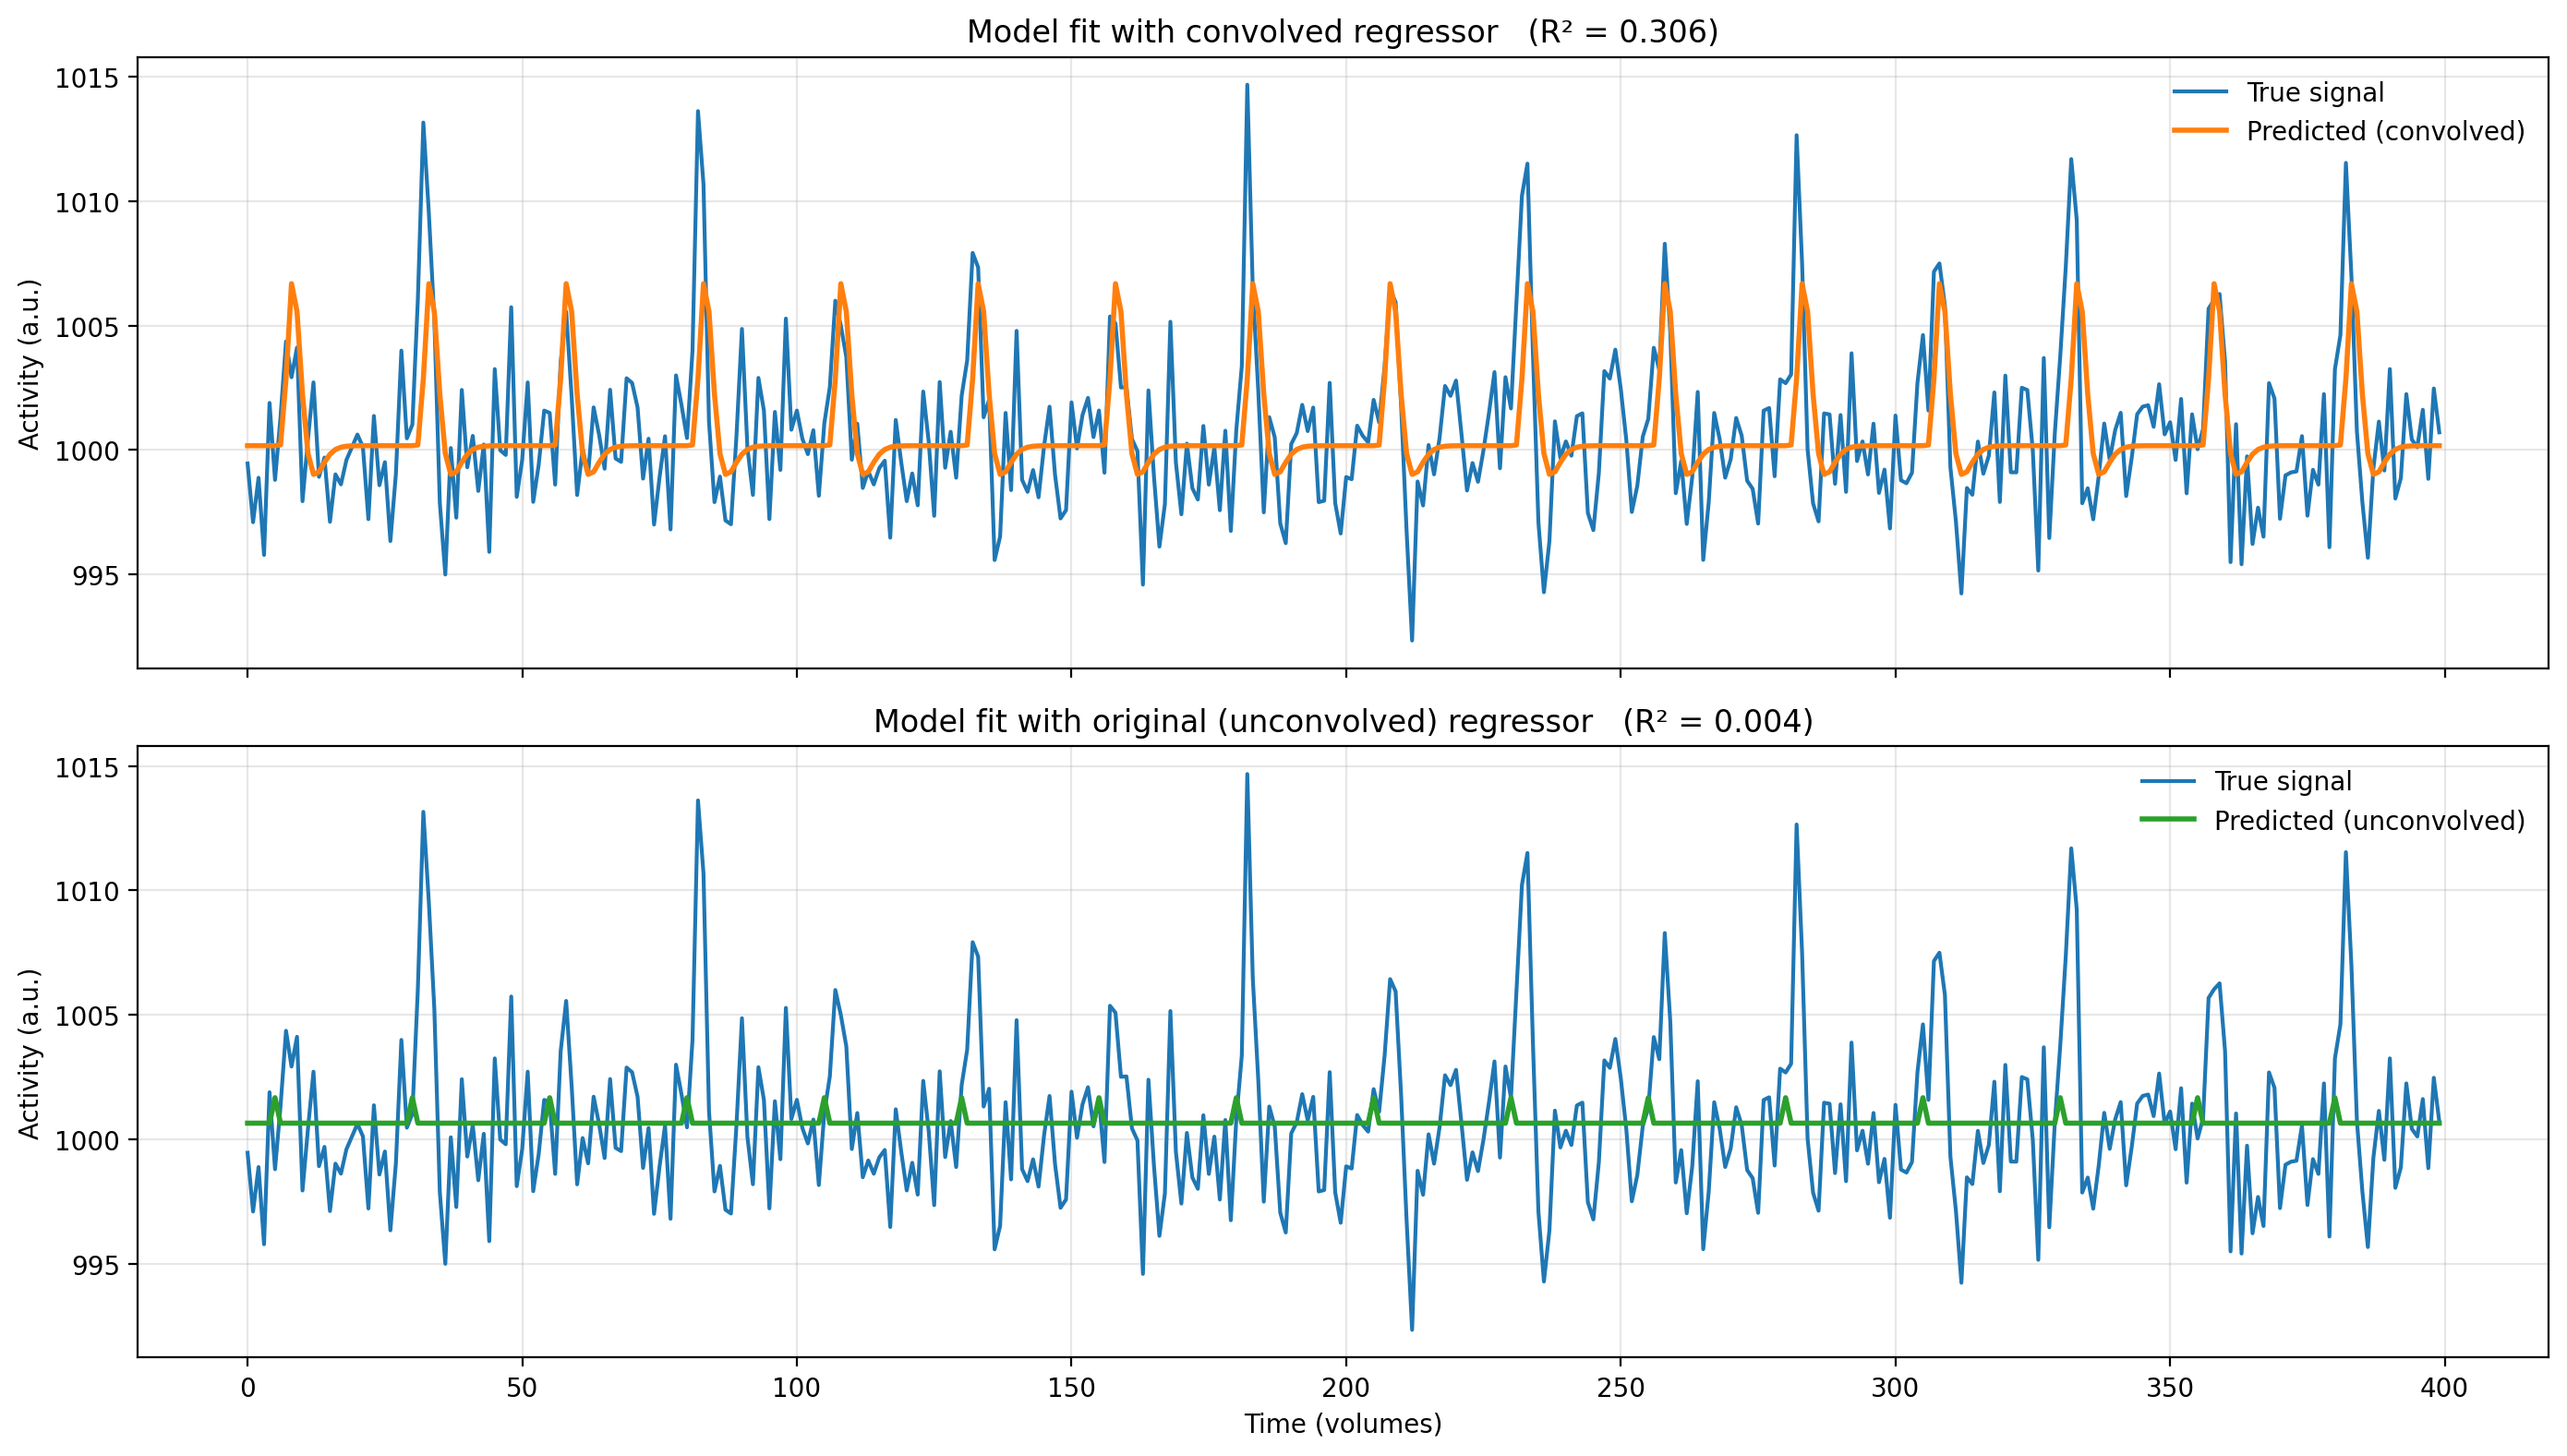

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return 1 - ss_res/ss_tot

# Ensure column vectors
conv_col = predictor_conv_ds.reshape(-1, 1) if predictor_conv_ds.ndim == 1 else predictor_conv_ds
simp_col = predictor_all_ds.reshape(-1, 1)  if predictor_all_ds.ndim == 1  else predictor_all_ds

# Design matrices
X_conv   = np.hstack((np.ones((conv_col.shape[0], 1)), conv_col))
X_simple = np.hstack((np.ones((simp_col.shape[0], 1)), simp_col))

# Fit with least squares (more stable than explicit inverse)
betas_conv,   *_ = np.linalg.lstsq(X_conv,   voxel_signal, rcond=None)
betas_simple, *_ = np.linalg.lstsq(X_simple, voxel_signal, rcond=None)

# Predictions
yhat_conv   = X_conv   @ betas_conv
yhat_simple = X_simple @ betas_simple

# Compute R²
r2_conv   = r2(voxel_signal, yhat_conv)
r2_simple = r2(voxel_signal, yhat_simple)
print(f"R² (convolved):   {r2_conv:.3f}")
print(f"R² (unconvolved): {r2_simple:.3f}")

# ---- choose an informative x-window around events ----
evt_idx = np.where(conv_col.ravel() > np.max(conv_col) * 0.05)[0]  # threshold to detect HRF bumps
if evt_idx.size:
    pad = 25  # volumes of padding on each side
    left  = max(evt_idx[0] - pad, 0)
    right = min(evt_idx[-1] + pad, len(voxel_signal))
else:
    left, right = 0, min(200, len(voxel_signal))  # fallback

# ---- plot ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(voxel_signal[left:right], label="True signal", color="tab:blue")
axes[0].plot(yhat_conv[left:right],   label="Predicted (convolved)", color="tab:orange", lw=2)
axes[0].set_ylabel("Activity (a.u.)")
axes[0].set_title(f"Model fit with convolved regressor   (R² = {r2_conv:.3f})")
axes[0].legend(frameon=False, loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(voxel_signal[left:right], label="True signal", color="tab:blue")
axes[1].plot(yhat_simple[left:right],   label="Predicted (unconvolved)", color="tab:green", lw=2)
axes[1].set_xlabel("Time (volumes)")
axes[1].set_ylabel("Activity (a.u.)")
axes[1].set_title(f"Model fit with original (unconvolved) regressor   (R² = {r2_simple:.3f})")
axes[1].legend(frameon=False, loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Excellent — that already looks like a much better fit!  

<div class='alert alert-warning'>
<b>ToDo</b> (2 points):  

Up to now, we lumped together the onsets of both conditions (circles and squares) into a **single predictor**.  
That model only tested whether the voxel responded to *any stimulus* (regardless of condition).  

In real analyses, however, you usually want to estimate **separate betas for each condition** — e.g. one beta for circles and another for squares — while fitting them **in the same model**.  
This allows you to test the contribution of each condition independently.  

Your task:  

1. **Convolve** each predictor (`predictor_circles`, `predictor_squares`) separately with the canonical HRF (`canonical_hrf`).  
   *Don’t forget to squeeze → trim → add axis back.*  
2. **Downsample** the convolved predictors to match the voxel signal.  
3. **Build the design matrix** $X$ by stacking an intercept and both predictors: 

    ```python
    np.hstack((intercept, pred_circles, pred_squares))
    ```
    
4. **Fit the GLM** to estimate the beta-parameters for circles and squares (in one model).
5. **Evaluate model fit**:
    - Mean Squared Error → store in <tt>mse_new</tt>
    - $R^2$ → store in <tt>r2_new</tt>

In [76]:
# Predictors at second-scale (0/1 impulses)
predictor_circles = np.zeros((800, 1))
predictor_circles[onsets_circles] = 1

predictor_squares = np.zeros((800, 1))
predictor_squares[onsets_squares] = 1

# --- Implement your solution below ---

# YOUR CODE HERE
 # convolve predictors
predictor_circles_conv = np.convolve(predictor_circles.squeeze(), canonical_hrf)
predictor_circles_conv = predictor_circles_conv[:predictor_circles.size]

predictor_squares_conv = np.convolve(predictor_squares.squeeze(), canonical_hrf)
predictor_squares_conv = predictor_squares_conv[:predictor_squares.size]

    # downsample convolved predictors
original_scale = np.arange(0,800,1)
desired_scale = np.arange(0, 800, 2)

resampler = interp1d(original_scale, predictor_circles_conv)
predictor_circles_conv_ds = resampler(desired_scale)

resampler = interp1d(original_scale, predictor_squares_conv)
predictor_squares_conv_ds = resampler(desired_scale)

    # add axis back
pred1 = predictor_circles_conv_ds[:, np.newaxis]
pred2 = predictor_squares_conv_ds[:, np.newaxis]

    # add intercept and creade design matrix
intercept = np.ones((predictor_circles_conv_ds.size, 1))
design_matrix = np.hstack((intercept, pred1, pred2))

    # calculate betas
betas_todo2 = inv(design_matrix.T @ design_matrix) @ design_matrix.T @ voxel_signal

    # get estimated voxel activity
est_voxel_activity = design_matrix @ betas_todo2

    # calculate MSE
mse_new = 1/voxel_signal.size * sum((voxel_signal - est_voxel_activity) ** 2)
mse_new = float(mse_new)

    # calculate R^2
numerator = np.sum((voxel_signal - est_voxel_activity) ** 2)
denominator = np.sum((voxel_signal - np.mean(voxel_signal)) ** 2)
r2_new = 1 - numerator / denominator
r2_new = float(r2_new)

print(mse_new, r2_new)

7.163330415654862 0.3090643604897899


In [77]:
# Feedback cell
errors = 0
for name, variable, value in zip(['r2_new', 'mse_new'], [r2_new, mse_new], [0.43, 5.88]): 
    if name not in locals():
        print(f'The variable "{name}" is not defined. Check that you created and named the variable correctly.')
        errors += 1
    elif not np.isclose(np.sum(variable), value, rtol=1e-2):
        print('Hmm, something seems off. Please check your answer.')
        errors += 1
        
if errors == 0:
    print('Well done! Your answer passed the automated checks.')
else: 
    print(f'The automated checks found {errors} potential errors in your code.')

Hmm, something seems off. Please check your answer.
Hmm, something seems off. Please check your answer.
The automated checks found 2 potential errors in your code.


<div class='alert alert-info'>
<b>ToThink</b> (1 point):  
If you completed the ToDo correctly, you should have noticed that the model fit improves (lower MSE / higher $R^2$) when circles and squares are modelled with <em>separate predictors</em> rather than lumped together into a single predictor.  

Why might modelling the two conditions separately result in a better fit? Consider what extra information the model gains by having two regressors instead of one. Write your explanation in the text cell below.
    
 👉 Explain your reasoning in the text cell below.
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

It appears that when circles and squares are modeled with separate predictors rather than combined into a single predictor, the model fit improves only slightly. Treating circles and squares as a single stimulus class \(as done before\) may account for most of the variation in the voxel signal. Differentiating between the two \(as done in this exercise\) may indicate that circles, compared to squares, induce a slightly different pattern of activation \(since they are different stimuli\), but this difference in activation is small. Most of the variance is explained by considering whether the participant saw any picture or no picture, while a small amount of additional variance can be described based on whether the participant saw a circle or a square.


### Temporal basis functions  

So far, we’ve used a **canonical HRF** to convolve our predictors.  
This approach assumes that the *same HRF shape* is appropriate for every voxel, every condition, and every subject in the study. That’s quite a strong assumption.  

In reality, the exact shape of the HRF often **varies across voxels, conditions, and participants**. Empirical studies have shown this repeatedly (see Tor Wager’s [video on basis sets](https://www.youtube.com/watch?v=YfeMIcDWwko&index=21&list=PLcvMDPDk-dSmTBejANv7kY2mFo1ni_gkA) for a clear explanation).  

This issue may also be present in our dataset.  

What can we do when the **canonical HRF** doesn’t line up perfectly with the data (e.g., peaks a bit too late)?  
One practical solution is to use **temporal basis functions** (a *basis set*).  
Instead of assuming a single fixed HRF shape for every event, we **represent the HRF as a combination of functions** and let the GLM estimate how much of each component is needed.

In practice, this means you **convolve each condition’s predictor with multiple HRFs**, producing **multiple columns per condition** in the design matrix. Each column captures a different *aspect* of the haemodynamic response, and together they can flexibly approximate the true HRF.

In this lab we’ll use a simple and widely used basis set: the **double-gamma HRF** plus its **temporal derivative** (sometimes the **dispersion derivative** is also added; we’ll omit it here for simplicity).

- **Original HRF** → captures the canonical response shape (amplitude).
- **Temporal derivative** → captures small **timing shifts** (earlier/later peaks).

If we have a single stimulus condition, the GLM becomes:

$$
y \;=\; \beta_{0} \;+\; \mathbf{X}_{\text{orig}}\,\beta_{1} \;+\; \mathbf{X}_{\text{temp}}\,\beta_{2} \;+\; \epsilon
$$

where:
- $X_{orig}$ is the predictor **convolved with the canonical HRF**,
- $X_{temp}$ is the **same predictor convolved with the temporal derivative** of the HRF.

Intuition:
- $beta_{1}$ ≈ response **amplitude** (how strong is the response?).
- $beta_{2}$ ≈ small **latency** adjustments (does the response arrive a bit early/late?).

We’ll use the implementations from **nilearn**:
- `glover_hrf` → canonical double-gamma HRF  
- `glover_time_derivative` → temporal derivative of the Glover HRF

Next, we’ll generate these two basis functions and build a design matrix with **two columns per condition** (plus an intercept), then fit the model and inspect how the derivative improves alignment.

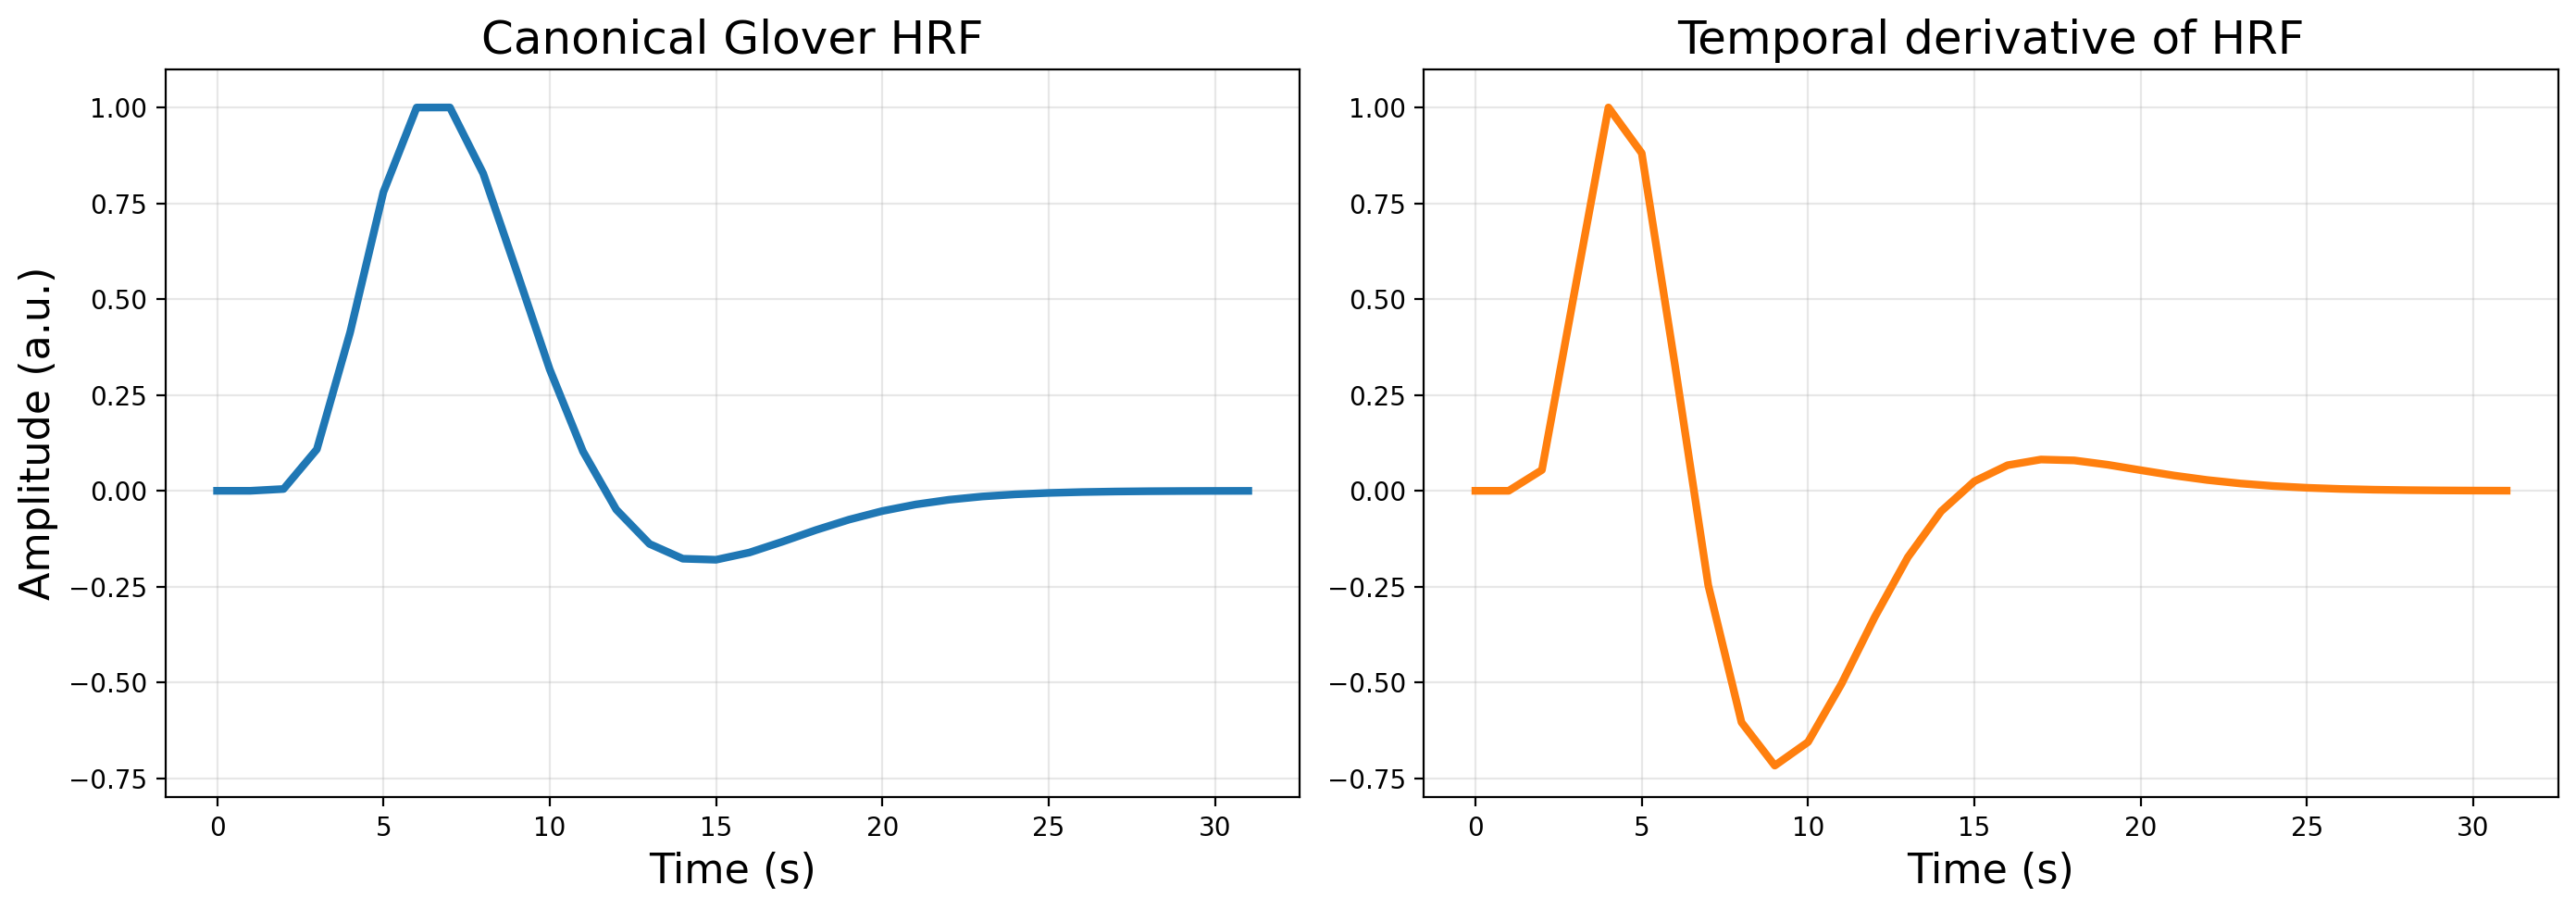

In [65]:
from nilearn.glm.first_level.hemodynamic_models import glover_time_derivative

# Generate the temporal derivative of the Glover HRF
tderiv_hrf = glover_time_derivative(tr=2, oversampling=2)
tderiv_hrf /= tderiv_hrf.max()  # normalise for comparison

# Plot canonical HRF and its temporal derivative
plt.figure(figsize=(14, 5))

# Canonical HRF
plt.subplot(1, 2, 1)
plt.plot(canonical_hrf, lw=3, color="tab:blue")
plt.ylim(-0.8, 1.1)
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Amplitude (a.u.)", fontsize=16)
plt.title("Canonical Glover HRF", fontsize=18)
plt.grid(alpha=0.3)

# Temporal derivative
plt.subplot(1, 2, 2)
plt.plot(tderiv_hrf, lw=3, color="tab:orange")
plt.ylim(-0.8, 1.1)
plt.xlabel("Time (s)", fontsize=16)
plt.title("Temporal derivative of HRF", fontsize=18)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Temporal Basis Functions: How the Corrections Work  

The nice thing about using a **basis set** is that the derivative regressors can *adapt* the canonical HRF to better fit the data.  

- The **temporal derivative** accounts for small shifts in the **lag/onset** of the BOLD response.  
- The **dispersion derivative** (if included) accounts for differences in the **width (dispersion)** of the response.  

---

👉 **How does this correction actually work?**  

- The **canonical HRF regressor** primarily captures the *amplitude* of the BOLD response.  
- The **temporal derivative regressor** captures changes in the *timing* of the response.  
- (Optionally) the **dispersion derivative regressor** captures differences in the *width* of the response.  

When these regressors are included together in the GLM, the model assigns each one a **beta weight**:  
- A high weight on the canonical HRF means the voxel shows the expected amplitude.  
- A non-zero weight on the temporal derivative effectively **shifts the HRF in time** to better match the voxel’s data.  
- A dispersion derivative (if used) would allow the model to adjust the HRF’s **width**.  

---

Now, let’s visualize this idea. Suppose we have a voxel that does **not** conform to the canonical HRF’s lag assumption — e.g., the canonical HRF peaks too early. We’ll show that the canonical HRF alone explains this voxel suboptimally.

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import toeplitz
from nilearn.glm.first_level.hemodynamic_models import glover_hrf, glover_time_derivative

def simulate_signal(
    onsets,
    conditions,
    TR=2.0,
    duration=None,
    intercept=0.0,
    beta_canonical=None,        # β for canonical HRF per condition (length = #conditions)
    beta_tderiv=None,           # β for temporal-derivative HRF per condition (same length)
    phi=None,                   # AR(1) coefficient for temporal noise; None → white noise
    noise_sd=1.0,               # noise standard deviation
    oversampling=100,           # samples per second for the fine (seconds) grid
    rng=None,                   # np.random.Generator for reproducibility
    plot=True
):
    """
    Simulate a (somewhat) realistic voxel time series and an associated design matrix
    using a temporal-basis HRF model (canonical + temporal derivative).

    Parameters
    ----------
    onsets : array-like of float
        Event onsets in seconds (can be fractional; same length as `conditions`).
    conditions : array-like (hashable)
        Condition labels per event (e.g., 'circle', 'square'). Used to define columns.
    TR : float, default=2.0
        Repetition time in seconds (sampling of the voxel signal).
    duration : float or None, default=None
        Total duration of the experiment in seconds. If None, uses max(onsets) + 30 s.
    intercept : float, default=0.0
        Baseline level of the signal (β₀).
    beta_canonical : array-like or None
        Per-condition amplitudes for the canonical HRF (length = #unique conditions).
        If None, defaults to zeros (no canonical effect).
    beta_tderiv : array-like or None
        Per-condition amplitudes for the temporal derivative HRF (length = #unique conditions).
        If None, defaults to zeros (no timing adjustment).
    phi : float in [0, 1) or None
        AR(1) coefficient for coloured noise. If None, white noise is used.
    noise_sd : float, default=1.0
        Standard deviation of the noise added to the downsampled signal.
    oversampling : int, default=100
        Number of samples per second for constructing predictors and HRFs.
    rng : np.random.Generator or None
        Random generator for reproducibility (e.g., np.random.default_rng(42)).
        If None, a fresh generator is created.
    plot : bool, default=True
        If True, plot the simulated signal and fitted prediction.

    Returns
    -------
    y : (N_vol,) ndarray
        Simulated voxel signal at TR resolution.
    X_TR : (N_vol, 1 + 2P) ndarray
        Design matrix at TR resolution: [intercept | P canonical | P temporal-derivative].
    betas_true : (1 + 2P,) ndarray
        True parameters used to generate the signal: [β₀, β_canonical..., β_tderiv...].
    betas_hat : (1 + 2P,) ndarray
        Least-squares estimates from regressing y on X_TR.
    info : dict
        Misc info (e.g., condition order, fine/TR time axes, HRFs).
    """
    # --- Setup & checks ---
    onsets = np.asarray(onsets, dtype=float)
    conditions = np.asarray(conditions)
    if rng is None:
        rng = np.random.default_rng()

    conds = sorted(list(np.unique(conditions)))
    P = len(conds)

    if duration is None:
        duration = float(np.max(onsets) + 30.0)

    if beta_canonical is None:
        beta_canonical = np.zeros(P, dtype=float)
    else:
        beta_canonical = np.asarray(beta_canonical, dtype=float)

    if beta_tderiv is None:
        beta_tderiv = np.zeros(P, dtype=float)
    else:
        beta_tderiv = np.asarray(beta_tderiv, dtype=float)

    assert beta_canonical.shape == (P,), "beta_canonical must have length equal to #conditions"
    assert beta_tderiv.shape   == (P,), "beta_tderiv must have length equal to #conditions"

    # Map condition label → column index
    cond_to_col = {c: i for i, c in enumerate(conds)}

    # --- High-resolution time axis (seconds grid) ---
    dt = 1.0 / oversampling                      # fine time step in seconds
    t_fine = np.arange(0.0, duration, dt)        # [0, dt, 2dt, ... < duration]
    N_fine = t_fine.size

    # --- Build event matrix at fine resolution: X_events (N_fine x P) ---
    X_events = np.zeros((N_fine, P), dtype=float)
    # place impulses at nearest fine-grid index
    onset_idx = np.clip(np.round(onsets * oversampling).astype(int), 0, N_fine - 1)
    for idx, cond in zip(onset_idx, conditions):
        X_events[idx, cond_to_col[cond]] += 1.0

    # --- HRFs at fine resolution (use TR=1 here, oversampling=oversampling) ---
    # Normalise to unit peak so betas are interpretable as amplitudes in a.u.
    hrf_canon = glover_hrf(tr=1.0, oversampling=oversampling, time_length=32.0)
    hrf_tempd = glover_time_derivative(tr=1.0, oversampling=oversampling)
    hrf_canon = hrf_canon / np.max(hrf_canon)
    hrf_tempd = hrf_tempd / np.max(np.abs(hrf_tempd))  # derivative can be biphasic; normalise by max |.|.

    # --- Convolve to get basis columns at fine resolution: [P canonical | P temp-deriv] ---
    X_fine = np.zeros((N_fine, 2 * P), dtype=float)
    for j in range(P):
        # Canonical
        X_fine[:, j] = np.convolve(X_events[:, j], hrf_canon, mode="full")[:N_fine]
        # Temporal derivative
        X_fine[:, P + j] = np.convolve(X_events[:, j], hrf_tempd, mode="full")[:N_fine]

    # Add intercept at fine resolution (for completeness; not strictly needed before downsampling)
    intercept_fine = np.ones((N_fine, 1), dtype=float)
    X_fine_full = np.hstack((intercept_fine, X_fine))  # (N_fine, 1 + 2P)

    # --- True betas vector ---
    betas_true = np.concatenate(([intercept], beta_canonical, beta_tderiv))  # (1 + 2P,)

    # --- Generate noiseless fine-resolution signal and downsample to TR grid ---
    y_fine = X_fine_full @ betas_true

    t_TR = np.arange(0.0, duration, TR)         # TR grid in seconds
    resampler_y = interp1d(t_fine, y_fine, kind="linear", bounds_error=False, fill_value="extrapolate")
    y_TR = resampler_y(t_TR)                     # (N_vol,)

    # Downsample the design to TR grid as well (column-wise)
    X_TR = np.zeros((t_TR.size, 1 + 2 * P), dtype=float)
    for col in range(1 + 2 * P):
        res_col = interp1d(t_fine, X_fine_full[:, col], kind="linear",
                           bounds_error=False, fill_value="extrapolate")
        X_TR[:, col] = res_col(t_TR)

    # --- Add AR(1) or white noise at TR resolution ---
    N_vol = t_TR.size
    if phi is None:
        noise = rng.normal(0.0, noise_sd, size=N_vol)
    else:
        # AR(1): Cov[i,j] = noise_sd^2 * phi^{|i-j|}
        k = np.arange(N_vol)
        Sigma = (noise_sd ** 2) * (phi ** np.abs(k[:, None] - k[None, :]))
        noise = rng.multivariate_normal(mean=np.zeros(N_vol), cov=Sigma)

    y = y_TR + noise

    # --- Fit GLM at TR resolution (numerically stable) ---
    betas_hat, *_ = np.linalg.lstsq(X_TR, y, rcond=None)
    y_hat = X_TR @ betas_hat

    # --- Plot (optional) ---
    if plot:
        plt.figure(figsize=(12, 4))
        plt.plot(y, label="Simulated signal", color="tab:blue", alpha=0.85)
        plt.plot(y_hat, label="Fitted prediction", color="tab:orange", lw=2)
        plt.xlabel("Time (volumes)")
        plt.ylabel("Activity (a.u.)")
        plt.title("Simulated voxel signal and GLM fit (canonical + temporal derivative)")
        plt.grid(alpha=0.3)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    info = {
        "conditions": conds,
        "cond_to_col": cond_to_col,
        "t_fine": t_fine,
        "t_TR": t_TR,
        "hrf_canonical": hrf_canon,
        "hrf_temporal_derivative": hrf_tempd,
        "X_fine": X_fine_full,     # with intercept
        "X_TR": X_TR,             # with intercept
        "y_fine": y_fine,
        "y_TR_noiseless": y_TR,
    }

    return y, X_TR, betas_true, betas_hat, info

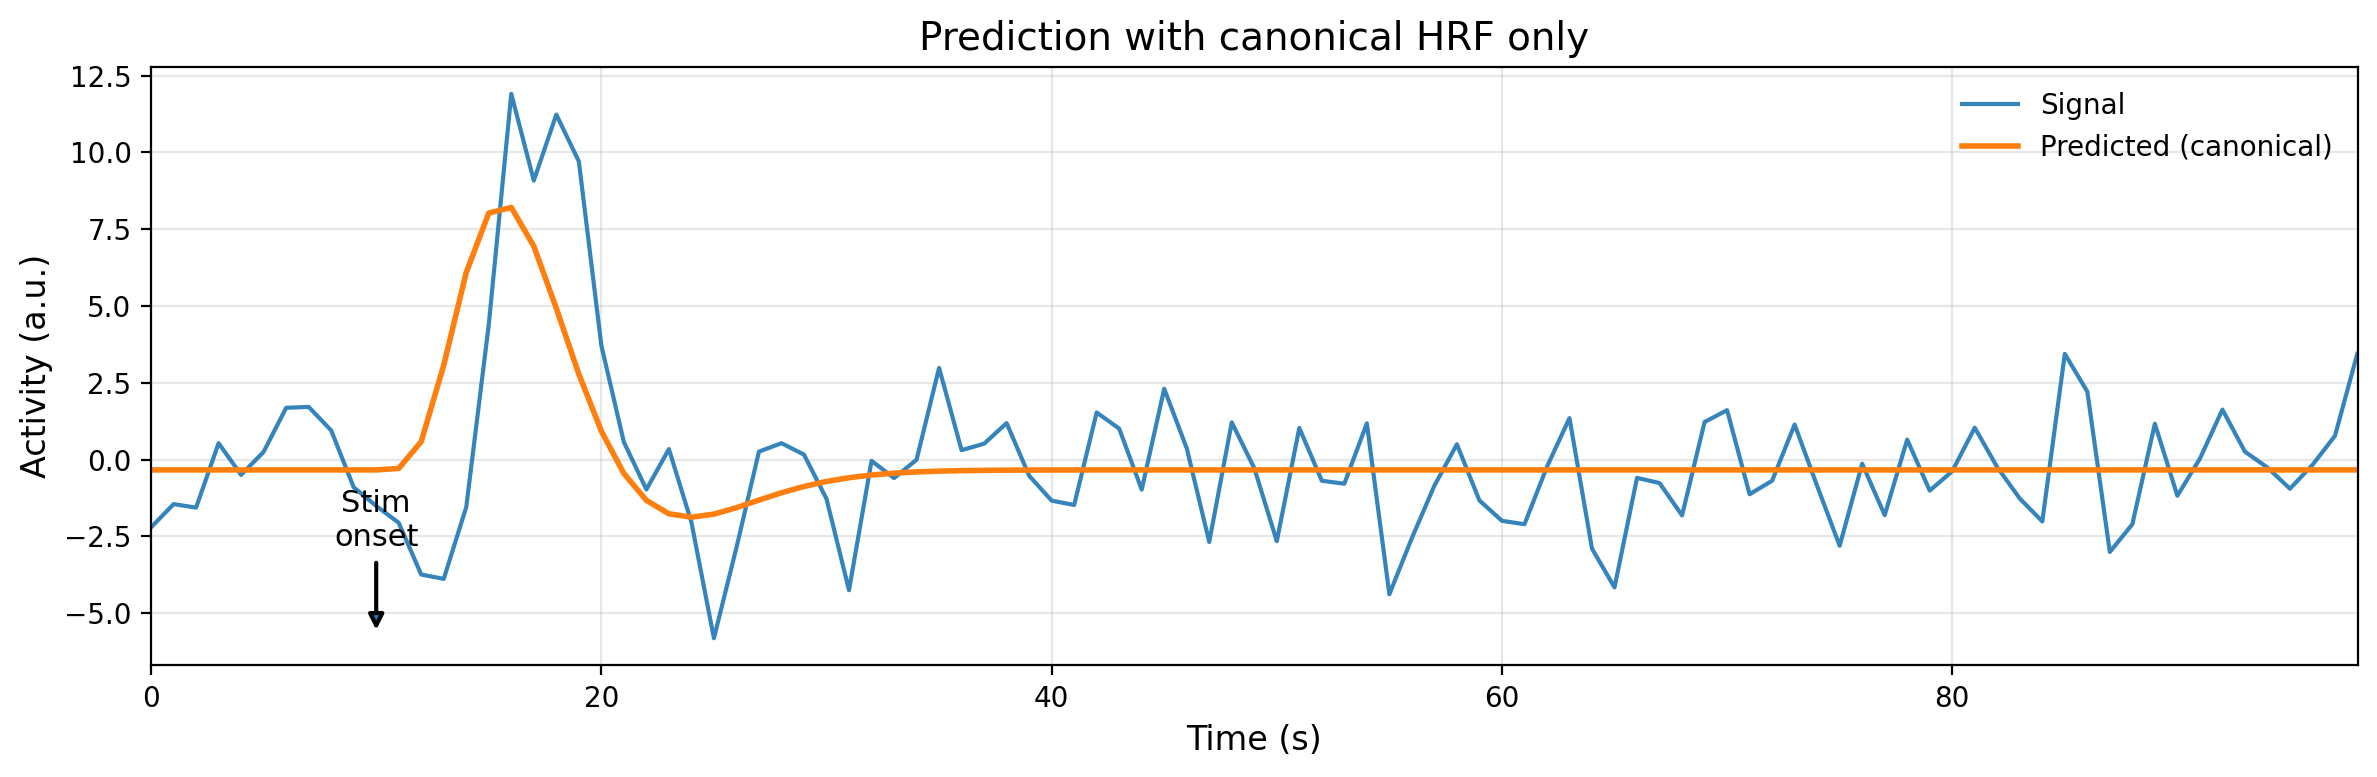

In [67]:
# --- Temporal basis set (canonical + temporal derivative), then fit canonical-only model ---

# Simulate a single-condition dataset with a timing mismatch (non-zero temporal-derivative beta)
y_tbs, X_tbs, betas_true_tbs, betas_hat_tbs, info_tbs = simulate_signal(
    onsets=[10],                 # stimulus at 10 s
    conditions=['stim'],         # single condition
    TR=1.0,                      # seconds
    duration=100.0,              # seconds
    intercept=0.0,               # baseline
    beta_canonical=[10.0],       # canonical HRF amplitude
    beta_tderiv=[-8.0],          # temporal derivative → induces lag correction
    phi=None,                    # white noise
    noise_sd=2.0,
    oversampling=100,
    rng=np.random.default_rng(10),
    plot=False
)

# Design structure returned by simulate_signal:
# X_tbs columns = [intercept | canonical(stim) | temporal-derivative(stim)]
# Canonical-only model: drop the temporal-derivative column
X_canon_only = X_tbs[:, :2]  # keep intercept + canonical

# Fit GLM (canonical-only) with least squares
beta_canon_only, *_ = np.linalg.lstsq(X_canon_only, y_tbs, rcond=None)
yhat_canon_only = X_canon_only @ beta_canon_only

# --- Plot observed signal and canonical-only prediction ---
t = np.arange(y_tbs.size)  # seconds since TR = 1

plt.figure(figsize=(12, 4))
plt.plot(t, y_tbs,            label="Signal",               color="tab:blue",  alpha=0.9)
plt.plot(t, yhat_canon_only,  label="Predicted (canonical)", color="tab:orange", lw=2)

# Annotate stimulus onset
plt.annotate(
    "Stim\nonset", xy=(10, plt.ylim()[0] + 0.05*(plt.ylim()[1]-plt.ylim()[0])),
    xytext=(10, plt.ylim()[0] + 0.20*(plt.ylim()[1]-plt.ylim()[0])),
    ha="center", fontsize=11,
    arrowprops=dict(arrowstyle="-|>", lw=1.5)
)

plt.xlim(0, 98)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Activity (a.u.)", fontsize=12)
plt.title("Prediction with canonical HRF only", fontsize=14)
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As you can see, the predicted signal (<span style="color:orange;">orange line</span>) peaks **too early** compared to the actual BOLD response (<span style="color:blue;">blue line</span>).  

Next, let’s include the **temporal derivative** in the model to see if it can adjust the timing and improve the fit:

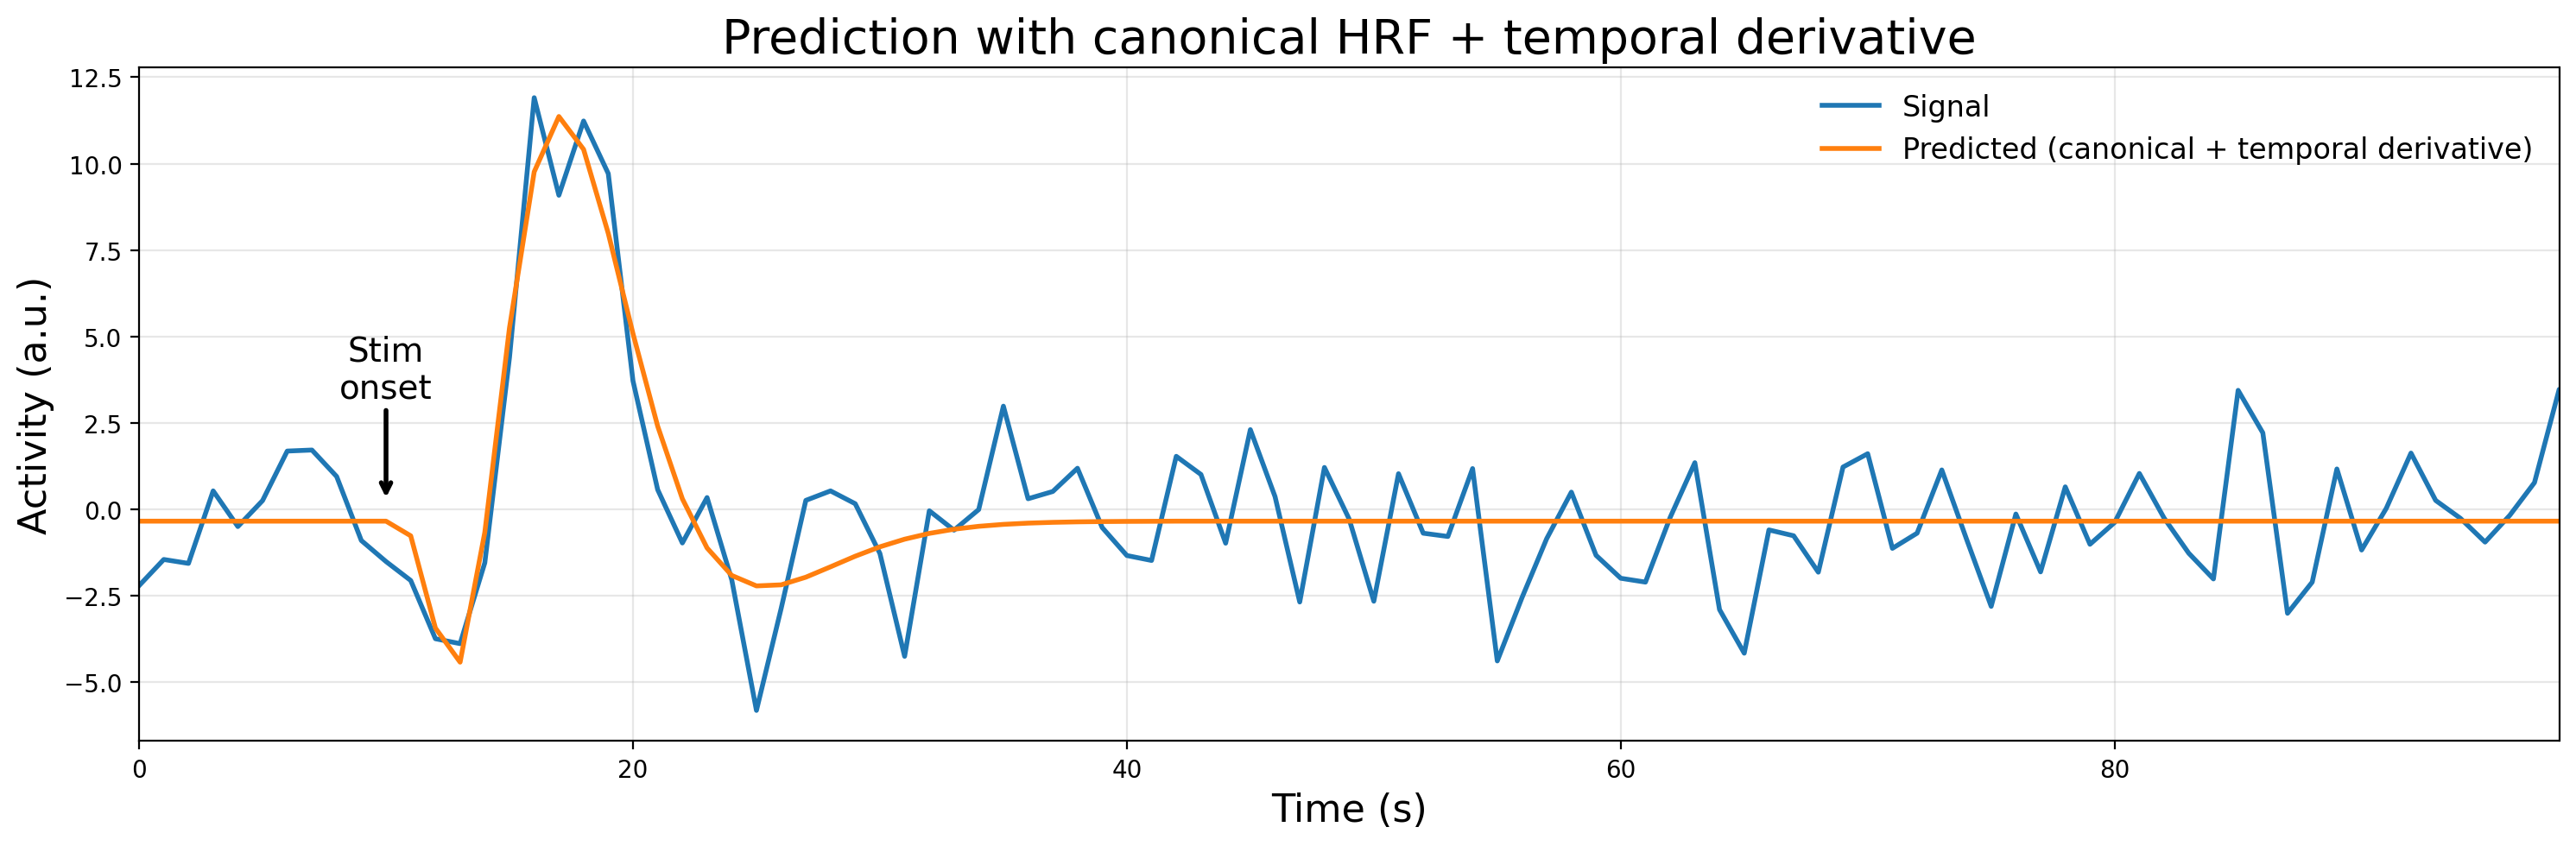

In [68]:
# --- Regression with canonical HRF + temporal derivative ---
betas_td = np.linalg.lstsq(X_tbs, y_tbs, rcond=None)[0]
y_hat_td = X_tbs @ betas_td

# --- Plot results ---
plt.figure(figsize=(15, 5))

plt.plot(y_tbs, label="Signal", color="tab:blue", lw=2)
plt.plot(y_hat_td, label="Predicted (canonical + temporal derivative)", color="tab:orange", lw=2)

# Stimulus onset annotation
plt.annotate(
    "", xy=(10, 3), xytext=(10, 0.2),
    arrowprops=dict(arrowstyle="<-", lw=2)
)
plt.text(10, 3.2, "Stim\nonset", ha="center", fontsize=14)

# Axis labels and styling
plt.xlim(0, 98)
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Activity (a.u.)", fontsize=16)
plt.title("Prediction with canonical HRF + temporal derivative", fontsize=20)

plt.legend(fontsize=12, frameon=False, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As you can see, the prediction improves noticeably when we include the temporal derivative.  
But what do the **beta-parameters** mean here?  

In practice, researchers rarely interpret the temporal (or dispersion) derivative betas directly—unless they are specifically interested in timing (lag) or width (dispersion) of the HRF. Most of the time, the main focus is on the **canonical HRF beta**, which reflects the voxel’s activation (or deactivation) amplitude in response to a stimulus.  

In other words, the derivative regressors mainly act as **correction terms**, helping the model account for small shifts in timing or shape that the canonical HRF alone might miss.  

So, should you *always* use a basis set? Opinions differ. In many simple group-level analyses (e.g. averaging across participants), temporal derivatives tend to offer little improvement over the canonical HRF—but they usually don’t hurt either, as long as you have enough degrees of freedom.  

<div class='alert alert-warning'>
<b>ToDo</b> (optional; 0 points):  

In gamma-based basis sets, the different components are often **correlated** with each other—especially the canonical HRF and its dispersion derivative.  
This means that the predictors can "compete" for explained variance, which affects both their **parameter estimates** and the associated **statistics**.  

Because researchers are usually most interested in the **amplitude component** (the canonical HRF), it is common to *orthogonalize* the derivative predictors with respect to the canonical HRF.  
Orthogonalization is the process of **removing shared variance** between predictors (i.e., making them decorrelated). 
    
For more details, see [this excellent article](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0126255).  

Your task:  
- Using the variable <tt>Xc</tt> (which contains two predictors: column 1 = canonical HRF, column 2 = temporal derivative),  
- Orthogonalize the **temporal derivative predictor** (second column) with respect to the canonical HRF (first column).  
- Replace the second column of <tt>Xc</tt> with the orthogonalized version (so that it no longer shares variance with the canonical HRF).  

💡 *Hint*: Orthogonalization can be done by regressing the temporal derivative predictor onto the canonical HRF and keeping only the residuals.  
</div>

In [78]:
# --- Implement your ToDo here ---
# Xc has two columns: [0] = canonical HRF, [1] = temporal derivative
Xc = X_tbs[:, 1:].copy()

# YOUR CODE HERE
# raise NotImplementedError()

👉 **Solution: Orthogonalising the temporal derivative predictor**

<details>
<summary>✅ Click to reveal solution</summary>

```python
# --- Implement your ToDo here ---
# Xc has two columns: [0] = canonical HRF, [1] = temporal derivative
Xc = X_tbs[:, 1:].copy()

### BEGIN SOLUTION
# Orthogonalise the temporal-derivative column w.r.t. the canonical HRF column
# Using a simple Gram–Schmidt step: v2 <- v2 - proj_{v1}(v2)
v1 = Xc[:, 0]                  # canonical HRF predictor
v2 = Xc[:, 1]                  # temporal derivative predictor

alpha = (v1 @ v2) / (v1 @ v1)  # projection coefficient
Xc[:, 1] = v2 - alpha * v1     # replace with residual (now orthogonal to v1)
### END SOLUTION
 ```
</details>

<div class='alert alert-warning'>
<b>ToDo</b> (5 points):

Reanalyse the voxel signal using the separate conditions (circles vs. squares), but this time include both the **canonical HRF** (<tt>canonical_hrf</tt>) and its **temporal derivative** (<tt>tderiv_hrf</tt>).  

You will need to build a design matrix with four predictors (2 conditions × 2 basis functions), plus an intercept. Then, fit the GLM to the voxel signal (<tt>voxel_signal</tt>) and evaluate the model.  

Follow these steps carefully (each step can be tested separately for partial credit):

1. **Build the design matrix (2 points):**  
   - Convolve the circle predictor (<tt>predictor_circles</tt>) and the square predictor (<tt>predictor_squares</tt>) with both HRFs (<tt>canonical_hrf</tt>, <tt>tderiv_hrf</tt>).  
   - This should give you 4 predictors in total.  
   - Stack them together and add an intercept (make sure the intercept is the **first column**).  
   - Downsample the design matrix to the TR grid of <tt>voxel_signal</tt>.  
   - Store the final downsampled design matrix in a variable named <tt>X_gbf</tt>.  
   - ⚠️ The column order must be:  
     1. Intercept  
     2. Circles (canonical)  
     3. Circles (temporal derivative)  
     4. Squares (canonical)  
     5. Squares (temporal derivative)  
     If the order is incorrect, automatic grading will fail.

2. **Fit the GLM (1 point):**  
   - Run linear regression with <tt>voxel_signal</tt> as the dependent variable.  
   - Store the estimated parameters in <tt>betas_gbf</tt>.  

3. **Calculate $R^2$ (1 point):**  
   - Store the value in <tt>r2_gbf</tt>.  

4. **Calculate the MSE (1 point):**  
   - Store the value in <tt>mse_gbf</tt>.  

**Tips:**  
- Reuse the HRFs you defined earlier (<tt>canonical_hrf</tt> and <tt>tderiv_hrf</tt>).  
- Your final design matrix should have **5 columns** (intercept + 4 predictors).  
- Don’t forget to downsample after convolution to match the timescale of <tt>voxel_signal</tt>.  
</div>

In [79]:
# Step 1: convolve the predictors (trim and downsample), then build X_gbf

# Binary predictors at second resolution (already provided above)
predictor_circles = np.zeros(800); predictor_circles[onsets_circles] = 1
predictor_squares = np.zeros(800); predictor_squares[onsets_squares] = 1

# YOUR CODE HERE
# convolve predictors
pred_c_can = np.convolve(predictor_circles.squeeze(), canonical_hrf)
pred_c_can = pred_c_can[:predictor_circles.size]

pred_c_tempd = np.convolve(predictor_circles.squeeze(), tderiv_hrf)
pred_c_tempd = pred_c_tempd[:predictor_circles.size]

pred_s_can = np.convolve(predictor_squares.squeeze(), canonical_hrf)
pred_s_can = pred_s_can[:predictor_squares.size]

pred_s_tempd = np.convolve(predictor_squares.squeeze(), tderiv_hrf)
pred_s_tempd = pred_s_tempd[:predictor_squares.size]

print(pred_c_can.shape)

    # downsample convolved predictors
original_scale = np.arange(0,800,1)
desired_scale = np.arange(0, 800, 2)

resampler = interp1d(original_scale, pred_c_can)
pred_c_can = resampler(desired_scale)

resampler = interp1d(original_scale, pred_c_tempd)
pred_c_tempd = resampler(desired_scale)

resampler = interp1d(original_scale, pred_s_can)
pred_s_can = resampler(desired_scale)

resampler = interp1d(original_scale, pred_s_tempd)
pred_s_tempd = resampler(desired_scale)

print(pred_c_can.shape)

    # add axis back
pred_c_can = pred_c_can[:, np.newaxis]
pred_c_tempd = pred_c_tempd[:, np.newaxis]
pred_s_can = pred_s_can[:, np.newaxis]
pred_s_tempd = pred_s_tempd[:, np.newaxis]

print(pred_c_can.shape)

    # add intercept and create design matrix
intercept = np.ones((pred_c_can.size, 1))
X_gbf = np.hstack((intercept, pred_c_can, pred_c_tempd, pred_s_can, pred_s_tempd))


print(X_gbf.shape, voxel_signal.shape)

(800,)
(400,)
(400, 1)
(400, 5) (400,)


In [80]:
# Feedback cell 1
if "X_gbf" not in locals():
    print('The variable "X_gbf" is not defined. Check that you created and named the variable correctly.')
elif not X_gbf.shape == (400, 5):
    print('"X_gbf" does not have the expected shape.')
elif not np.isclose(np.sum(X_gbf), 427.41, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')        
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


In [82]:
# Step 2: fit GLM
# YOUR CODE HERE
  # calculate betas
betas_gbf = inv(X_gbf.T @ X_gbf) @ X_gbf.T @ voxel_signal

    # get estimated voxel activity
est_voxel_activity_gbf = X_gbf @ betas_gbf

print(betas_gbf)

[1000.18213988    6.95333228    7.89433848    5.86921026    2.00549882]


In [83]:
# Feedback cell 2
if "betas_gbf" not in locals():
    print('The variable "betas_gbf" is not defined. Check that you created and named the variable correctly.')
elif not betas_gbf.shape == (5,):
    print('"betas_gbf" does not have the expected shape.')
elif not np.isclose(np.sum(betas_gbf), 1023.28, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')        
else:
    print('Well done! Your answer passed the automated checks.')

Well done! Your answer passed the automated checks.


In [84]:
# Step 3: R^2
# YOUR CODE HERE
numerator = np.sum((voxel_signal - est_voxel_activity_gbf) ** 2)
denominator = np.sum((voxel_signal - np.mean(voxel_signal)) ** 2)
r2_gbf = 1 - numerator / denominator
r2_gbf = float(r2_gbf)

print(r2_gbf)
# raise NotImplementedError()

0.5689049191822393


In [85]:
# Feedback cell 3
if "r2_gbf" not in locals():
    print('The variable "r2_gbf" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(r2_gbf):
    print('"r2_gbf" should be a single number (float).')
elif not np.isclose(r2_gbf, 0.578, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')        
else:
    print('Well done! Your answer passed the automated checks.')

Hmm, something seems off. Please check your answer.


In [86]:
# Step 4: MSE
# YOUR CODE HERE
mse_gbf = 1/voxel_signal.size * sum((voxel_signal - est_voxel_activity_gbf) ** 2)
mse_gbf = float(mse_gbf)

print(mse_gbf)

4.469412674457105


In [87]:
# Feedback cell 4
if "mse_gbf" not in locals():
    print('The variable "mse_gbf" is not defined. Check that you created and named the variable correctly.')
elif not np.isscalar(mse_gbf):
    print('"mse_gbf" should be a single number (float).')
elif not np.isclose(mse_gbf, 4.38, rtol=1e-2):
    print('Hmm, something seems off. Please check your answer.')        
else:
    print('Well done! Your answer passed the automated checks.')

Hmm, something seems off. Please check your answer.


From what we’ve seen so far, the way linear regression is applied to model a voxel’s signal is really not that different from how it’s used on “regular” data — the main new piece is the **HRF convolution**. At this point, you already understand about **95%** of how univariate fMRI analysis works!  

In [88]:
# Please run this cell to clear up space on the server. If you need the data again, just run the download cell at the beginning of the notebook.

for file in ['data_todo_rsquared.npz', 'example_voxel_signal.npy', 'ToDo.npz']:
    if os.path.isfile(file):
        os.remove(file)
        print(f'Removed file {file}')
    else:
        print(f'File {file} not found')

Removed file data_todo_rsquared.npz
Removed file example_voxel_signal.npy
Removed file ToDo.npz


## 🎉 Well done!  

You’ve completed this week’s notebook.  

In this session, you learned how to apply the **General Linear Model (GLM)** to fMRI data, focusing on the **estimation** step. 

We covered how to:  
- build a design matrix from experimental predictors,  
- estimate β parameters using **Ordinary Least Squares (OLS)**,  
- calculate **predicted signals**, **residuals**, and metrics like **MSE** and **R²**, and  
- interpret β parameters (including the importance of the intercept).  

By now, you’ve seen how univariate fMRI analysis boils down to linear regression applied voxel by voxel, with the additional step of modelling the haemodynamic response function (HRF).  

---

### Up next: Week 3  

Next week we continue with the **GLM, Part 2: Inference**. 

Whereas this week was about estimating model parameters, in Week 3 we focus on **statistical inference** — deciding whether the estimated effects are significant.  

By the end of Week 3, you will:  
- understand the formula for the *t*-value in the GLM and how it relates to your data,  
- know how to compute *t*- and *p*-values for model parameters, and  
- see how inference connects parameter estimates to experimental hypotheses.  

You’ll also start a second notebook on the **Design of Experiments**, exploring how stimulus timing and ordering influence statistical power.  